In [234]:
import scanpy as sc
import pandas as pd
import numpy as np

# Load the two h5ad files
infected_path = "/Users/yashkulkarni/cellxgene_data/cell2location_infected_030525_yk.h5ad"
uninfected_path = "/Users/yashkulkarni/cellxgene_data/cell2location_uninfected_030525_yk.h5ad"

print("Loading data...")
adata_infected = sc.read_h5ad(infected_path)
adata_uninfected = sc.read_h5ad(uninfected_path)

print("="*80)
print("INFECTED DATA STRUCTURE")
print("="*80)
print(f"Shape: {adata_infected.shape}")
print(f"Observations (spots): {adata_infected.n_obs}")
print(f"Variables (genes/cell types): {adata_infected.n_vars}")

print("\nObservation metadata columns:")
for col in adata_infected.obs.columns:
    print(f"  {col}: {adata_infected.obs[col].dtype}")
    if adata_infected.obs[col].dtype == 'object' or adata_infected.obs[col].dtype.name == 'category':
        unique_vals = adata_infected.obs[col].unique()
        print(f"    Unique values ({len(unique_vals)}): {list(unique_vals)[:10]}{'...' if len(unique_vals) > 10 else ''}")
    print()

print("Variable metadata columns:")
for col in adata_infected.var.columns:
    print(f"  {col}: {adata_infected.var[col].dtype}")
    if adata_infected.var[col].dtype == 'object' or adata_infected.var[col].dtype.name == 'category':
        unique_vals = adata_infected.var[col].unique()
        print(f"    Unique values ({len(unique_vals)}): {list(unique_vals)[:10]}{'...' if len(unique_vals) > 10 else ''}")
    print()

print("Layers available:")
for layer in adata_infected.layers.keys():
    print(f"  {layer}: {adata_infected.layers[layer].shape}")

print("\nUns (unstructured) keys:")
for key in adata_infected.uns.keys():
    print(f"  {key}: {type(adata_infected.uns[key])}")

print("="*80)
print("UNINFECTED DATA STRUCTURE") 
print("="*80)
print(f"Shape: {adata_uninfected.shape}")
print(f"Observations (spots): {adata_uninfected.n_obs}")
print(f"Variables (genes/cell types): {adata_uninfected.n_vars}")

print("\nObservation metadata columns:")
for col in adata_uninfected.obs.columns:
    print(f"  {col}: {adata_uninfected.obs[col].dtype}")
    if adata_uninfected.obs[col].dtype == 'object' or adata_uninfected.obs[col].dtype.name == 'category':
        unique_vals = adata_uninfected.obs[col].unique()
        print(f"    Unique values ({len(unique_vals)}): {list(unique_vals)[:10]}{'...' if len(unique_vals) > 10 else ''}")
    print()

print("Variable metadata columns:")
for col in adata_uninfected.var.columns:
    print(f"  {col}: {adata_uninfected.var[col].dtype}")
    if adata_uninfected.var[col].dtype == 'object' or adata_uninfected.var[col].dtype.name == 'category':
        unique_vals = adata_uninfected.var[col].unique()
        print(f"    Unique values ({len(unique_vals)}): {list(unique_vals)[:10]}{'...' if len(unique_vals) > 10 else ''}")
    print()

print("Layers available:")
for layer in adata_uninfected.layers.keys():
    print(f"  {layer}: {adata_uninfected.layers[layer].shape}")

print("\nUns (unstructured) keys:")
for key in adata_uninfected.uns.keys():
    print(f"  {key}: {type(adata_uninfected.uns[key])}")

print("="*80)
print("COMPARISON ANALYSIS")
print("="*80)

# Check if variable names match
common_vars = set(adata_infected.var_names) & set(adata_uninfected.var_names)
infected_only = set(adata_infected.var_names) - set(adata_uninfected.var_names)
uninfected_only = set(adata_uninfected.var_names) - set(adata_infected.var_names)

print(f"Common variables: {len(common_vars)}")
print(f"Infected-only variables: {len(infected_only)}")
if len(infected_only) > 0:
    print(f"  Examples: {list(infected_only)[:5]}")
print(f"Uninfected-only variables: {len(uninfected_only)}")
if len(uninfected_only) > 0:
    print(f"  Examples: {list(uninfected_only)[:5]}")

# Look for cluster information - common column names to check
cluster_cols = ['clusters', 'cluster', 'leiden', 'louvain', 'cell_type', 'celltype', 'spatial_cluster', 'spatial_clusters']

print("\nLooking for cluster information...")
for col in cluster_cols:
    if col in adata_infected.obs.columns:
        infected_clusters = adata_infected.obs[col].unique()
        print(f"INFECTED - {col}: {list(infected_clusters)}")
    
    if col in adata_uninfected.obs.columns:
        uninfected_clusters = adata_uninfected.obs[col].unique()
        print(f"UNINFECTED - {col}: {list(uninfected_clusters)}")

# Check what the expression data looks like
print(f"\nExpression matrix data type: {type(adata_infected.X)}")
print(f"Expression matrix shape: {adata_infected.X.shape}")
print(f"Expression range (infected): {adata_infected.X.min():.3f} to {adata_infected.X.max():.3f}")
print(f"Expression range (uninfected): {adata_uninfected.X.min():.3f} to {adata_uninfected.X.max():.3f}")

# Sample some expression values
print("\nSample expression values (first 5 spots, first 5 variables):")
print("Infected:")
if hasattr(adata_infected.X, 'toarray'):
    print(adata_infected.X[:5, :5].toarray())
else:
    print(adata_infected.X[:5, :5])
    
print("Uninfected:")
if hasattr(adata_uninfected.X, 'toarray'):
    print(adata_uninfected.X[:5, :5].toarray())
else:
    print(adata_uninfected.X[:5, :5])

print("="*80)
print("ANALYSIS PREPARATION SUMMARY")
print("="*80)
print("Based on this diagnostic, here's what we need to determine:")
print("1. Which column contains the spatial cluster annotations?")
print("2. Which clusters are present in each condition?")
print("3. Are the cluster names comparable between conditions?") 
print("4. What expression layer should we use for the analysis?")
print("5. Do we need to normalize or transform the expression data?")

Loading data...
INFECTED DATA STRUCTURE
Shape: (1268, 5155)
Observations (spots): 1268
Variables (genes/cell types): 5155

Observation metadata columns:
  in_tissue: int64

  array_row: int64

  array_col: int64

  age: category
    Unique values (1): ['3wk']

  condition: category
    Unique values (1): ['infected']

  n_genes_by_counts: int32

  total_counts: float32

  pct_counts_in_top_10_genes: float64

  pct_counts_in_top_100_genes: float64

  total_counts_mt: float32

  pct_counts_mt: float32

  total_counts_ribo: float32

  pct_counts_ribo: float32

  total_counts_hb: float32

  pct_counts_hb: float32

  n_counts: float32

  S_score: float64

  G2M_score: float64

  phase: category
    Unique values (3): ['G2M', 'G1', 'S']

  leiden: category
    Unique values (7): ['0', '2', '3', '5', '6', '4', '1']

  UMAP1: float32

  UMAP2: float32

  dataset: category
    Unique values (2): ['Spleen_Visium_Exp3A_V1S2_3wk_infected', 'Spleen_Visium_Exp3A_V1S1_3wk_infected']

  health: catego

SEPARATE CONDITIONS HEATMAP GENERATION
Loading analysis results and data...
Loaded 5691 marker genes across 9 clusters
Condition comparisons: 87 gene-cluster combinations
Preparing heatmap data with top 10 genes per cluster (FDR significant only) WITH BACKFILL...
  Duplicate resolved: Igkc assigned to RP-C: NGP (|log2FC|=56.78), removed from RP-A: GZMK
  Duplicate resolved: Igkc assigned to RP-C: NGP (|log2FC|=136.69), removed from RP-B: H_MK
  Duplicate resolved: Ighm assigned to RP-C: NGP (|log2FC|=16.75), removed from RP-A: GZMK
  Duplicate resolved: Ighm assigned to RP-C: NGP (|log2FC|=49.51), removed from RP-B: H_MK
  Duplicate resolved: Ighm assigned to RP-C: NGP (|log2FC|=6.96), removed from WP-A: TZ
  Duplicate resolved: Iglc1 assigned to RP-B: H_MK (|log2FC|=1.63), removed from RP-A: GZMK
  Duplicate resolved: Ighg2c assigned to RP-C: NGP (|log2FC|=0.75), removed from RP-A: GZMK
  Duplicate resolved: Ighg2c assigned to RP-C: NGP (|log2FC|=16.33), removed from RP-B: H_MK
  Dupl

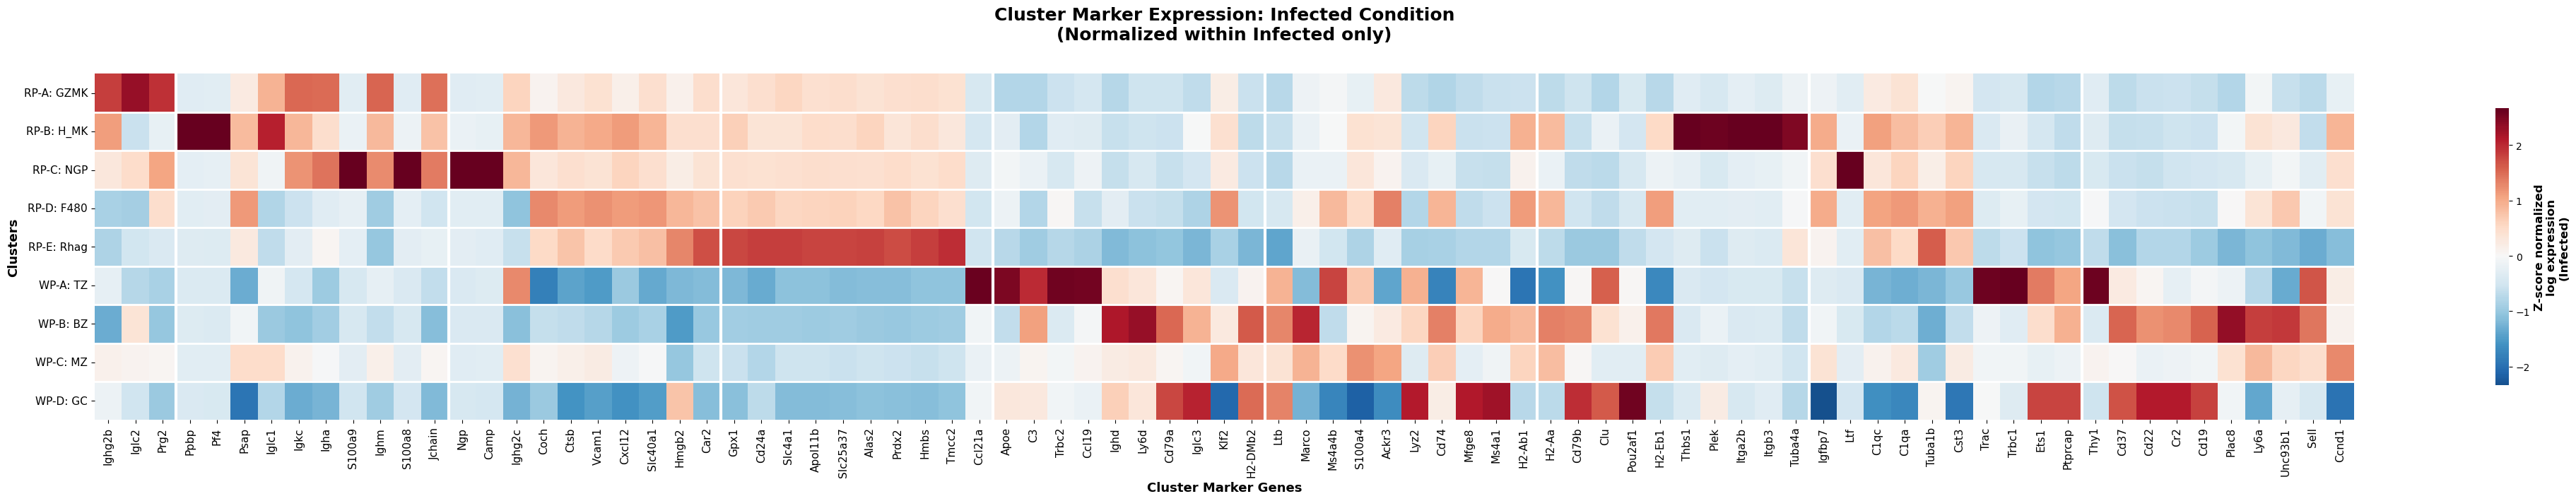

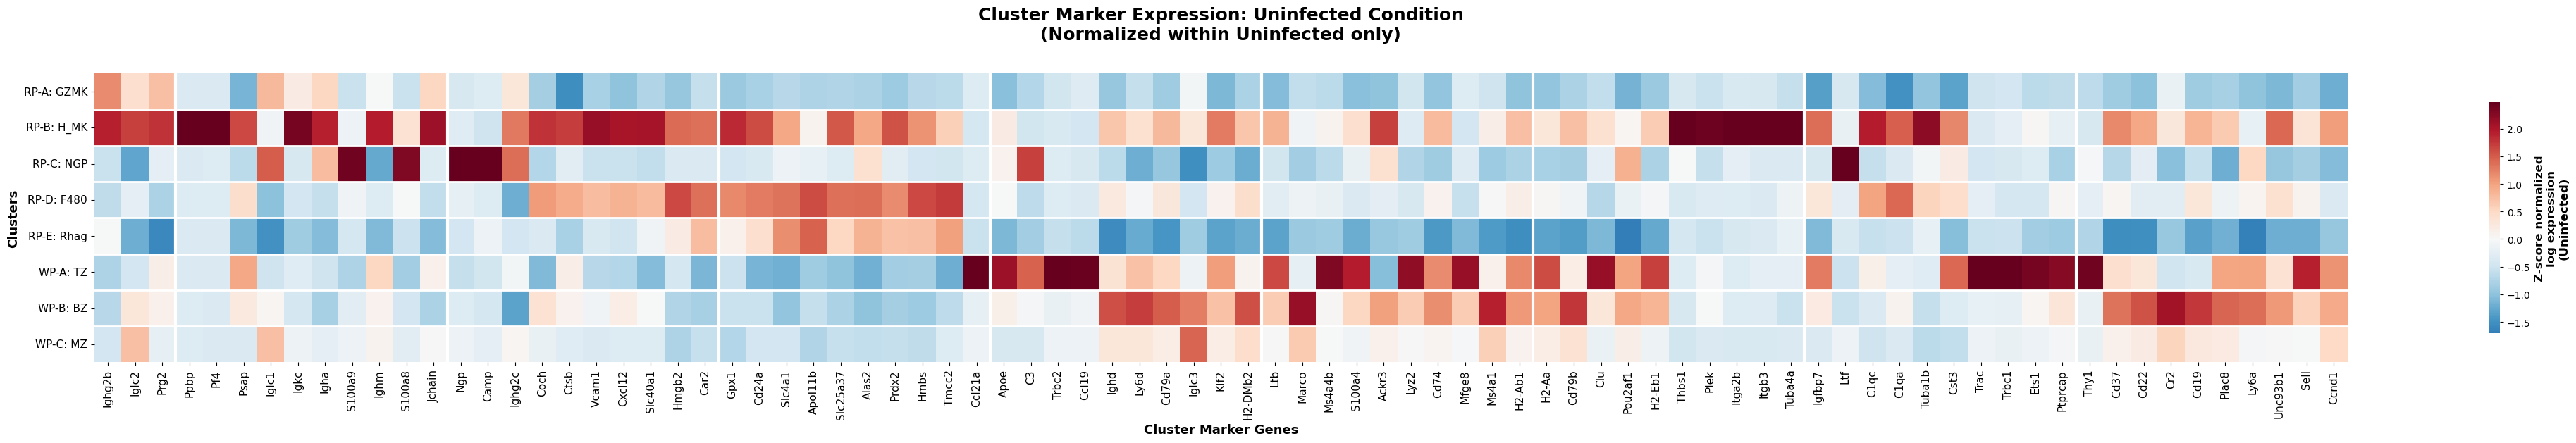

In [235]:
def create_separate_condition_summary_stats(heatmap_df, clusters, gene_to_cluster):
    """Create summary statistics for each condition separately"""
    print("\nCreating separate condition summary statistics...")
    
    # Split the data by condition
    infected_rows = [row for row in heatmap_df.index if '_Infected' in row]
    uninfected_rows = [row for row in heatmap_df.index if '_Uninfected' in row]
    
    infected_df = heatmap_df.loc[infected_rows].copy()
    uninfected_df = heatmap_df.loc[uninfected_rows].copy()
    
    # Clean up row names
    infected_df.index = [row.replace('_Infected', '') for row in infected_df.index]
    uninfected_df.index = [row.replace('_Uninfected', '') for row in uninfected_df.index]
    
    def create_condition_stats(data_df, condition_name):
        summary_stats = []
        
        for cluster in clusters:
            cluster_genes = [g for g in data_df.columns if gene_to_cluster.get(g) == cluster]
            
            if len(cluster_genes) == 0 or cluster not in data_df.index:
                continue
                
            cluster_data = data_df.loc[cluster, cluster_genes]
            
            summary_stats.append({
                'cluster': cluster,
                'condition': condition_name,
                'n_marker_genes': len(cluster_genes),
                'mean_expression': cluster_data.mean(),
                'median_expression': cluster_data.median(),
                'std_expression': cluster_data.std(),
                'min_expression': cluster_data.min(),
                'max_expression': cluster_data.max()
            })
        
        return pd.DataFrame(summary_stats)
    
    # Create stats for each condition
    infected_stats = create_condition_stats(infected_df, "Infected")
    uninfected_stats = create_condition_stats(uninfected_df, "Uninfected")
    
    # Combine and save
    combined_stats = pd.concat([infected_stats, uninfected_stats], ignore_index=True)
    combined_stats.to_csv("separate_conditions_summary_stats.csv", index=False)
    
    print("\nSeparate Condition Summary Statistics:")
    print("="*80)
    print(combined_stats.round(3).to_string(index=False))
    
    return combined_stats

def main_separate_conditions():
    """Main execution function for separate conditions"""
    print("="*80)
    print("SEPARATE CONDITIONS HEATMAP GENERATION")
    print("="*80)
    
    try:
        # Load data
        markers_df, conditions_df, adata_combined = load_results_and_data()
        
        # Prepare heatmap data (FDR significant genes only)
        heatmap_df, clusters, gene_to_cluster = prepare_heatmap_data(markers_df, conditions_df, adata_combined, top_n=10)
        
        # Create separate condition heatmaps
        infected_fig, uninfected_fig = create_separate_condition_heatmaps(heatmap_df, clusters, gene_to_cluster, top_n=10)
        
        # Create separate condition summary statistics
        summary_df = create_separate_condition_summary_stats(heatmap_df, clusters, gene_to_cluster)
        
        print("\n" + "="*80)
        print("ANALYSIS COMPLETE")
        print("="*80)
        print("Files created:")
        print("  - cluster_markers_infected_heatmap.png/pdf")
        print("  - cluster_markers_uninfected_heatmap.png/pdf")
        print("  - infected_conditions_expression_matrix.csv")
        print("  - uninfected_conditions_expression_matrix.csv")
        print("  - separate_conditions_summary_stats.csv")
        print("\nEach heatmap shows cluster marker genes normalized independently!")
        print("This allows direct comparison of marker expression patterns within each condition.")
        
    except Exception as e:
        print(f"❌ Error: {e}")
        print("Make sure to run cluster_marker_analysis_combined_conditions.py first")

# Run the separate conditions analysis
main_separate_conditions()


In [236]:
#!/usr/bin/env python3
"""
Corrected Cluster Marker Analysis - Combined Conditions

Find cluster-specific markers using ALL data (infected + uninfected combined),
then extract expression of those same genes in both conditions for comparison.

This approach allows proper comparison of how cluster markers respond to infection.
"""

import numpy as np
import pandas as pd
import scanpy as sc
import scipy.stats as stats
from scipy.stats import ranksums
from statsmodels.stats.multitest import multipletests
import warnings
import os
from pathlib import Path

# Suppress warnings for cleaner output
warnings.filterwarnings('ignore')

def setup_logging():
    """Setup basic logging"""
    print("="*80)
    print("CLUSTER MARKER ANALYSIS - COMBINED CONDITIONS")
    print("="*80)

def load_and_preprocess_data():
    """Load data and perform proper normalization and filtering"""
    print("\n1. LOADING AND PREPROCESSING DATA")
    print("-" * 40)
    
    # Load raw data
    print("Loading h5ad files...")
    adata_infected = sc.read_h5ad('/Users/yashkulkarni/cellxgene_data/cell2location_infected_030525_yk.h5ad')
    adata_uninfected = sc.read_h5ad('/Users/yashkulkarni/cellxgene_data/cell2location_uninfected_030525_yk.h5ad')
    
    print(f"Infected: {adata_infected.shape[0]} spots, {adata_infected.shape[1]} genes")
    print(f"Uninfected: {adata_uninfected.shape[0]} spots, {adata_uninfected.shape[1]} genes")
    
    # Combine data for consistent processing
    adata_combined = adata_infected.concatenate(adata_uninfected, batch_key='condition', 
                                               batch_categories=['infected', 'uninfected'])
    
    # Check if already normalized
    if 'log1p' in adata_infected.uns:
        print("⚠️  Data appears already log-transformed. Using existing normalization.")
    else:
        print("Performing size-factor normalization and log-transformation...")
        # Save raw counts
        adata_combined.raw = adata_combined
        # Normalize and log-transform
        sc.pp.normalize_total(adata_combined, target_sum=1e4)
        sc.pp.log1p(adata_combined)
        # Mark as normalized
        adata_combined.uns['log1p'] = {'base': None}
    
    # Gene filtering to reduce multiple testing burden
    print("Filtering low-expression genes...")
    n_genes_before = adata_combined.shape[1]
    sc.pp.filter_genes(adata_combined, min_cells=5)  # Gene expressed in ≥5 spots
    n_genes_after = adata_combined.shape[1]
    print(f"Filtered from {n_genes_before} to {n_genes_after} genes ({n_genes_before - n_genes_after} removed)")
    
    return adata_combined

def get_cluster_info(adata):
    """Extract cluster information and validate sample sizes"""
    print("\n2. CLUSTER INFORMATION AND VALIDATION") 
    print("-" * 40)
    
    # Get unique clusters
    all_clusters = sorted(adata.obs['paper_clusters'].unique())
    print(f"All clusters ({len(all_clusters)}): {all_clusters}")
    
    # Validate sample sizes (minimum 5 spots per cluster)
    valid_clusters = []
    
    print("\nSample size validation (minimum 5 spots per cluster):")
    for cluster in all_clusters:
        cluster_mask = adata.obs['paper_clusters'] == cluster
        n_cluster = np.sum(cluster_mask)
        n_other = len(adata) - n_cluster
        
        print(f"  {cluster}: {n_cluster} spots in cluster, {n_other} others")
        
        if n_cluster >= 5 and n_other >= 5:
            valid_clusters.append(cluster)
            print(f"    ✅ Valid for analysis")
        else:
            print(f"    ❌ Insufficient sample size")
    
    print(f"\nValid clusters for analysis: {len(valid_clusters)}")
    return valid_clusters

def perform_cluster_marker_analysis(adata, cluster, min_detection_diff=0, filter_contaminating_genes=True):
    """
    Find markers for one cluster vs all others using combined data
    """
    cluster_mask = adata.obs['paper_clusters'] == cluster
    other_mask = ~cluster_mask
    
    n_cluster = np.sum(cluster_mask)
    n_other = np.sum(other_mask)
    
    print(f"  Testing {cluster}: {n_cluster} vs {n_other} spots")
    
    # Get expression matrix
    if hasattr(adata.X, 'toarray'):
        expr_matrix = adata.X.toarray()
    else:
        expr_matrix = adata.X
    
    cluster_expr = expr_matrix[cluster_mask, :]
    other_expr = expr_matrix[other_mask, :]
    
    results = []
    
    for gene_idx in range(adata.shape[1]):
        gene_name = adata.var_names[gene_idx]
        
        cluster_values = cluster_expr[:, gene_idx]
        other_values = other_expr[:, gene_idx]
        
        # Calculate means (on log-transformed data)
        mean_cluster = np.mean(cluster_values)
        mean_other = np.mean(other_values)
        

        # Calculate log2 fold change directly from log-transformed data
        log2_fold_change = mean_cluster - mean_other
        # Don't calculate linear fold change - it creates astronomical values with log data
        
        # Statistical test (on log-transformed values)
        try:
            statistic, pval = ranksums(cluster_values, other_values)
        except ValueError:
            # Handle edge cases (e.g., identical values)
            pval = 1.0
            statistic = 0.0
        
        results.append({
            'gene': gene_name,
            'cluster': cluster,
            'mean_log1p_cluster': mean_cluster,
            'mean_log1p_other': mean_other,
            'log2_fold_change': log2_fold_change,
            'statistic': statistic,
            'pval': pval
        })
    
    if not results:
        print(f"    ⚠️  No genes passed detection filter")
        return None
    
        # Convert to DataFrame
    results_df = pd.DataFrame(results)
    
    # Filter out potentially contaminating genes if requested
    if filter_contaminating_genes:
        contaminating_prefixes = ['Hbb-', 'Hba-']  # Focus on hemoglobin genes
        contaminating_genes = ['Hbb-bt', 'Hbb-bs', 'Hba-a1', 'Hba-a2']
        
        # Filter out genes with contaminating prefixes or exact matches
        original_count = len(results_df)
        results_df = results_df[~results_df['gene'].str.startswith(tuple(contaminating_prefixes))]
        results_df = results_df[~results_df['gene'].isin(contaminating_genes)]
        filtered_count = len(results_df)
        
        print(f"    📝 Filtered {original_count - filtered_count} hemoglobin genes")
    
    # Apply FDR correction per cluster comparison
    _, padj, _, _ = multipletests(results_df['pval'], method='fdr_bh')
    results_df['padj'] = padj
    
    # Filter for significance AND positive fold changes (cluster markers should be enriched)
    # Use relaxed FDR threshold for GZMK cluster due to large sample size
    fdr_threshold = 0.05 if 'GZMK' in cluster else 0.05
    significant_df = results_df[(results_df['padj'] < fdr_threshold) & (results_df['log2_fold_change'] > 0)].copy()
    
    # Debug output for GZMK cluster
    if 'GZMK' in cluster:
        print(f"    🔍 DEBUG {cluster} (using relaxed FDR < 0.2):")
        print(f"        Total genes tested: {len(results_df)}")
        print(f"        Significant (p < 0.05): {len(results_df[results_df['padj'] < 0.05])}")
        print(f"        Significant (p < 0.2): {len(results_df[results_df['padj'] < 0.2])}")
        print(f"        Positive fold change: {len(results_df[results_df['log2_fold_change'] > 0])}")
        print(f"        Both significant + positive (FDR < 0.2): {len(significant_df)}")
        
        # Show top candidates even if not significant
        if len(significant_df) < 20:
            print(f"        Top 15 positive fold change genes (with relaxed threshold):")
            top_positive = results_df[results_df['log2_fold_change'] > 0].sort_values('log2_fold_change', ascending=False).head(15)
            for idx, row in top_positive.iterrows():
                sig_marker = "✅" if row['padj'] < 0.2 else "❌"
                print(f"          {sig_marker} {row['gene']}: log2FC={row['log2_fold_change']:.2f}, padj={row['padj']:.2e}")
    
    if len(significant_df) == 0:
        print(f"    ⚠️  No significant genes with positive fold changes after FDR correction")
        return None
    
    # Sort by log2 fold change (descending)
    significant_df = significant_df.sort_values('log2_fold_change', ascending=False)
    
    print(f"    ✅ {len(significant_df)} significant genes (FDR < {fdr_threshold})")
    
    return significant_df

def extract_condition_expression(adata, genes, cluster):
    """
    Extract expression of specified genes in infected vs uninfected for a cluster
    """
    cluster_mask = adata.obs['paper_clusters'] == cluster
    infected_mask = adata.obs['condition'] == 'infected'
    uninfected_mask = adata.obs['condition'] == 'uninfected'
    
    # Get spots for this cluster in each condition
    cluster_infected = cluster_mask & infected_mask
    cluster_uninfected = cluster_mask & uninfected_mask
    
    n_infected = np.sum(cluster_infected)
    n_uninfected = np.sum(cluster_uninfected)
    
    # Get expression matrix
    if hasattr(adata.X, 'toarray'):
        expr_matrix = adata.X.toarray()
    else:
        expr_matrix = adata.X
    
    results = []
    
    for gene in genes:
        if gene not in adata.var_names:
            continue
            
        gene_idx = list(adata.var_names).index(gene)
        
        # Extract expression for this gene in this cluster
        infected_expr = expr_matrix[cluster_infected, gene_idx] if n_infected > 0 else []
        uninfected_expr = expr_matrix[cluster_uninfected, gene_idx] if n_uninfected > 0 else []
        
        # Calculate means (on log1p-normalized scale, consistent with discovery)
        mean_log1p_infected = np.mean(infected_expr) if len(infected_expr) > 0 else 0
        mean_log1p_uninfected = np.mean(uninfected_expr) if len(uninfected_expr) > 0 else 0
        
        # Calculate log2 fold change (same scale as discovery phase)
        log2_fold_change = mean_log1p_infected - mean_log1p_uninfected
        
        # Calculate detection frequencies
        detect_infected = np.mean(np.array(infected_expr) > 0) if len(infected_expr) > 0 else 0
        detect_uninfected = np.mean(np.array(uninfected_expr) > 0) if len(uninfected_expr) > 0 else 0
        
        results.append({
            'gene': gene,
            'cluster': cluster,
            'mean_log1p_infected': mean_log1p_infected,
            'mean_log1p_uninfected': mean_log1p_uninfected,
            'log2_fold_change': log2_fold_change,
            'detection_infected': detect_infected,
            'detection_uninfected': detect_uninfected,
            'n_spots_infected': n_infected,
            'n_spots_uninfected': n_uninfected
        })
    
    return pd.DataFrame(results)

def main():
    """Main analysis pipeline"""
    setup_logging()
    
    # Step 1: Load and preprocess data
    adata_combined = load_and_preprocess_data()
    
    # Step 2: Get cluster information
    valid_clusters = get_cluster_info(adata_combined)
    
    # Step 3: Find cluster markers using combined data
    print("\n3. CLUSTER MARKER IDENTIFICATION (COMBINED DATA)")
    print("-" * 40)
    
    output_dir = Path("combined_marker_results")
    output_dir.mkdir(exist_ok=True)
    
    all_cluster_markers = []
    all_condition_comparisons = []
    
    for cluster in valid_clusters:
        print(f"\nAnalyzing {cluster}...")
        
        # Find markers for this cluster vs all others
        markers = perform_cluster_marker_analysis(adata_combined, cluster, filter_contaminating_genes=True)
        
        if markers is not None:
            all_cluster_markers.append(markers)
            
            # Save individual cluster results
            safe_name = cluster.replace(':', '').replace('-', '_').replace(' ', '_')
            markers.to_csv(output_dir / f"{safe_name}_markers.csv", index=False)
            
            # Get top 10 markers
            top10_markers = markers.head(10)
            top10_genes = top10_markers['gene'].tolist()
            
            # Extract expression in infected vs uninfected for these top 10 genes
            condition_expr = extract_condition_expression(adata_combined, top10_genes, cluster)
            all_condition_comparisons.append(condition_expr)
            
            # Save top 10 with condition comparison
            top10_with_conditions = top10_markers.merge(
                condition_expr[['gene', 'mean_log1p_infected', 'mean_log1p_uninfected', 'log2_fold_change']], 
                on='gene', how='left'
            )
            top10_with_conditions.to_csv(output_dir / f"{safe_name}_top10_with_conditions.csv", index=False)
            
            print(f"    Top marker: {top10_markers.iloc[0]['gene']} (log2FC: {top10_markers.iloc[0]['log2_fold_change']:.2f})")
    
    # Combine all results
    if all_cluster_markers:
        combined_markers = pd.concat(all_cluster_markers, ignore_index=True)
        combined_markers.to_csv(output_dir / "all_cluster_markers.csv", index=False)
        
        combined_conditions = pd.concat(all_condition_comparisons, ignore_index=True)
        combined_conditions.to_csv(output_dir / "all_condition_comparisons.csv", index=False)
        
        print(f"\n✅ Analysis complete! Results saved to {output_dir}/")
        print(f"Total significant marker genes: {len(combined_markers)}")
        print(f"Total condition comparisons: {len(combined_conditions)}")
    
    # Step 4: Summary
    print("\n4. SUMMARY")
    print("-" * 40)
    print("Analysis approach:")
    print("  1. Find cluster markers using ALL data (infected + uninfected)")
    print("  2. Extract expression of same genes in infected vs uninfected")
    print("  3. This allows direct comparison of cluster marker response to infection")
    print("\nStatistical parameters:")
    print("  Gene detection threshold: ≥10% frequency difference")
    print("  Statistical test: Wilcoxon rank-sum")
    print("  Multiple testing correction: Benjamini-Hochberg FDR per cluster")
    print("  Significance threshold: padj < 0.05")
    print("  Minimum sample size: 5 spots per cluster")
    
    print("="*80)

if __name__ == "__main__":
    main() 

CLUSTER MARKER ANALYSIS - COMBINED CONDITIONS

1. LOADING AND PREPROCESSING DATA
----------------------------------------
Loading h5ad files...
Infected: 1268 spots, 5155 genes
Uninfected: 1277 spots, 5155 genes
⚠️  Data appears already log-transformed. Using existing normalization.
Filtering low-expression genes...
Filtered from 5155 to 5155 genes (0 removed)

2. CLUSTER INFORMATION AND VALIDATION
----------------------------------------
All clusters (9): ['RP-A: GZMK', 'RP-B: H_MK', 'RP-C: NGP', 'RP-D: F480', 'RP-E: Rhag', 'WP-A: TZ', 'WP-B: BZ', 'WP-C: MZ', 'WP-D: GC']

Sample size validation (minimum 5 spots per cluster):
  RP-A: GZMK: 519 spots in cluster, 2026 others
    ✅ Valid for analysis
  RP-B: H_MK: 108 spots in cluster, 2437 others
    ✅ Valid for analysis
  RP-C: NGP: 128 spots in cluster, 2417 others
    ✅ Valid for analysis
  RP-D: F480: 238 spots in cluster, 2307 others
    ✅ Valid for analysis
  RP-E: Rhag: 483 spots in cluster, 2062 others
    ✅ Valid for analysis
  

COMBINED CONDITIONS HEATMAP GENERATION
Loading analysis results and data...
Loaded 5691 marker genes across 9 clusters
Condition comparisons: 87 gene-cluster combinations
Preparing heatmap data with top 10 genes per cluster (FDR significant only)...
  RP-A: GZMK: 7 FDR significant genes, using top 7
  RP-B: H_MK: 1536 FDR significant genes, using top 10
  RP-C: NGP: 705 FDR significant genes, using top 10
  RP-D: F480: 768 FDR significant genes, using top 10
  RP-E: Rhag: 381 FDR significant genes, using top 10
  WP-A: TZ: 550 FDR significant genes, using top 10
  WP-B: BZ: 945 FDR significant genes, using top 10
  WP-C: MZ: 64 FDR significant genes, using top 10
  WP-D: GC: 735 FDR significant genes, using top 10
  Duplicate resolved: Igkc assigned to RP-C: NGP (|log2FC|=56.78), removed from RP-A: GZMK
  Duplicate resolved: Igkc assigned to RP-C: NGP (|log2FC|=136.69), removed from RP-B: H_MK
  Duplicate resolved: Ighm assigned to RP-C: NGP (|log2FC|=16.75), removed from RP-A: GZMK
  

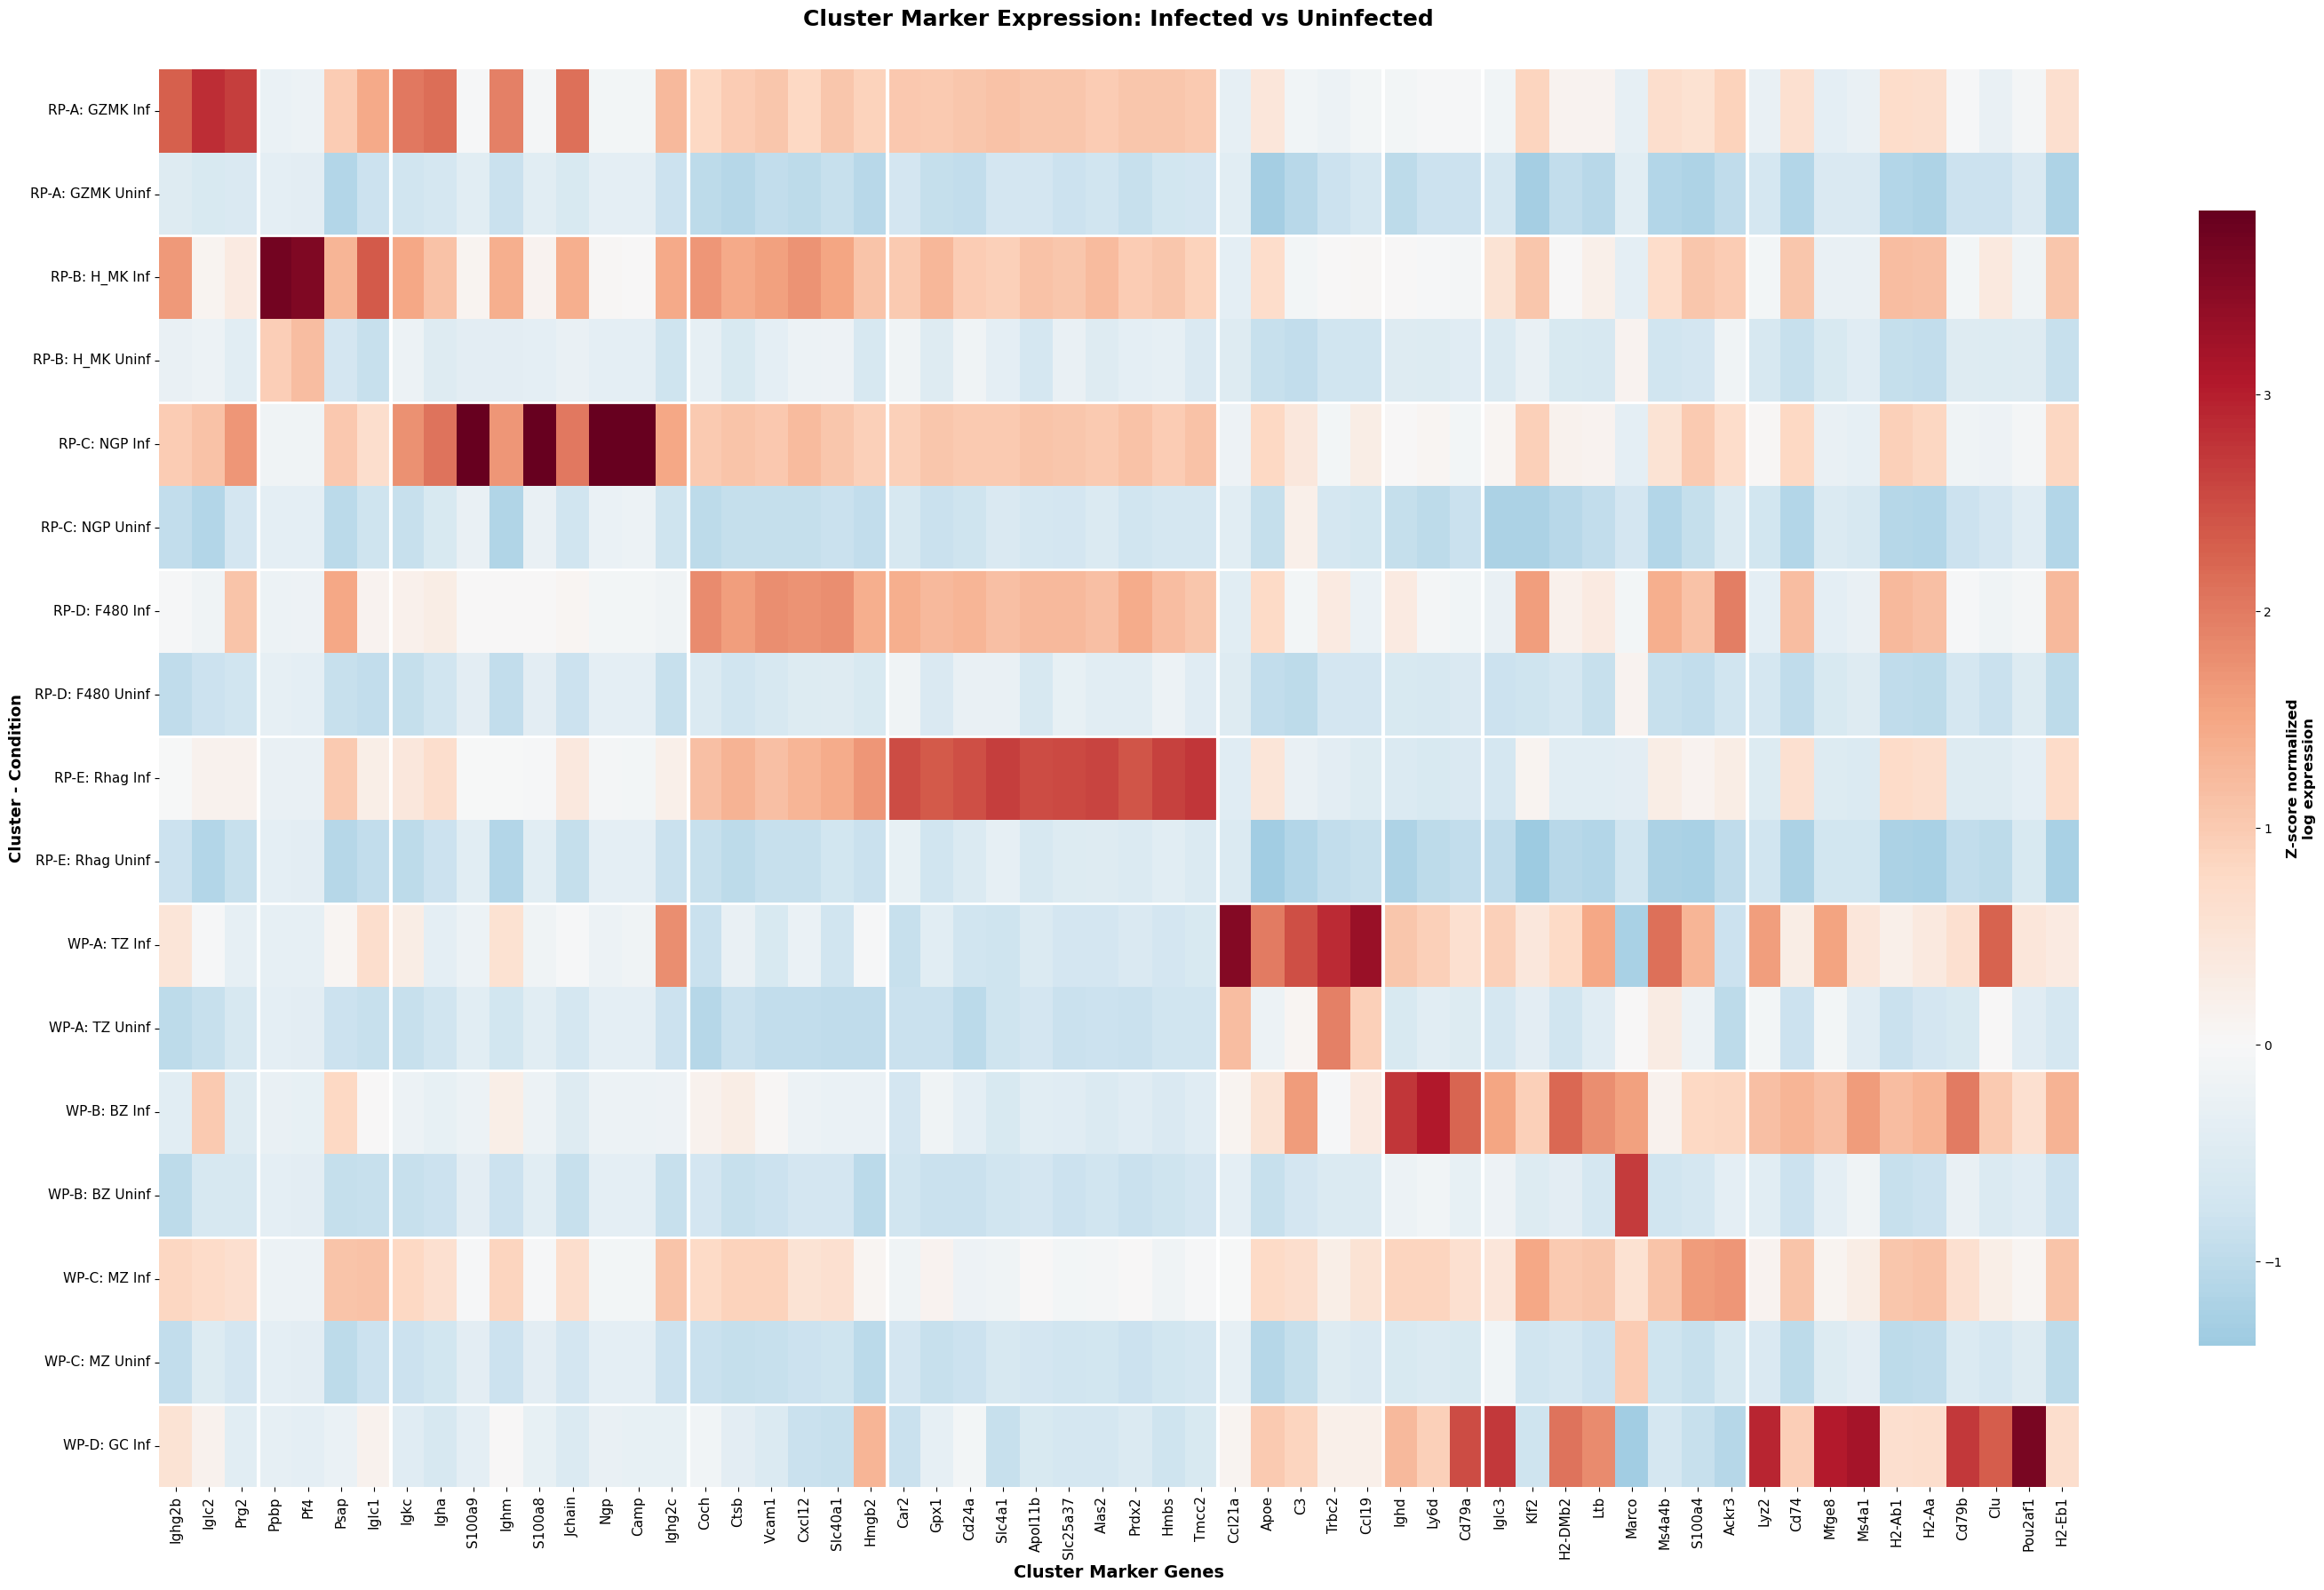

In [237]:
#!/usr/bin/env python3
"""
Create heatmap for combined conditions cluster marker analysis

Shows the same cluster-defining genes (found using combined data) 
expressed in infected vs uninfected conditions for direct comparison.
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scanpy as sc
from pathlib import Path
import warnings

warnings.filterwarnings('ignore')

def load_results_and_data():
    """Load analysis results and original data"""
    print("Loading analysis results and data...")
    
    # Check if results exist
    results_dir = Path("combined_marker_results")
    if not results_dir.exists():
        raise FileNotFoundError("Combined marker results not found. Run cluster_marker_analysis_combined_conditions.py first")
    
    # Load cluster markers and condition comparisons
    markers_df = pd.read_csv(results_dir / "all_cluster_markers.csv")
    conditions_df = pd.read_csv(results_dir / "all_condition_comparisons.csv")
    
    # Load original data for expression extraction
    adata_infected = sc.read_h5ad('/Users/yashkulkarni/cellxgene_data/cell2location_infected_030525_yk.h5ad')
    adata_uninfected = sc.read_h5ad('/Users/yashkulkarni/cellxgene_data/cell2location_uninfected_030525_yk.h5ad')
    
    # Combine data
    adata_combined = adata_infected.concatenate(adata_uninfected, batch_key='condition', 
                                               batch_categories=['infected', 'uninfected'])
    
    print(f"Loaded {len(markers_df)} marker genes across {len(markers_df['cluster'].unique())} clusters")
    print(f"Condition comparisons: {len(conditions_df)} gene-cluster combinations")
    
    return markers_df, conditions_df, adata_combined

def prepare_heatmap_data(markers_df, conditions_df, adata_combined, top_n=10):
    """Prepare data matrix for heatmap"""
    print(f"Preparing heatmap data with top {top_n} genes per cluster (FDR significant only)...")
    
    # Get clusters in order
    clusters = sorted(markers_df['cluster'].unique())
    
    # Collect genes for heatmap (top N per cluster, FDR significant only)
    heatmap_genes = []
    cluster_gene_mapping = {}
    
    for cluster in clusters:
        cluster_markers = markers_df[markers_df['cluster'] == cluster]
        
        # Just take top N by fold change (already FDR significant from discovery)
        top_genes = cluster_markers.head(top_n)['gene'].tolist()
        
        heatmap_genes.extend(top_genes)
        cluster_gene_mapping[cluster] = top_genes
        print(f"  {cluster}: {len(cluster_markers)} FDR significant genes, using top {len(top_genes)}")
    
    # Step 1: Collect initial top N genes per cluster (may contain duplicates)
    cluster_initial_genes = {}
    all_gene_cluster_info = {}  # gene -> [(cluster, fold_change, log2_fc), ...]
    
    for cluster in clusters:
        cluster_markers = markers_df[markers_df['cluster'] == cluster]
        top_genes_data = cluster_markers.head(top_n)
        
        cluster_initial_genes[cluster] = []
        
        for _, row in top_genes_data.iterrows():
            gene = row['gene']
            log2_fc = row['log2_fold_change']
            # Use absolute log2 fold change for ranking (more standard for DE analysis)
            abs_log2_fc = abs(log2_fc)
            
            cluster_initial_genes[cluster].append(gene)
            
            # Track all cluster-gene relationships for duplicate resolution
            if gene not in all_gene_cluster_info:
                all_gene_cluster_info[gene] = []
            all_gene_cluster_info[gene].append((cluster, abs_log2_fc, log2_fc))
    
    # Step 2: Resolve duplicates - assign each gene to cluster with highest fold change
    gene_final_assignment = {}  # gene -> cluster
    clusters_lost_genes = {}  # cluster -> [genes it lost to other clusters]
    
    for gene, cluster_info_list in all_gene_cluster_info.items():
        if len(cluster_info_list) > 1:
            # This gene appears in multiple clusters - find best assignment
            best_cluster = max(cluster_info_list, key=lambda x: x[1])[0]  # highest abs log2 fold change
            gene_final_assignment[gene] = best_cluster
            
            # Track which clusters lost this gene
            for cluster, abs_log2_fc, log2_fc in cluster_info_list:
                if cluster != best_cluster:
                    if cluster not in clusters_lost_genes:
                        clusters_lost_genes[cluster] = []
                    clusters_lost_genes[cluster].append(gene)
                    print(f"  Duplicate resolved: {gene} assigned to {best_cluster} (|log2FC|={abs_log2_fc:.2f}), removed from {cluster}")
        else:
            # Gene only appears in one cluster
            gene_final_assignment[gene] = cluster_info_list[0][0]
    
    # Step 3: Build final gene list and track what each cluster actually got
    unique_genes = []
    gene_to_cluster = {}
    cluster_final_genes = {}
    
    for cluster in clusters:
        cluster_final_genes[cluster] = []
        
        # Get genes that were assigned to this cluster after duplicate resolution
        for gene in cluster_initial_genes[cluster]:
            if gene_final_assignment[gene] == cluster:
                cluster_final_genes[cluster].append(gene)
                unique_genes.append(gene)
                gene_to_cluster[gene] = cluster
    
    # Step 4: No backfill - let clusters have the genes they naturally got after duplicate resolution
    # This ensures all genes are truly the best markers for their assigned clusters
    
    for cluster in clusters:
        lost_genes = clusters_lost_genes.get(cluster, [])
        current_count = len(cluster_final_genes[cluster])
        
        if lost_genes:
            print(f"  {cluster}: has {current_count} genes after losing {len(lost_genes)} to other clusters")
            print(f"    Lost genes: {lost_genes}")
        else:
            print(f"  {cluster}: has {current_count} genes (no duplicates lost)")
    
    print(f"\nNo backfill performed - all genes are truly the best markers for their assigned clusters")
    
    # Count duplicates resolved
    total_genes_before = sum(len(cluster_gene_mapping[cluster]) for cluster in clusters)
    duplicates_resolved = total_genes_before - len(unique_genes)
    
    print(f"Total genes before duplicate removal: {total_genes_before}")
    print(f"Duplicates resolved: {duplicates_resolved}")
    print(f"Final unique genes for heatmap (after backfill): {len(unique_genes)}")
    
    # Show final gene count per cluster
    for cluster in clusters:
        cluster_gene_count = len([g for g in unique_genes if gene_to_cluster.get(g) == cluster])
        print(f"  {cluster}: {cluster_gene_count} final genes (all are best markers for this cluster)")
    
    # Create expression matrix for heatmap
    # Rows: infected and uninfected for each cluster (only if they exist)
    # Columns: genes (grouped by cluster)
    
    # Check which cluster-condition combinations actually exist
    cluster_counts = adata_combined.obs.groupby(['condition', 'paper_clusters']).size().unstack(fill_value=0)
    
    heatmap_rows = []
    for cluster in clusters:
        # Check if cluster exists in each condition
        infected_count = cluster_counts.loc['infected', cluster] if cluster in cluster_counts.columns else 0
        uninfected_count = cluster_counts.loc['uninfected', cluster] if cluster in cluster_counts.columns else 0
        
        if infected_count > 0:
            heatmap_rows.append(f"{cluster}_Infected")
        if uninfected_count > 0:
            heatmap_rows.append(f"{cluster}_Uninfected")
    
    print(f"Created {len(heatmap_rows)} rows (excluding non-existent condition-cluster combinations)")
    print(f"Rows: {heatmap_rows}")
    
    # Initialize matrix (rows = cluster-conditions, cols = genes)
    expression_matrix = np.zeros((len(heatmap_rows), len(unique_genes)))
    
    # Fill matrix with expression values - extract directly from adata for ALL clusters
    if hasattr(adata_combined.X, 'toarray'):
        expr_data = adata_combined.X.toarray()
    else:
        expr_data = adata_combined.X
    
    for gene_idx, gene in enumerate(unique_genes):
        if gene not in adata_combined.var_names:
            continue
            
        gene_adata_idx = list(adata_combined.var_names).index(gene)
        
        for row_idx, row_name in enumerate(heatmap_rows):
            # Parse cluster and condition from row name
            if '_Infected' in row_name:
                cluster = row_name.replace('_Infected', '')
                condition = 'infected'
            elif '_Uninfected' in row_name:
                cluster = row_name.replace('_Uninfected', '')
                condition = 'uninfected'
            else:
                continue
            
            # Get masks
            cluster_mask = adata_combined.obs['paper_clusters'] == cluster
            condition_mask = adata_combined.obs['condition'] == condition
            
            # Get spots for this cluster-condition combination
            spots = cluster_mask & condition_mask
            
            # Extract expression for this gene in this cluster-condition
            if np.sum(spots) > 0:
                expr = expr_data[spots, gene_adata_idx]
                mean_expr = np.mean(expr)
            else:
                mean_expr = 0
            
            expression_matrix[row_idx, gene_idx] = mean_expr
    
    # Create DataFrame (rows = cluster-conditions, columns = genes)
    heatmap_df = pd.DataFrame(
        expression_matrix,
        index=heatmap_rows,
        columns=unique_genes
    )
    
    return heatmap_df, clusters, gene_to_cluster

def create_heatmap(heatmap_df, clusters, gene_to_cluster, top_n=10):
    """Create the expression heatmap"""
    print("Creating heatmap...")
    
    # Z-score normalize for visualization (column-wise, i.e., per gene)
    heatmap_zscore = heatmap_df.apply(lambda x: (x - x.mean()) / x.std(), axis=0)
    
    # Replace NaN with 0 (for genes with no variance)
    heatmap_zscore = heatmap_zscore.fillna(0)
    
    # Set up the plot
    n_genes = len(heatmap_df.columns)  # genes are columns now
    n_clusters = len(clusters)
    
    # Dynamic figure size - genes on x-axis, clusters on y-axis
    fig_width = max(20, n_genes * 0.5)  # 0.5 inch per gene
    fig_height = max(8, n_clusters * 2)  # 2 inches per cluster (infected + uninfected)
    
    fig, ax = plt.subplots(figsize=(fig_width, fig_height))
    
    # Calculate actual data range for proper colorbar scaling
    data_min = heatmap_zscore.min().min()
    data_max = heatmap_zscore.max().max()
    
    # Create heatmap with improved colorbar positioning and proper scale
    sns.heatmap(
        heatmap_zscore,
        cmap='RdBu_r',
        center=0,
        vmin=data_min,
        vmax=data_max,
        cbar_kws={
            'label': 'Z-score normalized\nlog expression', 
            'shrink': 0.8,
            'pad': 0.05,  # More padding for tick labels
            'aspect': 20,  # Make colorbar wider to fit labels
        },
        xticklabels=True,
        yticklabels=True,
        ax=ax
    )
    
    # Customize x-axis labels (genes) - make them bigger
    ax.set_xticklabels(heatmap_df.columns, rotation=90, ha='center', fontsize=11)
    
    # Customize y-axis labels (cluster-conditions)
    y_labels = []
    for row_name in heatmap_df.index:
        # Clean up cluster-condition names
        if '_Infected' in row_name:
            cluster_name = row_name.replace('_Infected', '')
            y_labels.append(f"{cluster_name} Inf")
        elif '_Uninfected' in row_name:
            cluster_name = row_name.replace('_Uninfected', '')
            y_labels.append(f"{cluster_name} Uninf")
        else:
            y_labels.append(row_name)
    
    ax.set_yticklabels(y_labels, fontsize=11)
    
    # Add gene cluster separators (vertical lines between gene groups)
    gene_positions = []
    gene_count = 0
    
    for cluster in clusters:
        cluster_genes = [g for g in heatmap_df.columns if gene_to_cluster.get(g) == cluster]
        gene_start = gene_count
        gene_count += len(cluster_genes)
        gene_end = gene_count
        gene_positions.append((gene_start, gene_end, cluster))
        
        # Add vertical line to separate gene clusters
        if gene_end < len(heatmap_df.columns):
            ax.axvline(x=gene_end, color='white', linewidth=3)
    
    # Add horizontal lines to separate clusters
    cluster_boundaries = []
    current_pos = 0
    
    for cluster in clusters:
        # Count how many rows this cluster has
        cluster_rows = sum(1 for row in heatmap_df.index if row.startswith(cluster))
        current_pos += cluster_rows
        if current_pos < len(heatmap_df.index):
            cluster_boundaries.append(current_pos)
    
    # Draw horizontal lines between cluster groups
    for boundary in cluster_boundaries:
        ax.axhline(y=boundary, color='white', linewidth=2)
    
    # Improve colorbar label and add appropriate scale values
    cbar = ax.collections[0].colorbar
    cbar.set_label('Z-score normalized\nlog expression', fontsize=12, weight='bold')
    
    
    
    # Title and labels - improved for publication quality
    ax.set_title('Cluster Marker Expression: Infected vs Uninfected',
                fontsize=18, weight='bold', pad=35)
    ax.set_xlabel('Cluster Marker Genes', fontsize=14, weight='bold')
    ax.set_ylabel('Cluster - Condition', fontsize=13, weight='bold')
    
    # Adjust layout
    plt.tight_layout()
    
    # Save plots
    output_prefix = "combined_conditions_heatmap"
    plt.savefig(f"{output_prefix}.png", dpi=300, bbox_inches='tight', facecolor='white')
    plt.savefig(f"{output_prefix}.pdf", bbox_inches='tight', facecolor='white')
    
    print(f"✅ Heatmap saved as {output_prefix}.png and .pdf")
    
    return fig

def create_summary_stats(heatmap_df, clusters, gene_to_cluster):
    """Create summary statistics"""
    print("\nCreating summary statistics...")
    
    summary_stats = []
    
    for cluster in clusters:
        cluster_genes = [g for g in heatmap_df.columns if gene_to_cluster.get(g) == cluster]
        
        if len(cluster_genes) == 0:
            continue
            
        # Get infected and uninfected rows for this cluster
        infected_row = f"{cluster}_Infected"
        uninfected_row = f"{cluster}_Uninfected"
        
        # Check which conditions exist for this cluster
        has_infected = infected_row in heatmap_df.index
        has_uninfected = uninfected_row in heatmap_df.index
        
        if has_infected and has_uninfected:
            # Both conditions exist - full comparison
            cluster_data_infected = heatmap_df.loc[infected_row, cluster_genes]
            cluster_data_uninfected = heatmap_df.loc[uninfected_row, cluster_genes]
            
            mean_infected = cluster_data_infected.mean()
            mean_uninfected = cluster_data_uninfected.mean()
            expression_diff = mean_infected - mean_uninfected
            
            higher_in_infected = sum(cluster_data_infected > cluster_data_uninfected)
            higher_in_uninfected = sum(cluster_data_uninfected > cluster_data_infected)
            
            summary_stats.append({
                'cluster': cluster,
                'n_marker_genes': len(cluster_genes),
                'mean_expr_infected': mean_infected,
                'mean_expr_uninfected': mean_uninfected,
                'expression_difference': expression_diff,
                'genes_higher_infected': higher_in_infected,
                'genes_higher_uninfected': higher_in_uninfected,
                'infection_bias': 'Infected' if expression_diff > 0 else 'Uninfected'
            })
        elif has_infected:
            # Only infected condition exists
            cluster_data_infected = heatmap_df.loc[infected_row, cluster_genes]
            mean_infected = cluster_data_infected.mean()
            
            summary_stats.append({
                'cluster': cluster,
                'n_marker_genes': len(cluster_genes),
                'mean_expr_infected': mean_infected,
                'mean_expr_uninfected': 0,
                'expression_difference': mean_infected,
                'genes_higher_infected': len(cluster_genes),
                'genes_higher_uninfected': 0,
                'infection_bias': 'Infected only'
            })
        elif has_uninfected:
            # Only uninfected condition exists
            cluster_data_uninfected = heatmap_df.loc[uninfected_row, cluster_genes]
            mean_uninfected = cluster_data_uninfected.mean()
            
            summary_stats.append({
                'cluster': cluster,
                'n_marker_genes': len(cluster_genes),
                'mean_expr_infected': 0,
                'mean_expr_uninfected': mean_uninfected,
                'expression_difference': -mean_uninfected,
                'genes_higher_infected': 0,
                'genes_higher_uninfected': len(cluster_genes),
                'infection_bias': 'Uninfected only'
            })
    
    summary_df = pd.DataFrame(summary_stats)
    summary_df.to_csv("combined_conditions_summary_stats.csv", index=False)
    
    print("\nCluster Summary Statistics:")
    print("="*80)
    print(summary_df.round(3).to_string(index=False))
    
    return summary_df

def main():
    """Main execution function"""
    print("="*80)
    print("COMBINED CONDITIONS HEATMAP GENERATION")
    print("="*80)
    
    try:
        # Load data
        markers_df, conditions_df, adata_combined = load_results_and_data()
        
        # Prepare heatmap data (FDR significant genes only)
        heatmap_df, clusters, gene_to_cluster = prepare_heatmap_data(markers_df, conditions_df, adata_combined, top_n=10)
        
        # Create heatmap
        fig = create_heatmap(heatmap_df, clusters, gene_to_cluster, top_n=10)
        
        # Create summary statistics
        summary_df = create_summary_stats(heatmap_df, clusters, gene_to_cluster)
        
        # Save expression matrix
        heatmap_df.to_csv("combined_conditions_expression_matrix.csv")
        print(f"\n✅ Expression matrix saved as combined_conditions_expression_matrix.csv")
        
        print("\n" + "="*80)
        print("ANALYSIS COMPLETE")
        print("="*80)
        print("Files created:")
        print("  - combined_conditions_heatmap.png/pdf")
        print("  - combined_conditions_expression_matrix.csv")
        print("  - combined_conditions_summary_stats.csv")
        print("\nThis heatmap shows the SAME cluster marker genes")
        print("expressed in infected vs uninfected conditions for direct comparison!")
        
    except Exception as e:
        print(f"❌ Error: {e}")
        print("Make sure to run cluster_marker_analysis_combined_conditions.py first")

if __name__ == "__main__":
    main() 

In [238]:
def create_heatmap(heatmap_df, clusters, gene_to_cluster, top_n=10):
    """Create the expression heatmap"""
    print("Creating heatmap...")
    
    # Z-score normalize for visualization (column-wise, i.e., per gene)
    heatmap_zscore = heatmap_df.apply(lambda x: (x - x.mean()) / x.std(), axis=0)
    
    # Replace NaN with 0 (for genes with no variance)
    heatmap_zscore = heatmap_zscore.fillna(0)
    
    # Set up the plot
    n_genes = len(heatmap_df.columns)  # genes are columns now
    n_clusters = len(clusters)
    
    # Dynamic figure size - genes on x-axis, clusters on y-axis
    fig_width = max(20, n_genes * 0.5)  # 0.5 inch per gene
    fig_height = max(8, n_clusters * 2)  # 2 inches per cluster (infected + uninfected)
    
    fig, ax = plt.subplots(figsize=(fig_width, fig_height))
    
    # Calculate actual data range for proper colorbar scaling
    data_min = heatmap_zscore.min().min()
    data_max = heatmap_zscore.max().max()
    
    # Create heatmap with improved colorbar positioning and proper scale
    sns.heatmap(
        heatmap_zscore,
        cmap='RdBu_r',
        center=0,
        vmin=data_min,
        vmax=data_max,
        cbar_kws={
            'label': 'Z-score normalized\nlog expression', 
            'shrink': 0.8,
            'pad': 0.05,  # More padding for tick labels
            'aspect': 20,  # Make colorbar wider to fit labels
        },
        xticklabels=True,
        yticklabels=True,
        ax=ax
    )
    
    # Customize x-axis labels (genes) - make them bigger
    ax.set_xticklabels(heatmap_df.columns, rotation=90, ha='center', fontsize=11)
    
    # Customize y-axis labels (cluster-conditions)
    y_labels = []
    for row_name in heatmap_df.index:
        # Clean up cluster-condition names
        if '_Infected' in row_name:
            cluster_name = row_name.replace('_Infected', '')
            y_labels.append(f"{cluster_name} Inf")
        elif '_Uninfected' in row_name:
            cluster_name = row_name.replace('_Uninfected', '')
            y_labels.append(f"{cluster_name} Uninf")
        else:
            y_labels.append(row_name)
    
    ax.set_yticklabels(y_labels, fontsize=11)
    
    # Add gene cluster separators (vertical lines between gene groups)
    gene_positions = []
    gene_count = 0
    
    for cluster in clusters:
        cluster_genes = [g for g in heatmap_df.columns if gene_to_cluster.get(g) == cluster]
        gene_start = gene_count
        gene_count += len(cluster_genes)
        gene_end = gene_count
        gene_positions.append((gene_start, gene_end, cluster))
        
        # Add vertical line to separate gene clusters
        if gene_end < len(heatmap_df.columns):
            ax.axvline(x=gene_end, color='white', linewidth=3)
    
    # Add horizontal lines to separate clusters
    cluster_boundaries = []
    current_pos = 0
    
    for cluster in clusters:
        # Count how many rows this cluster has
        cluster_rows = sum(1 for row in heatmap_df.index if row.startswith(cluster))
        current_pos += cluster_rows
        if current_pos < len(heatmap_df.index):
            cluster_boundaries.append(current_pos)
    
    # Draw horizontal lines between cluster groups
    for boundary in cluster_boundaries:
        ax.axhline(y=boundary, color='white', linewidth=2)
    
    # Improve colorbar label and add appropriate scale values
    cbar = ax.collections[0].colorbar
    cbar.set_label('Z-score normalized\nlog expression', fontsize=12, weight='bold')
    
    
    
    # Title and labels - improved for publication quality
    ax.set_title('Cluster Marker Expression: Infected vs Uninfected',
                fontsize=18, weight='bold', pad=35)
    ax.set_xlabel('Cluster Marker Genes', fontsize=14, weight='bold')
    ax.set_ylabel('Cluster - Condition', fontsize=13, weight='bold')
    
    # Adjust layout
    plt.tight_layout()
    
    # Save plots
    output_prefix = "combined_conditions_heatmap"
    plt.savefig(f"{output_prefix}.png", dpi=300, bbox_inches='tight', facecolor='white')
    plt.savefig(f"{output_prefix}.pdf", bbox_inches='tight', facecolor='white')
    
    print(f"✅ Heatmap saved as {output_prefix}.png and .pdf")
    
    return fig


def create_separate_condition_heatmaps(heatmap_df, clusters, gene_to_cluster, top_n=10):
    """Create separate heatmaps for infected and uninfected conditions"""
    print("Creating separate heatmaps for infected and uninfected conditions...")
    
    # Split the data by condition
    infected_rows = [row for row in heatmap_df.index if '_Infected' in row]
    uninfected_rows = [row for row in heatmap_df.index if '_Uninfected' in row]
    
    # Create separate DataFrames
    infected_df = heatmap_df.loc[infected_rows].copy()
    uninfected_df = heatmap_df.loc[uninfected_rows].copy()
    
    # Clean up row names (remove _Infected/_Uninfected suffix)
    infected_df.index = [row.replace('_Infected', '') for row in infected_df.index]
    uninfected_df.index = [row.replace('_Uninfected', '') for row in uninfected_df.index]
    
    # Function to create individual heatmap
    def create_single_heatmap(data_df, condition_name, clusters, gene_to_cluster):
        if data_df.empty:
            print(f"No data for {condition_name} condition")
            return None
            
        # Z-score normalize for visualization (column-wise, i.e., per gene)
        heatmap_zscore = data_df.apply(lambda x: (x - x.mean()) / x.std(), axis=0)
        
        # Replace NaN with 0 (for genes with no variance)
        heatmap_zscore = heatmap_zscore.fillna(0)
        
        # Set up the plot
        n_genes = len(data_df.columns)
        n_clusters = len(data_df.index)
        
        # Dynamic figure size
        fig_width = max(20, n_genes * 0.5)
        fig_height = max(8, n_clusters * 0.8)
        
        fig, ax = plt.subplots(figsize=(fig_width, fig_height))
        
        # Calculate actual data range for proper colorbar scaling
        data_min = heatmap_zscore.min().min()
        data_max = heatmap_zscore.max().max()
        
        # Create heatmap
        sns.heatmap(
            heatmap_zscore,
            cmap='RdBu_r',
            center=0,
            vmin=data_min,
            vmax=data_max,
            cbar_kws={
                'label': 'Z-score normalized\nlog expression', 
                'shrink': 0.8,
                'pad': 0.05,
                'aspect': 20,
            },
            xticklabels=True,
            yticklabels=True,
            ax=ax
        )
        
        # Customize x-axis labels (genes)
        ax.set_xticklabels(data_df.columns, rotation=90, ha='center', fontsize=11)
        
        # Customize y-axis labels (clusters)
        ax.set_yticklabels(data_df.index, fontsize=11)
        
        # Add gene cluster separators (vertical lines between gene groups)
        gene_count = 0
        for cluster in clusters:
            cluster_genes = [g for g in data_df.columns if gene_to_cluster.get(g) == cluster]
            gene_count += len(cluster_genes)
            
            # Add vertical line to separate gene clusters
            if gene_count < len(data_df.columns):
                ax.axvline(x=gene_count, color='white', linewidth=3)
        
        # Improve colorbar
        cbar = ax.collections[0].colorbar
        cbar.set_label('Z-score normalized\nlog expression', fontsize=12, weight='bold')
        
        # Title and labels
        ax.set_title(f'Cluster Marker Expression: {condition_name}',
                    fontsize=18, weight='bold', pad=35)
        ax.set_xlabel('Cluster Marker Genes', fontsize=14, weight='bold')
        ax.set_ylabel('Clusters', fontsize=13, weight='bold')
        
        # Adjust layout
        plt.tight_layout()
        
        # Save plot
        output_prefix = f"cluster_markers_{condition_name.lower()}_heatmap"
        plt.savefig(f"{output_prefix}.png", dpi=300, bbox_inches='tight', facecolor='white')
        plt.savefig(f"{output_prefix}.pdf", bbox_inches='tight', facecolor='white')
        
        print(f"✅ {condition_name} heatmap saved as {output_prefix}.png and .pdf")
        
        return fig
    
    # Create both heatmaps
    infected_fig = create_single_heatmap(infected_df, "Infected", clusters, gene_to_cluster)
    uninfected_fig = create_single_heatmap(uninfected_df, "Uninfected", clusters, gene_to_cluster)
    
    # Save the separate data matrices
    infected_df.to_csv("infected_conditions_expression_matrix.csv")
    uninfected_df.to_csv("uninfected_conditions_expression_matrix.csv")
    
    print(f"\n✅ Expression matrices saved:")
    print(f"  - infected_conditions_expression_matrix.csv")
    print(f"  - uninfected_conditions_expression_matrix.csv")
    
    return infected_fig, uninfected_fig

def create_heatmap(heatmap_df, clusters, gene_to_cluster, top_n=10):
    """Create the expression heatmap"""
    print("Creating heatmap...")
    
    # Z-score normalize for visualization (column-wise, i.e., per gene)
    heatmap_zscore = heatmap_df.apply(lambda x: (x - x.mean()) / x.std(), axis=0)
    
    # Replace NaN with 0 (for genes with no variance)
    heatmap_zscore = heatmap_zscore.fillna(0)
    
    # Set up the plot
    n_genes = len(heatmap_df.columns)  # genes are columns now
    n_clusters = len(clusters)
    
    # Dynamic figure size - genes on x-axis, clusters on y-axis
    fig_width = max(20, n_genes * 0.5)  # 0.5 inch per gene
    fig_height = max(8, n_clusters * 2)  # 2 inches per cluster (infected + uninfected)
    
    fig, ax = plt.subplots(figsize=(fig_width, fig_height))
    
    # Calculate actual data range for proper colorbar scaling
    data_min = heatmap_zscore.min().min()
    data_max = heatmap_zscore.max().max()
    
    # Create heatmap with improved colorbar positioning and proper scale
    sns.heatmap(
        heatmap_zscore,
        cmap='RdBu_r',
        center=0,
        vmin=data_min,
        vmax=data_max,
        cbar_kws={
            'label': 'Z-score normalized\nlog expression', 
            'shrink': 0.8,
            'pad': 0.05,  # More padding for tick labels
            'aspect': 20,  # Make colorbar wider to fit labels
        },
        xticklabels=True,
        yticklabels=True,
        ax=ax
    )
    
    # Customize x-axis labels (genes) - make them bigger
    ax.set_xticklabels(heatmap_df.columns, rotation=90, ha='center', fontsize=11)
    
    # Customize y-axis labels (cluster-conditions)
    y_labels = []
    for row_name in heatmap_df.index:
        # Clean up cluster-condition names
        if '_Infected' in row_name:
            cluster_name = row_name.replace('_Infected', '')
            y_labels.append(f"{cluster_name} Inf")
        elif '_Uninfected' in row_name:
            cluster_name = row_name.replace('_Uninfected', '')
            y_labels.append(f"{cluster_name} Uninf")
        else:
            y_labels.append(row_name)
    
    ax.set_yticklabels(y_labels, fontsize=11)
    
    # Add gene cluster separators (vertical lines between gene groups)
    gene_positions = []
    gene_count = 0
    
    for cluster in clusters:
        cluster_genes = [g for g in heatmap_df.columns if gene_to_cluster.get(g) == cluster]
        gene_start = gene_count
        gene_count += len(cluster_genes)
        gene_end = gene_count
        gene_positions.append((gene_start, gene_end, cluster))
        
        # Add vertical line to separate gene clusters
        if gene_end < len(heatmap_df.columns):
            ax.axvline(x=gene_end, color='white', linewidth=3)
    
    # Add horizontal lines to separate clusters
    cluster_boundaries = []
    current_pos = 0
    
    for cluster in clusters:
        # Count how many rows this cluster has
        cluster_rows = sum(1 for row in heatmap_df.index if row.startswith(cluster))
        current_pos += cluster_rows
        if current_pos < len(heatmap_df.index):
            cluster_boundaries.append(current_pos)
    
    # Draw horizontal lines between cluster groups
    for boundary in cluster_boundaries:
        ax.axhline(y=boundary, color='white', linewidth=2)
    
    # Improve colorbar label and add appropriate scale values
    cbar = ax.collections[0].colorbar
    cbar.set_label('Z-score normalized\nlog expression', fontsize=12, weight='bold')
    
    
    
    # Title and labels - improved for publication quality
    ax.set_title('Cluster Marker Expression: Infected vs Uninfected',
                fontsize=18, weight='bold', pad=35)
    ax.set_xlabel('Cluster Marker Genes', fontsize=13, weight='bold')
    ax.set_ylabel('Cluster - Condition', fontsize=13, weight='bold')
    
    # Adjust layout
    plt.tight_layout()
    
    # Save plots
    output_prefix = "combined_conditions_heatmap"
    plt.savefig(f"{output_prefix}.png", dpi=300, bbox_inches='tight', facecolor='white')
    plt.savefig(f"{output_prefix}.pdf", bbox_inches='tight', facecolor='white')
    
    print(f"✅ Heatmap saved as {output_prefix}.png and .pdf")
    
    return fig

SEPARATE CONDITIONS HEATMAP GENERATION
Loading analysis results and data...
Loaded 5691 marker genes across 9 clusters
Condition comparisons: 87 gene-cluster combinations
Preparing heatmap data with top 10 genes per cluster (FDR significant only)...
  RP-A: GZMK: 7 FDR significant genes, using top 7
  RP-B: H_MK: 1536 FDR significant genes, using top 10
  RP-C: NGP: 705 FDR significant genes, using top 10
  RP-D: F480: 768 FDR significant genes, using top 10
  RP-E: Rhag: 381 FDR significant genes, using top 10
  WP-A: TZ: 550 FDR significant genes, using top 10
  WP-B: BZ: 945 FDR significant genes, using top 10
  WP-C: MZ: 64 FDR significant genes, using top 10
  WP-D: GC: 735 FDR significant genes, using top 10
  Duplicate resolved: Igkc assigned to RP-C: NGP (|log2FC|=56.78), removed from RP-A: GZMK
  Duplicate resolved: Igkc assigned to RP-C: NGP (|log2FC|=136.69), removed from RP-B: H_MK
  Duplicate resolved: Ighm assigned to RP-C: NGP (|log2FC|=16.75), removed from RP-A: GZMK
  

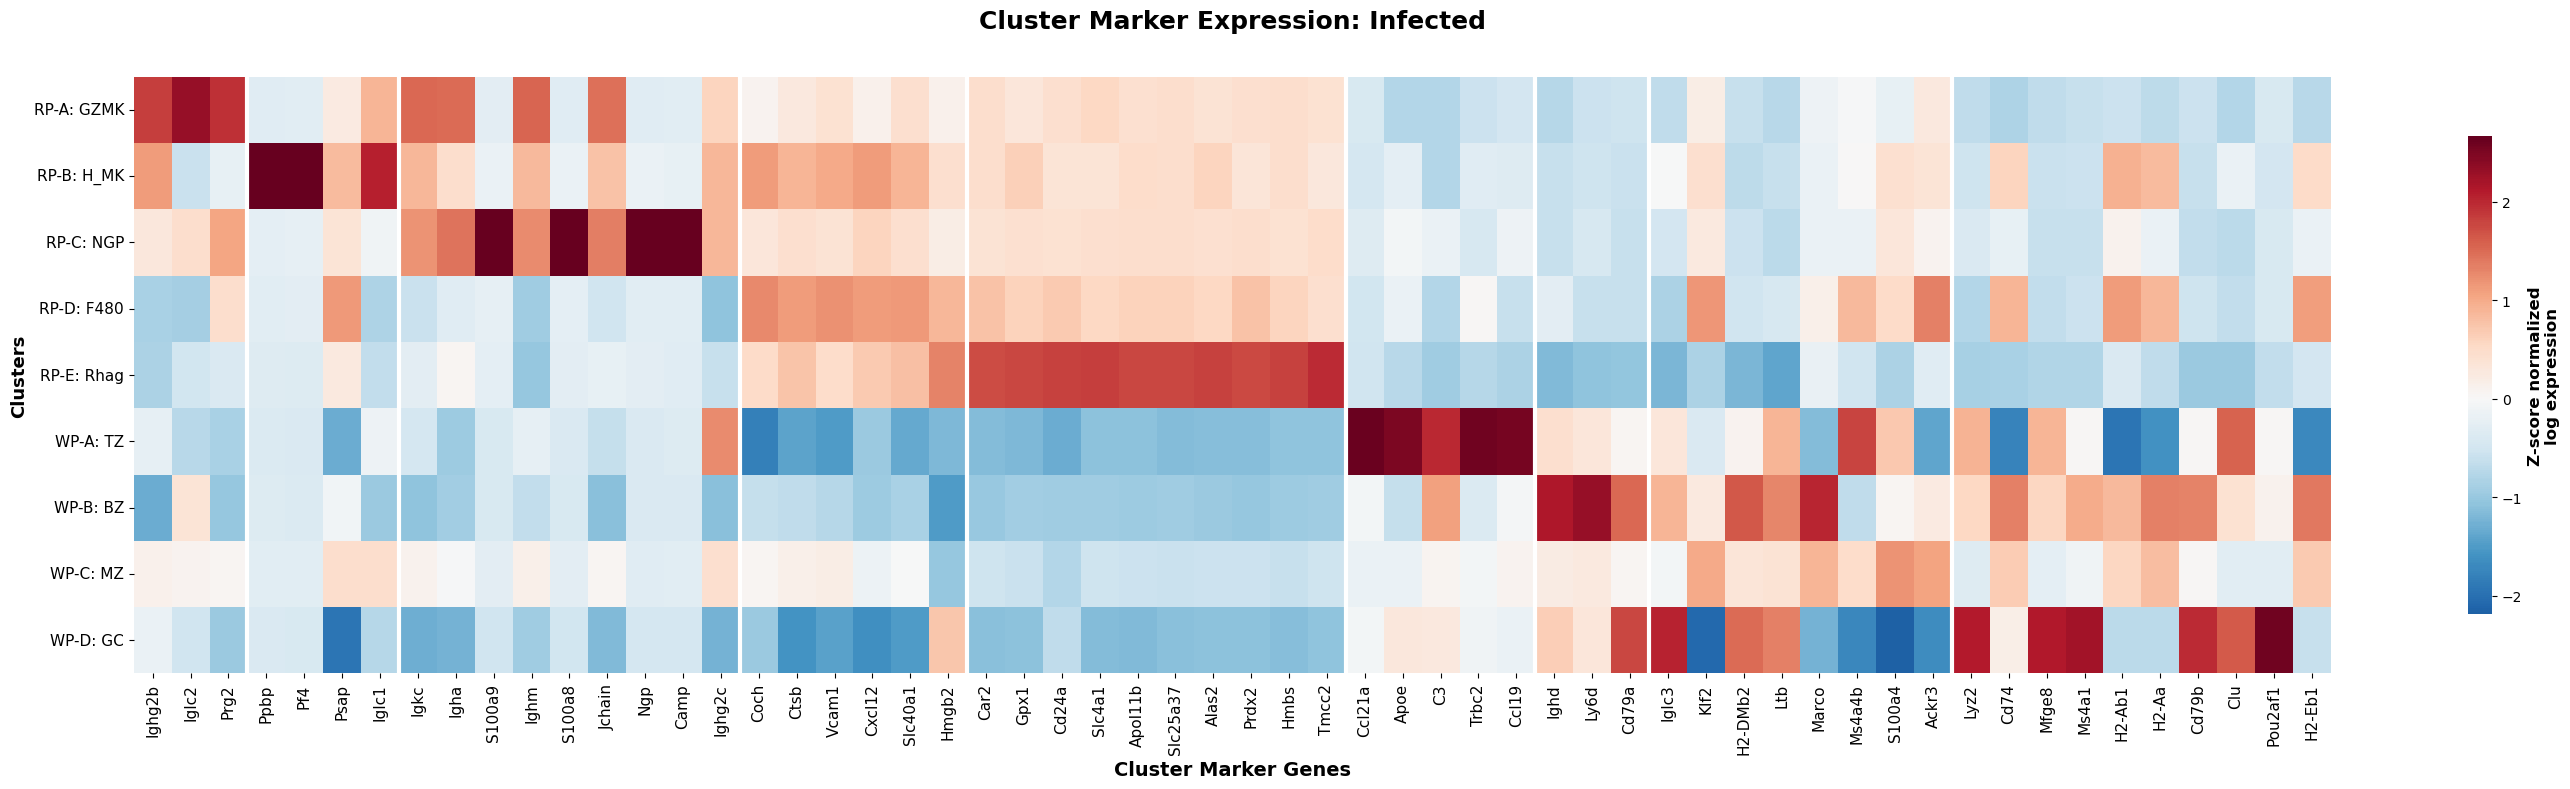

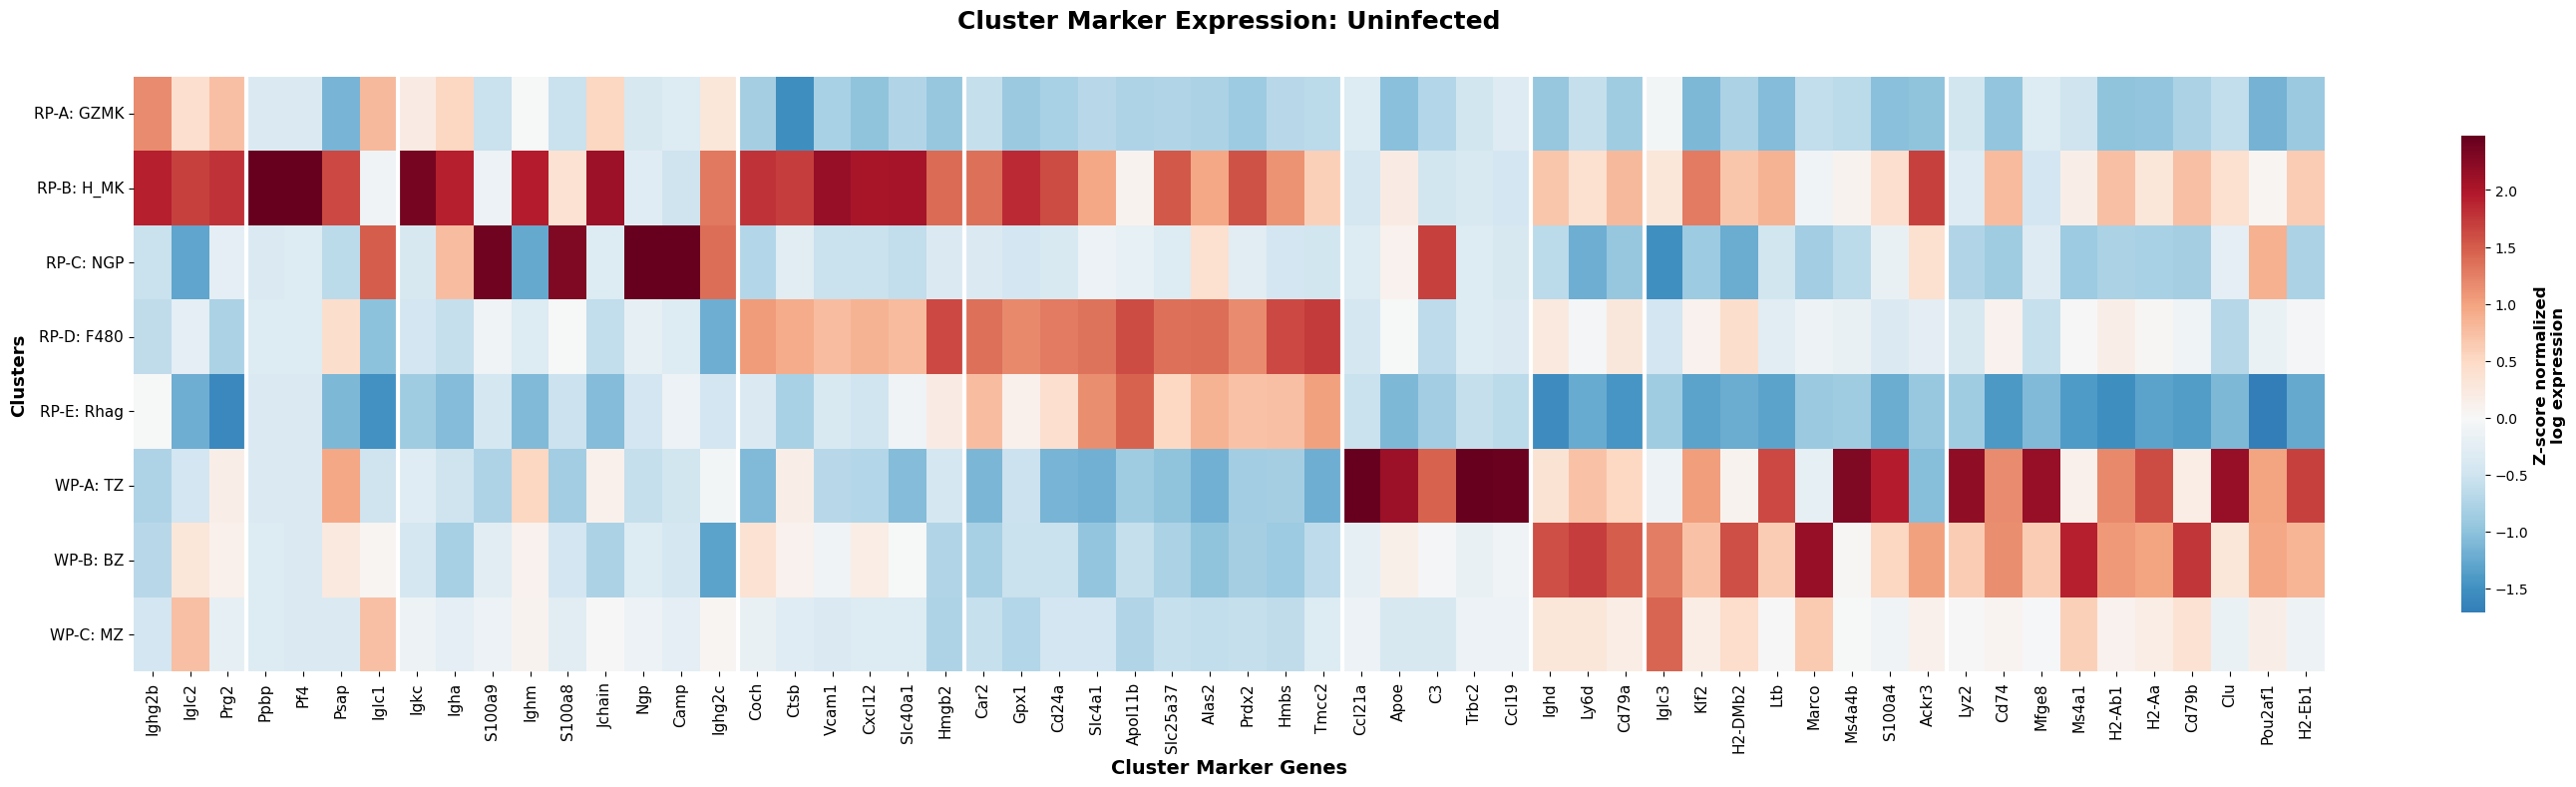

In [239]:

def create_separate_condition_summary_stats(heatmap_df, clusters, gene_to_cluster):
    """Create summary statistics for each condition separately"""
    print("\nCreating separate condition summary statistics...")
    
    # Split the data by condition
    infected_rows = [row for row in heatmap_df.index if '_Infected' in row]
    uninfected_rows = [row for row in heatmap_df.index if '_Uninfected' in row]
    
    infected_df = heatmap_df.loc[infected_rows].copy()
    uninfected_df = heatmap_df.loc[uninfected_rows].copy()
    
    # Clean up row names
    infected_df.index = [row.replace('_Infected', '') for row in infected_df.index]
    uninfected_df.index = [row.replace('_Uninfected', '') for row in uninfected_df.index]
    
    def create_condition_stats(data_df, condition_name):
        summary_stats = []
        
        for cluster in clusters:
            cluster_genes = [g for g in data_df.columns if gene_to_cluster.get(g) == cluster]
            
            if len(cluster_genes) == 0 or cluster not in data_df.index:
                continue
                
            cluster_data = data_df.loc[cluster, cluster_genes]
            
            summary_stats.append({
                'cluster': cluster,
                'condition': condition_name,
                'n_marker_genes': len(cluster_genes),
                'mean_expression': cluster_data.mean(),
                'median_expression': cluster_data.median(),
                'std_expression': cluster_data.std(),
                'min_expression': cluster_data.min(),
                'max_expression': cluster_data.max()
            })
        
        return pd.DataFrame(summary_stats)
    
    # Create stats for each condition
    infected_stats = create_condition_stats(infected_df, "Infected")
    uninfected_stats = create_condition_stats(uninfected_df, "Uninfected")
    
    # Combine and save
    combined_stats = pd.concat([infected_stats, uninfected_stats], ignore_index=True)
    combined_stats.to_csv("separate_conditions_summary_stats.csv", index=False)
    
    print("\nSeparate Condition Summary Statistics:")
    print("="*80)
    print(combined_stats.round(3).to_string(index=False))
    
    return combined_stats

def main_separate_conditions():
    """Main execution function for separate conditions"""
    print("="*80)
    print("SEPARATE CONDITIONS HEATMAP GENERATION")
    print("="*80)
    
    try:
        # Load data
        markers_df, conditions_df, adata_combined = load_results_and_data()
        
        # Prepare heatmap data (FDR significant genes only)
        heatmap_df, clusters, gene_to_cluster = prepare_heatmap_data(markers_df, conditions_df, adata_combined, top_n=10)
        
        # Create separate condition heatmaps
        infected_fig, uninfected_fig = create_separate_condition_heatmaps(heatmap_df, clusters, gene_to_cluster, top_n=10)
        
        # Create separate condition summary statistics
        summary_df = create_separate_condition_summary_stats(heatmap_df, clusters, gene_to_cluster)
        
        print("\n" + "="*80)
        print("ANALYSIS COMPLETE")
        print("="*80)
        print("Files created:")
        print("  - cluster_markers_infected_heatmap.png/pdf")
        print("  - cluster_markers_uninfected_heatmap.png/pdf")
        print("  - infected_conditions_expression_matrix.csv")
        print("  - uninfected_conditions_expression_matrix.csv")
        print("  - separate_conditions_summary_stats.csv")
        print("\nEach heatmap shows cluster marker genes normalized independently!")
        print("This allows direct comparison of marker expression patterns within each condition.")
        
    except Exception as e:
        print(f"❌ Error: {e}")
        print("Make sure to run cluster_marker_analysis_combined_conditions.py first")

# Run the separate conditions analysis
main_separate_conditions()

SEPARATE CONDITIONS HEATMAP GENERATION (WITH BACKFILL)
Loading analysis results and data...
Loaded 5691 marker genes across 9 clusters
Condition comparisons: 87 gene-cluster combinations
Preparing heatmap data with top 10 genes per cluster (FDR significant only)...
  RP-A: GZMK: 7 FDR significant genes, using top 7
  RP-B: H_MK: 1536 FDR significant genes, using top 10
  RP-C: NGP: 705 FDR significant genes, using top 10
  RP-D: F480: 768 FDR significant genes, using top 10
  RP-E: Rhag: 381 FDR significant genes, using top 10
  WP-A: TZ: 550 FDR significant genes, using top 10
  WP-B: BZ: 945 FDR significant genes, using top 10
  WP-C: MZ: 64 FDR significant genes, using top 10
  WP-D: GC: 735 FDR significant genes, using top 10
  Duplicate resolved: Igkc assigned to RP-C: NGP (|log2FC|=56.78), removed from RP-A: GZMK
  Duplicate resolved: Igkc assigned to RP-C: NGP (|log2FC|=136.69), removed from RP-B: H_MK
  Duplicate resolved: Ighm assigned to RP-C: NGP (|log2FC|=16.75), removed fr

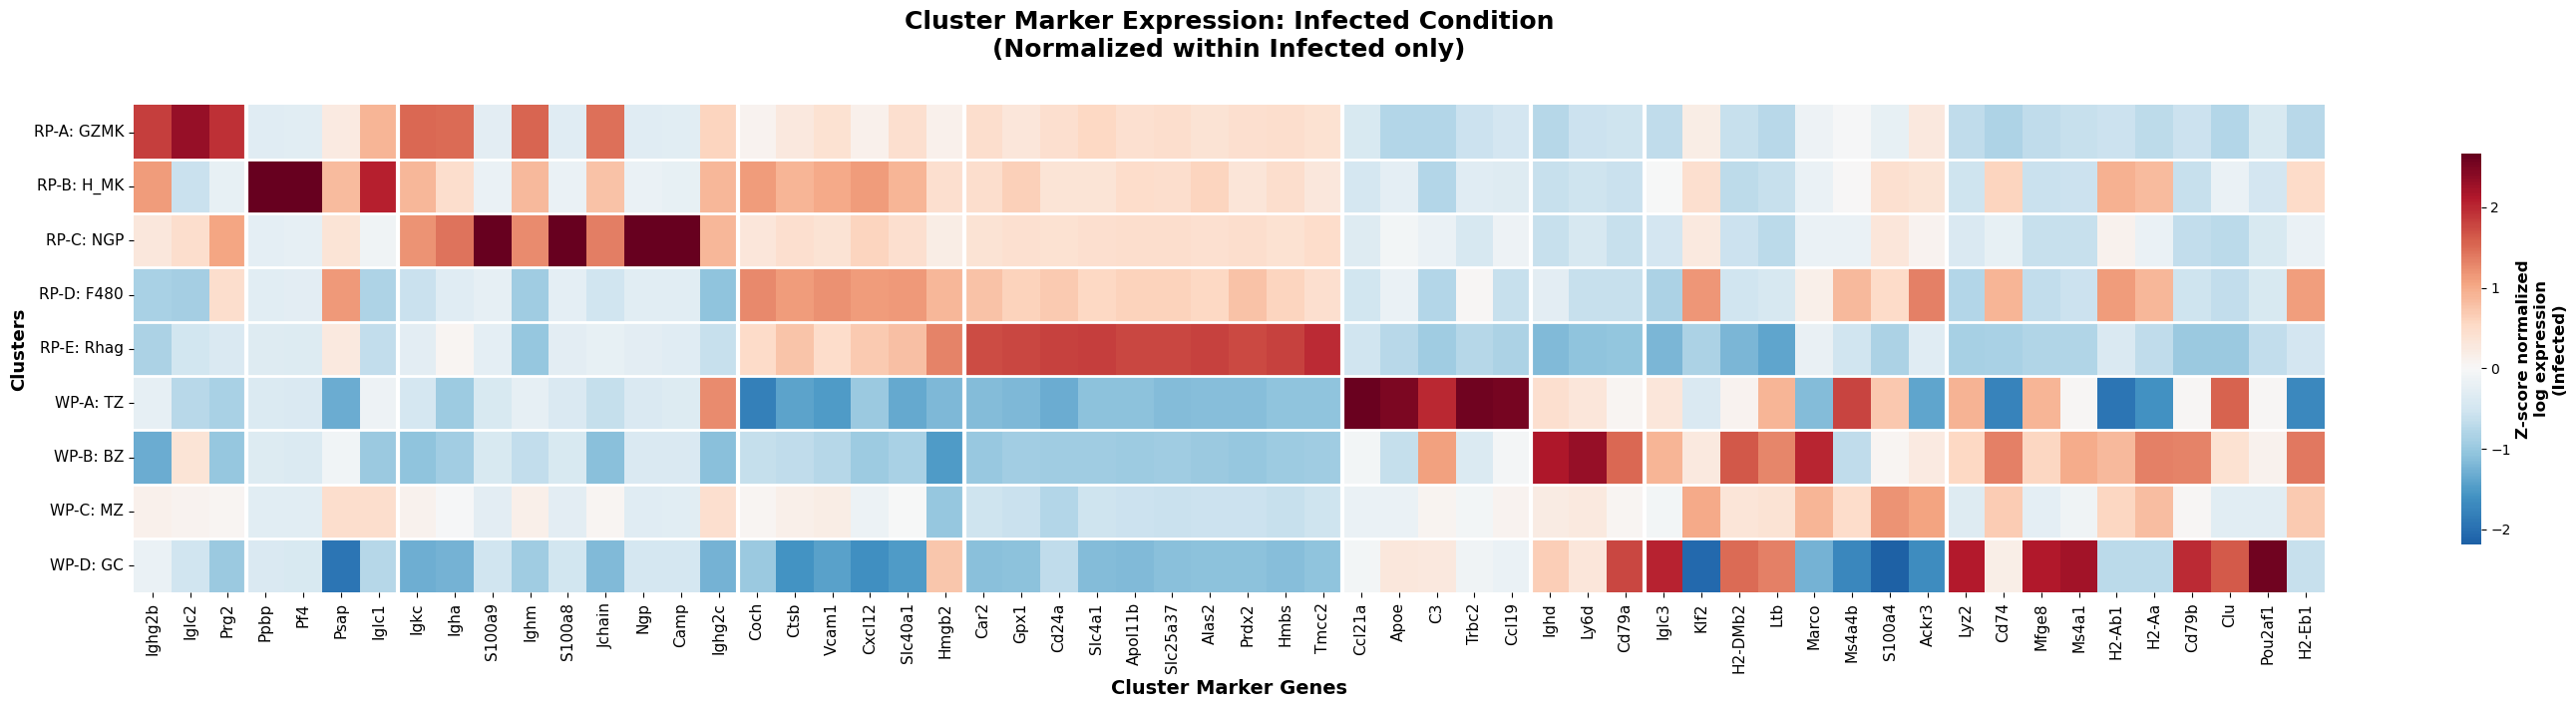

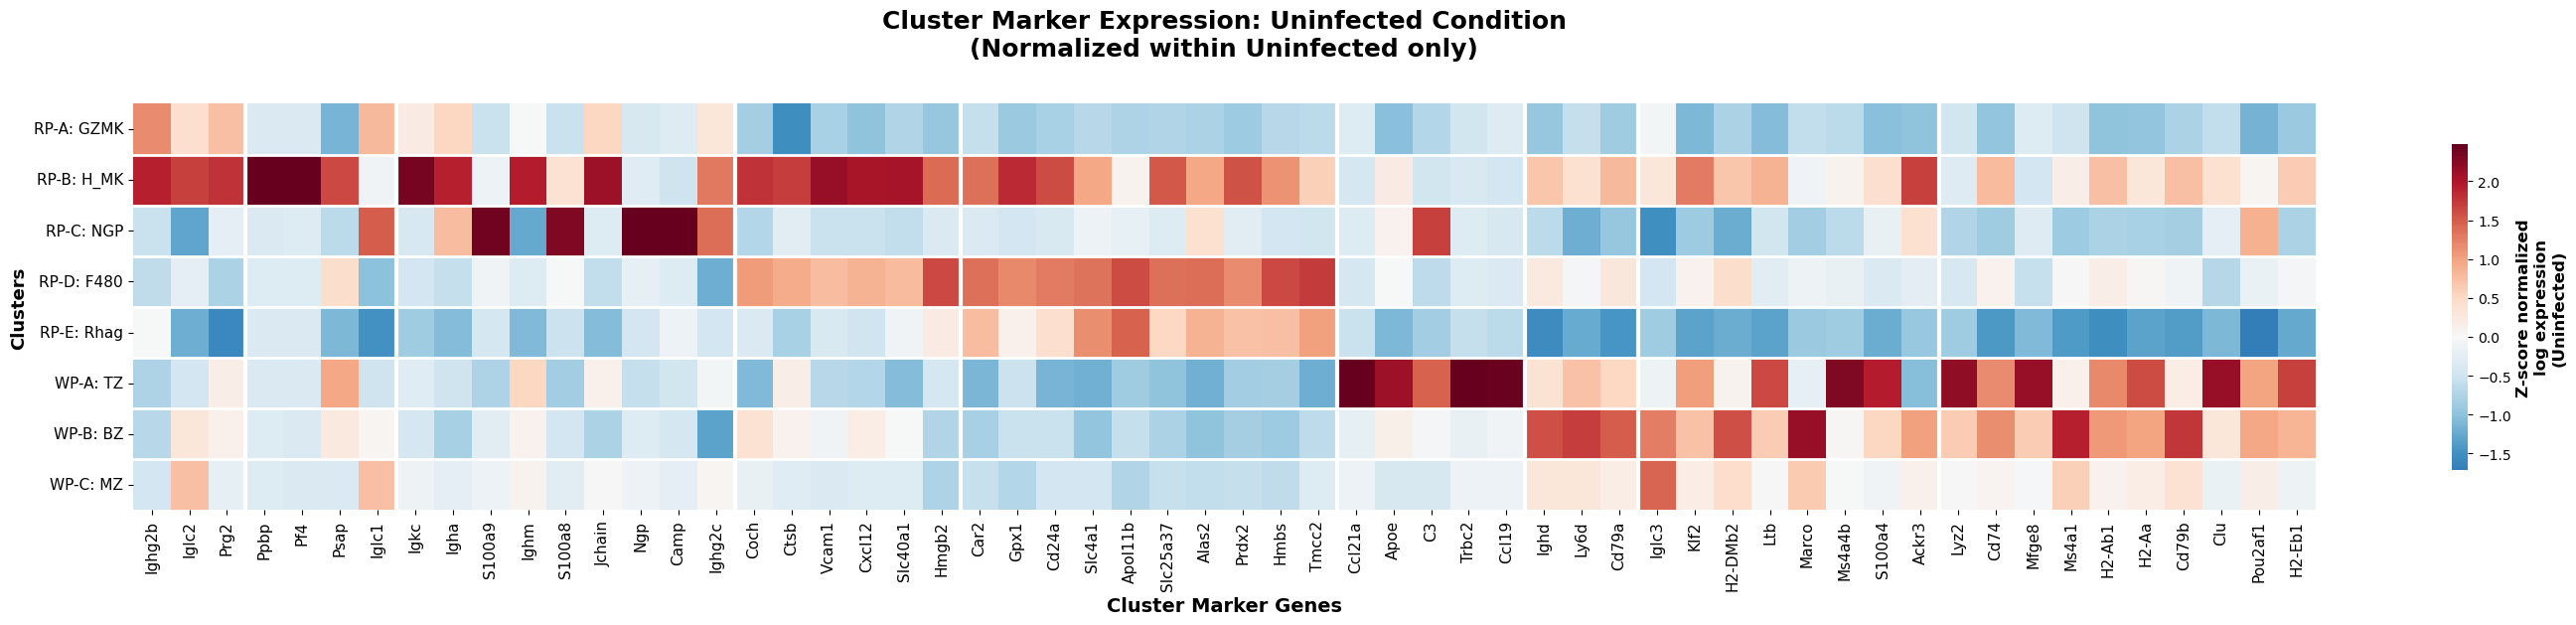

In [240]:
def create_separate_condition_heatmaps(heatmap_df, clusters, gene_to_cluster, top_n=10):
    """Create separate heatmaps for infected and uninfected conditions"""
    print("Creating separate condition heatmaps...")
    
    # Split the data by condition
    infected_rows = [row for row in heatmap_df.index if '_Infected' in row]
    uninfected_rows = [row for row in heatmap_df.index if '_Uninfected' in row]
    
    infected_df = heatmap_df.loc[infected_rows].copy() if infected_rows else pd.DataFrame()
    uninfected_df = heatmap_df.loc[uninfected_rows].copy() if uninfected_rows else pd.DataFrame()
    
    # Clean up row names
    if not infected_df.empty:
        infected_df.index = [row.replace('_Infected', '') for row in infected_df.index]
    if not uninfected_df.empty:
        uninfected_df.index = [row.replace('_Uninfected', '') for row in uninfected_df.index]
    
    def create_condition_heatmap(data_df, condition_name, clusters, gene_to_cluster):
        """Create heatmap for a single condition"""
        if data_df.empty:
            print(f"No data for {condition_name} condition")
            return None
            
        # Z-score normalize WITHIN this condition only
        heatmap_zscore = data_df.apply(lambda x: (x - x.mean()) / x.std(), axis=0)
        heatmap_zscore = heatmap_zscore.fillna(0)
        
        # Set up the plot
        n_genes = len(data_df.columns)
        n_clusters = len(data_df.index)
        
        # Dynamic figure size
        fig_width = max(20, n_genes * 0.5)
        fig_height = max(6, n_clusters * 0.8)
        
        fig, ax = plt.subplots(figsize=(fig_width, fig_height))
        
        # Calculate actual data range for proper colorbar scaling
        data_min = heatmap_zscore.min().min()
        data_max = heatmap_zscore.max().max()
        
        # Create heatmap
        sns.heatmap(
            heatmap_zscore,
            cmap='RdBu_r',
            center=0,
            vmin=data_min,
            vmax=data_max,
            cbar_kws={
                'label': f'Z-score normalized\nlog expression\n({condition_name})', 
                'shrink': 0.8,
                'pad': 0.05,
                'aspect': 20,
            },
            xticklabels=True,
            yticklabels=True,
            ax=ax
        )
        
        # Customize x-axis labels (genes)
        ax.set_xticklabels(data_df.columns, rotation=90, ha='center', fontsize=11)
        
        # Customize y-axis labels (clusters)
        ax.set_yticklabels(data_df.index, fontsize=11)
        
        # Add gene cluster separators (vertical lines between gene groups)
        gene_count = 0
        for cluster in clusters:
            cluster_genes = [g for g in data_df.columns if gene_to_cluster.get(g) == cluster]
            if len(cluster_genes) > 0:
                gene_count += len(cluster_genes)
                # Add vertical line to separate gene clusters
                if gene_count < len(data_df.columns):
                    ax.axvline(x=gene_count, color='white', linewidth=3)
        
        # Add horizontal lines to separate clusters (if multiple)
        if len(data_df.index) > 1:
            for i in range(1, len(data_df.index)):
                ax.axhline(y=i, color='white', linewidth=2)
        
        # Improve colorbar
        cbar = ax.collections[0].colorbar
        cbar.set_label(f'Z-score normalized\nlog expression\n({condition_name})', 
                      fontsize=12, weight='bold')
        
        # Title and labels
        ax.set_title(f'Cluster Marker Expression: {condition_name} Condition\n(Normalized within {condition_name} only)',
                    fontsize=18, weight='bold', pad=35)
        ax.set_xlabel('Cluster Marker Genes', fontsize=14, weight='bold')
        ax.set_ylabel('Clusters', fontsize=13, weight='bold')
        
        # Adjust layout
        plt.tight_layout()
        
        # Save plots
        output_prefix = f"cluster_markers_{condition_name.lower()}_heatmap"
        plt.savefig(f"{output_prefix}.png", dpi=300, bbox_inches='tight', facecolor='white')
        plt.savefig(f"{output_prefix}.pdf", bbox_inches='tight', facecolor='white')
        
        print(f"✅ {condition_name} heatmap saved as {output_prefix}.png and .pdf")
        
        # Save expression matrix
        data_df.to_csv(f"{condition_name.lower()}_conditions_expression_matrix.csv")
        print(f"✅ {condition_name} expression matrix saved")
        
        return fig
    
    # Create heatmaps for each condition
    infected_fig = create_condition_heatmap(infected_df, "Infected", clusters, gene_to_cluster)
    uninfected_fig = create_condition_heatmap(uninfected_df, "Uninfected", clusters, gene_to_cluster)
    
    return infected_fig, uninfected_fig

def create_separate_condition_summary_stats(heatmap_df, clusters, gene_to_cluster):
    """Create summary statistics for each condition separately"""
    print("\nCreating separate condition summary statistics...")
    
    # Split the data by condition
    infected_rows = [row for row in heatmap_df.index if '_Infected' in row]
    uninfected_rows = [row for row in heatmap_df.index if '_Uninfected' in row]
    
    infected_df = heatmap_df.loc[infected_rows].copy() if infected_rows else pd.DataFrame()
    uninfected_df = heatmap_df.loc[uninfected_rows].copy() if uninfected_rows else pd.DataFrame()
    
    # Clean up row names
    if not infected_df.empty:
        infected_df.index = [row.replace('_Infected', '') for row in infected_df.index]
    if not uninfected_df.empty:
        uninfected_df.index = [row.replace('_Uninfected', '') for row in uninfected_df.index]
    
    def create_condition_stats(data_df, condition_name):
        summary_stats = []
        
        for cluster in clusters:
            cluster_genes = [g for g in data_df.columns if gene_to_cluster.get(g) == cluster]
            
            if len(cluster_genes) == 0 or cluster not in data_df.index:
                continue
                
            cluster_data = data_df.loc[cluster, cluster_genes]
            
            summary_stats.append({
                'cluster': cluster,
                'condition': condition_name,
                'n_marker_genes': len(cluster_genes),
                'mean_expression': cluster_data.mean(),
                'median_expression': cluster_data.median(),
                'std_expression': cluster_data.std(),
                'min_expression': cluster_data.min(),
                'max_expression': cluster_data.max()
            })
        
        return pd.DataFrame(summary_stats)
    
    # Create stats for each condition
    stats_list = []
    if not infected_df.empty:
        infected_stats = create_condition_stats(infected_df, "Infected")
        stats_list.append(infected_stats)
    
    if not uninfected_df.empty:
        uninfected_stats = create_condition_stats(uninfected_df, "Uninfected")
        stats_list.append(uninfected_stats)
    
    # Combine and save
    if stats_list:
        combined_stats = pd.concat(stats_list, ignore_index=True)
        combined_stats.to_csv("separate_conditions_summary_stats.csv", index=False)
        
        print("\nSeparate Condition Summary Statistics:")
        print("="*80)
        print(combined_stats.round(3).to_string(index=False))
        
        return combined_stats
    else:
        print("No valid data for statistics")
        return pd.DataFrame()

def main_separate_conditions_with_backfill():
    """Main execution function for separate conditions with backfill"""
    print("="*80)
    print("SEPARATE CONDITIONS HEATMAP GENERATION (WITH BACKFILL)")
    print("="*80)
    
    try:
        # Load data
        markers_df, conditions_df, adata_combined = load_results_and_data()
        
        # Prepare heatmap data with backfill (FDR significant genes only)
        heatmap_df, clusters, gene_to_cluster = prepare_heatmap_data(markers_df, conditions_df, adata_combined, top_n=10)
        
        # Create separate condition heatmaps
        infected_fig, uninfected_fig = create_separate_condition_heatmaps(heatmap_df, clusters, gene_to_cluster, top_n=10)
        
        # Create separate condition summary statistics
        summary_df = create_separate_condition_summary_stats(heatmap_df, clusters, gene_to_cluster)
        
        print("\n" + "="*80)
        print("ANALYSIS COMPLETE")
        print("="*80)
        print("Files created:")
        print("  - cluster_markers_infected_heatmap.png/pdf")
        print("  - cluster_markers_uninfected_heatmap.png/pdf")
        print("  - infected_conditions_expression_matrix.csv")
        print("  - uninfected_conditions_expression_matrix.csv")
        print("  - separate_conditions_summary_stats.csv")
        print("\nEach heatmap shows cluster marker genes normalized independently!")
        print("This allows direct comparison of marker expression patterns within each condition.")
        print("Backfill ensures each cluster has up to 10 genes even after duplicate removal.")
        
    except Exception as e:
        print(f"❌ Error: {e}")
        print("Make sure to run cluster_marker_analysis_combined_conditions.py first")

# Run the separate conditions analysis with backfill
main_separate_conditions_with_backfill()

HEATMAP WITH FORCED GENE INCLUSION
Loading analysis results and data...
Loaded 5691 marker genes across 9 clusters
Condition comparisons: 87 gene-cluster combinations
Preparing heatmap data with top 10 genes per cluster
Filtering for genes with BOTH higher fold change AND higher normalized expression in cluster...
Force-including specific genes for certain clusters:
  WP-C: MZ: ['Marco', 'Psap', 'Gm2a', 'Irf1']
  RP-A: GZMK: ['Igha', 'Igkc', 'Jchain', 'Iglc2']
  WP-B: BZ: ['Bank1', 'Cr2', 'H2-DMb2', 'Cd74', 'Cd19', 'Ly6d', 'Cd22', 'Ms4a2', 'Cd79b']
Calculating normalized expression across all clusters...
Filtering markers by expression criteria...
  RP-A: GZMK: 7 -> 1 genes after expression filtering
  RP-B: H_MK: 1536 -> 956 genes after expression filtering
  RP-C: NGP: 705 -> 136 genes after expression filtering
  RP-D: F480: 768 -> 40 genes after expression filtering
  RP-E: Rhag: 381 -> 134 genes after expression filtering
  WP-A: TZ: 550 -> 237 genes after expression filtering
  W

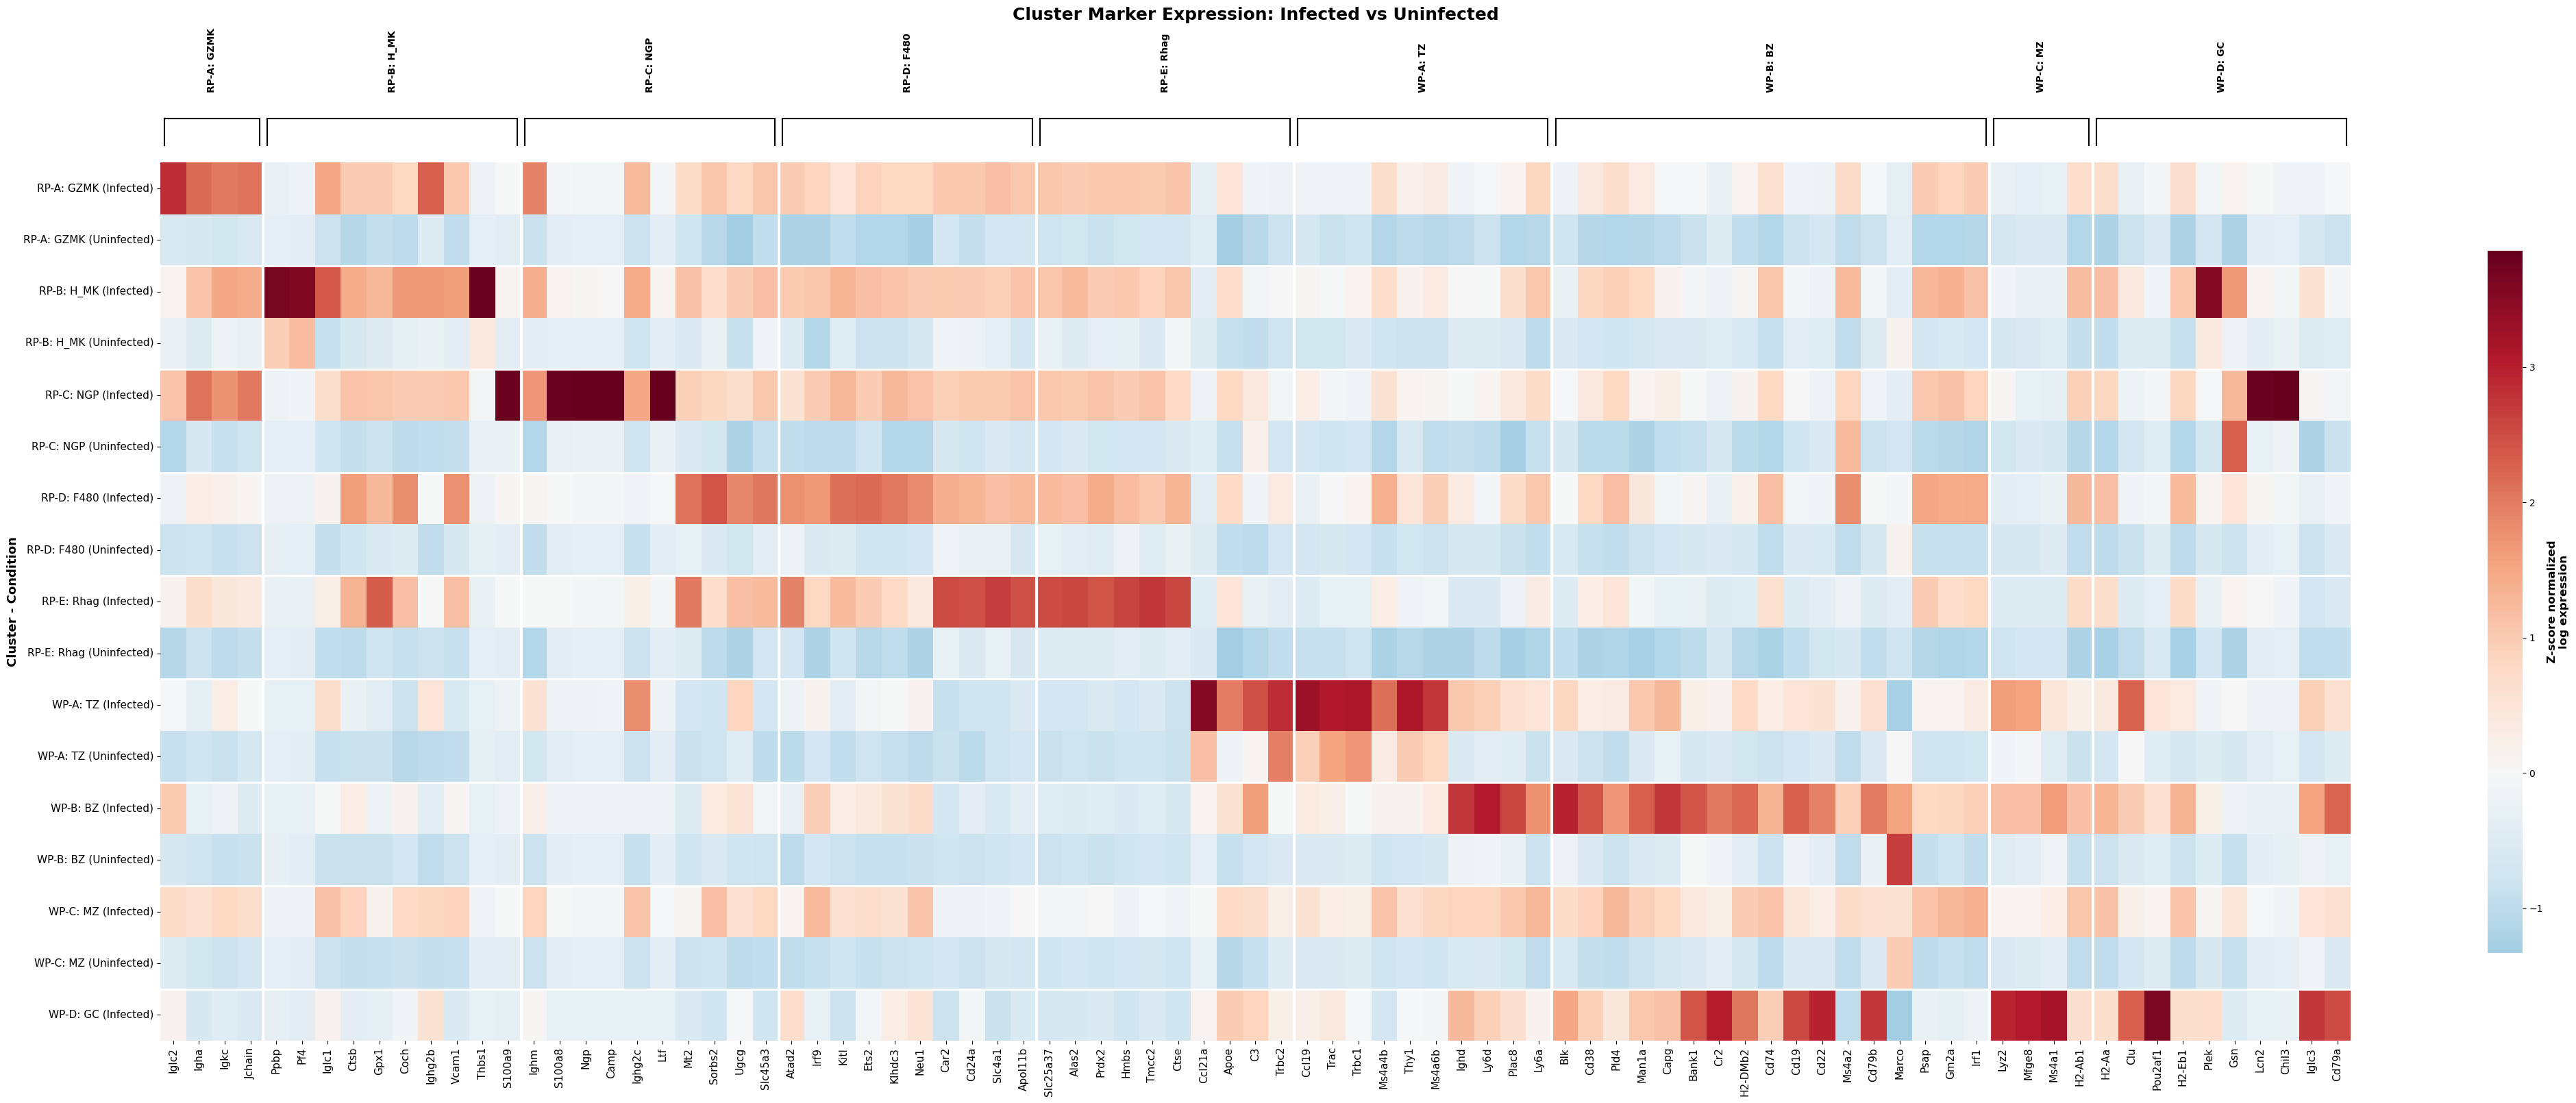

In [241]:
def prepare_heatmap_data_with_forced_genes(markers_df, conditions_df, adata_combined, top_n=10, force_include_genes=None):
    """Prepare data matrix for heatmap with backfill, expression filtering, and forced gene inclusion"""
    print(f"Preparing heatmap data with top {top_n} genes per cluster")
    print("Filtering for genes with BOTH higher fold change AND higher normalized expression in cluster...")
    
    if force_include_genes:
        print("Force-including specific genes for certain clusters:")
        for cluster, genes in force_include_genes.items():
            print(f"  {cluster}: {genes}")
    
    # Get clusters in order
    clusters = sorted(markers_df['cluster'].unique())
    
    # Calculate normalized expression for all genes across all clusters (same as before)
    print("Calculating normalized expression across all clusters...")
    
    cluster_expression = {}
    for cluster in clusters:
        cluster_mask = adata_combined.obs['paper_clusters'] == cluster
        cluster_spots = np.where(cluster_mask)[0]
        
        if len(cluster_spots) > 0:
            if hasattr(adata_combined.X, 'toarray'):
                cluster_expr = adata_combined.X[cluster_spots].toarray()
            else:
                cluster_expr = adata_combined.X[cluster_spots]
            
            cluster_mean_expr = np.mean(cluster_expr, axis=0)
            cluster_expression[cluster] = cluster_mean_expr
        else:
            cluster_expression[cluster] = np.zeros(adata_combined.n_vars)
    
    def gene_has_highest_expression_in_cluster(gene, assigned_cluster):
        if gene not in adata_combined.var_names:
            return False
            
        gene_idx = list(adata_combined.var_names).index(gene)
        gene_expr_by_cluster = {cluster: cluster_expression[cluster][gene_idx] 
                               for cluster in clusters}
        max_cluster = max(gene_expr_by_cluster, key=gene_expr_by_cluster.get)
        return max_cluster == assigned_cluster
    
    # Step 1: Filter markers by expression criteria (same as before)
    print("Filtering markers by expression criteria...")
    expression_filtered_markers = []
    
    for cluster in clusters:
        cluster_markers = markers_df[markers_df['cluster'] == cluster].copy()
        
        valid_genes = []
        for _, row in cluster_markers.iterrows():
            gene = row['gene']
            if gene_has_highest_expression_in_cluster(gene, cluster):
                valid_genes.append(row)
        
        if valid_genes:
            cluster_filtered_df = pd.DataFrame(valid_genes)
            expression_filtered_markers.append(cluster_filtered_df)
            print(f"  {cluster}: {len(cluster_markers)} -> {len(valid_genes)} genes after expression filtering")
        else:
            print(f"  {cluster}: {len(cluster_markers)} -> 0 genes after expression filtering")
    
    # Combine filtered markers
    if expression_filtered_markers:
        filtered_markers_df = pd.concat(expression_filtered_markers, ignore_index=True)
    else:
        filtered_markers_df = pd.DataFrame()
    
    # Step 2: Add forced genes to the filtered markers
    if force_include_genes:
        print("\nAdding forced genes to filtered markers...")
        forced_gene_rows = []
        
        for cluster, forced_genes in force_include_genes.items():
            for gene in forced_genes:
                # Check if gene exists in the data
                if gene in adata_combined.var_names:
                    # Check if this gene is already in the filtered markers for this cluster
                    existing_gene = filtered_markers_df[
                        (filtered_markers_df['cluster'] == cluster) & 
                        (filtered_markers_df['gene'] == gene)
                    ]
                    
                    if existing_gene.empty:
                        # Gene not in filtered markers, check if it's in original markers
                        original_gene = markers_df[
                            (markers_df['cluster'] == cluster) & 
                            (markers_df['gene'] == gene)
                        ]
                        
                        if not original_gene.empty:
                            # Use original marker data, but convert to dict
                            forced_gene_rows.append(original_gene.iloc[0].to_dict())
                            print(f"  Added {gene} to {cluster} from original markers")
                        else:
                            # Create a dummy entry with reasonable values
                            gene_idx = list(adata_combined.var_names).index(gene)
                            cluster_expr = cluster_expression[cluster][gene_idx]
                            
                            dummy_row = {
                                'gene': gene,
                                'cluster': cluster,
                                'log2_fold_change': 1.0,  # Dummy value
                                'pval': 0.01,  # Dummy value
                                'pval_adj': 0.01,  # Dummy value
                                'mean_expression': cluster_expr
                            }
                            forced_gene_rows.append(dummy_row)
                            print(f"  Added {gene} to {cluster} as forced gene (not in original markers)")
                    else:
                        print(f"  {gene} already in {cluster} filtered markers")
                else:
                    print(f"  ⚠️ {gene} not found in dataset for {cluster}")
        
        # Add forced genes to filtered markers
        if forced_gene_rows:
            forced_df = pd.DataFrame(forced_gene_rows)
            filtered_markers_df = pd.concat([filtered_markers_df, forced_df], ignore_index=True)
            print(f"Added {len(forced_gene_rows)} forced genes to filtered markers")
    
    if filtered_markers_df.empty:
        print("❌ No genes found after filtering and forced inclusion!")
        return pd.DataFrame(), clusters, {}
    
    print(f"Total genes after expression filtering + forced inclusion: {len(filtered_markers_df)}")
    
    # Step 3: Apply backfill logic with priority for forced genes
    cluster_initial_genes = {}
    all_gene_cluster_info = {}
    
    for cluster in clusters:
        cluster_markers = filtered_markers_df[filtered_markers_df['cluster'] == cluster].copy()
        
        # Separate forced genes from regular genes
        forced_genes_for_cluster = []
        regular_genes_for_cluster = []
        
        if force_include_genes and cluster in force_include_genes:
            forced_genes_for_cluster = [g for g in force_include_genes[cluster] if g in adata_combined.var_names]
        
        # First, ensure all forced genes are included
        genes_added = 0
        cluster_initial_genes[cluster] = []
        
        for _, row in cluster_markers.iterrows():
            gene = row['gene']
            log2_fc = row['log2_fold_change']
            abs_log2_fc = abs(log2_fc)
            
            # Always include forced genes first
            if gene in forced_genes_for_cluster:
                cluster_initial_genes[cluster].append(gene)
                genes_added += 1
                print(f"  {cluster}: included forced gene {gene}")
            elif genes_added < top_n:
                cluster_initial_genes[cluster].append(gene)
                genes_added += 1
            
            # Track for duplicate resolution
            if gene not in all_gene_cluster_info:
                all_gene_cluster_info[gene] = []
            all_gene_cluster_info[gene].append((cluster, abs_log2_fc, log2_fc))
        
        print(f"  {cluster}: selected {len(cluster_initial_genes[cluster])} genes (including forced)")
    
    # Step 4: Resolve duplicates but protect forced genes
    # Step 4: Resolve duplicates but protect forced genes
    gene_final_assignment = {}
    clusters_lost_genes = {}

    for gene, cluster_info_list in all_gene_cluster_info.items():
        if len(cluster_info_list) > 1:
            # Check if this gene is forced for any cluster that has it
            forced_assignment = None
            if force_include_genes:
                for cluster, forced_genes in force_include_genes.items():
                    if gene in forced_genes:
                        # Check if this cluster is one of the clusters that has this gene
                        cluster_has_gene = any(c[0] == cluster for c in cluster_info_list)
                        if cluster_has_gene:
                            forced_assignment = cluster
                            print(f"  Duplicate resolved: {gene} PROTECTED in {forced_assignment} (forced gene)")
                            break
            
            if forced_assignment:
                # Assign to the cluster that forced this gene - NO FOLD CHANGE COMPARISON
                gene_final_assignment[gene] = forced_assignment
            else:
                # Normal duplicate resolution ONLY for non-forced genes
                best_cluster = max(cluster_info_list, key=lambda x: x[1])[0]
                gene_final_assignment[gene] = best_cluster
                print(f"  Duplicate resolved: {gene} assigned to {best_cluster} (highest fold change)")
            
            # Track losses for all other clusters
            for cluster, abs_log2_fc, log2_fc in cluster_info_list:
                if cluster != gene_final_assignment[gene]:
                    if cluster not in clusters_lost_genes:
                        clusters_lost_genes[cluster] = []
                    clusters_lost_genes[cluster].append(gene)
        else:
            # Gene only appears in one cluster - no conflict
            gene_final_assignment[gene] = cluster_info_list[0][0]
    
    # Step 5: Build final gene list
    unique_genes = []
    gene_to_cluster = {}
    cluster_final_genes = {}
    
    for cluster in clusters:
        cluster_final_genes[cluster] = []
        
        for gene in cluster_initial_genes[cluster]:
            if gene_final_assignment[gene] == cluster:
                cluster_final_genes[cluster].append(gene)
                unique_genes.append(gene)
                gene_to_cluster[gene] = cluster
    
    # Step 6: Backfill (same as before, but won't override forced genes)
    print(f"\nStarting backfill process...")
    already_assigned_genes = set(unique_genes)
    
    for cluster in clusters:
        lost_genes = clusters_lost_genes.get(cluster, [])
        current_count = len(cluster_final_genes[cluster])
        needed_genes = top_n - current_count
        
        if needed_genes > 0:
            print(f"  {cluster}: has {current_count} genes, needs {needed_genes} more")
            
            full_cluster_markers = filtered_markers_df[filtered_markers_df['cluster'] == cluster].copy()
            
            backfill_genes = []
            for _, row in full_cluster_markers.iterrows():
                gene = row['gene']
                if gene not in already_assigned_genes and len(backfill_genes) < needed_genes:
                    backfill_genes.append(gene)
                    print(f"    Backfill: adding {gene}")
            
            cluster_final_genes[cluster].extend(backfill_genes)
            unique_genes.extend(backfill_genes)
            
            for gene in backfill_genes:
                gene_to_cluster[gene] = cluster
                already_assigned_genes.add(gene)
            
            print(f"    {cluster}: backfilled with {len(backfill_genes)} genes, now has {len(cluster_final_genes[cluster])} total")
    
    # Show final summary
    print(f"\nFinal Summary:")
    print(f"Total unique genes for heatmap: {len(unique_genes)}")
    
    for cluster in clusters:
        cluster_gene_count = len(cluster_final_genes[cluster])
        forced_count = 0
        if force_include_genes and cluster in force_include_genes:
            forced_count = len([g for g in cluster_final_genes[cluster] 
                               if g in force_include_genes[cluster]])
        print(f"  {cluster}: {cluster_gene_count} genes ({forced_count} forced)")
    
    # Rest of the function for creating expression matrix (same as before)
    cluster_counts = adata_combined.obs.groupby(['condition', 'paper_clusters']).size().unstack(fill_value=0)
    
    heatmap_rows = []
    for cluster in clusters:
        infected_count = cluster_counts.loc['infected', cluster] if cluster in cluster_counts.columns else 0
        uninfected_count = cluster_counts.loc['uninfected', cluster] if cluster in cluster_counts.columns else 0
        
        if infected_count > 0:
            heatmap_rows.append(f"{cluster}_Infected")
        if uninfected_count > 0:
            heatmap_rows.append(f"{cluster}_Uninfected")
    
    expression_matrix = np.zeros((len(heatmap_rows), len(unique_genes)))
    
    if hasattr(adata_combined.X, 'toarray'):
        expr_data = adata_combined.X.toarray()
    else:
        expr_data = adata_combined.X
    
    for gene_idx, gene in enumerate(unique_genes):
        if gene not in adata_combined.var_names:
            continue
            
        gene_adata_idx = list(adata_combined.var_names).index(gene)
        
        for row_idx, row_name in enumerate(heatmap_rows):
            if '_Infected' in row_name:
                cluster = row_name.replace('_Infected', '')
                condition = 'infected'
            elif '_Uninfected' in row_name:
                cluster = row_name.replace('_Uninfected', '')
                condition = 'uninfected'
            else:
                continue
            
            cluster_mask = adata_combined.obs['paper_clusters'] == cluster
            condition_mask = adata_combined.obs['condition'] == condition
            spots = cluster_mask & condition_mask
            
            if np.sum(spots) > 0:
                expr = expr_data[spots, gene_adata_idx]
                mean_expr = np.mean(expr)
            else:
                mean_expr = 0
            
            expression_matrix[row_idx, gene_idx] = mean_expr
    
    heatmap_df = pd.DataFrame(
        expression_matrix,
        index=heatmap_rows,
        columns=unique_genes
    )
    
    return heatmap_df, clusters, gene_to_cluster


def create_heatmap(heatmap_df, clusters, gene_to_cluster, top_n=10):
    """Create the expression heatmap with brackets above gene groups"""
    print("Creating heatmap...")
    
    # Z-score normalize for visualization (column-wise, i.e., per gene)
    heatmap_zscore = heatmap_df.apply(lambda x: (x - x.mean()) / x.std(), axis=0)
    
    # Replace NaN with 0 (for genes with no variance)
    heatmap_zscore = heatmap_zscore.fillna(0)
    
    # Set up the plot
    n_genes = len(heatmap_df.columns)  # genes are columns now
    n_clusters = len(clusters)
    
    # Dynamic figure size - genes on x-axis, clusters on y-axis
    fig_width = max(20, n_genes * 0.5)  # 0.5 inch per gene
    fig_height = max(8, n_clusters * 2)  # 2 inches per cluster (infected + uninfected)
    
    fig, ax = plt.subplots(figsize=(fig_width, fig_height))
    
    # Calculate actual data range for proper colorbar scaling
    data_min = heatmap_zscore.min().min()
    data_max = heatmap_zscore.max().max()
    
    # Create heatmap with improved colorbar positioning and proper scale
    sns.heatmap(
        heatmap_zscore,
        cmap='RdBu_r',
        center=0,
        vmin=data_min,
        vmax=data_max,
        cbar_kws={
            'label': 'Z-score normalized\nlog expression', 
            'shrink': 0.8,
            'pad': 0.05,  # More padding for tick labels
            'aspect': 20,  # Make colorbar wider to fit labels
        },
        xticklabels=True,
        yticklabels=True,
        ax=ax
    )
    
    # Customize x-axis labels (genes) - make them bigger
    ax.set_xticklabels(heatmap_df.columns, rotation=90, ha='center', fontsize=11)
    
    # Customize y-axis labels (cluster-conditions)
    y_labels = []
    for row_name in heatmap_df.index:
        # Clean up cluster-condition names
        if '_Infected' in row_name:
            cluster_name = row_name.replace('_Infected', '')
            y_labels.append(f"{cluster_name} (Infected)")
        elif '_Uninfected' in row_name:
            cluster_name = row_name.replace('_Uninfected', '')
            y_labels.append(f"{cluster_name} (Uninfected)")
        else:
            y_labels.append(row_name)
    
    ax.set_yticklabels(y_labels, fontsize=11)
    
    # Prepare cluster boundaries and labels for brackets
    cluster_boundaries = []
    cluster_labels = []
    gene_count = 0
    
    for cluster in clusters:
        cluster_genes = [g for g in heatmap_df.columns if gene_to_cluster.get(g) == cluster]
        if len(cluster_genes) > 0:
            gene_start = gene_count
            gene_count += len(cluster_genes)
            gene_end = gene_count
            
            # Store boundary information for brackets
            cluster_boundaries.append((gene_start, gene_end))
            cluster_labels.append(cluster)
            
            # Add vertical line to separate gene clusters
            if gene_end < len(heatmap_df.columns):
                ax.axvline(x=gene_end, color='white', linewidth=3)
    
    # Add horizontal lines to separate clusters
    cluster_boundaries_y = []
    current_pos = 0
    
    for cluster in clusters:
        # Count how many rows this cluster has
        cluster_rows = sum(1 for row in heatmap_df.index if row.startswith(cluster))
        current_pos += cluster_rows
        if current_pos < len(heatmap_df.index):
            cluster_boundaries_y.append(current_pos)
    
    # Draw horizontal lines between cluster groups
    for boundary in cluster_boundaries_y:
        ax.axhline(y=boundary, color='white', linewidth=2)
    
    # ADD BRACKETS AND LABELS ABOVE GENE GROUPS
    plt.subplots_adjust(top=0.8)  # Make room for brackets
    ax.set_ylim(len(heatmap_df.index), 0)  # Ensure proper y-axis limits
    
    # Get transform for placing brackets
    trans = ax.get_xaxis_transform()
    
    for i, (label, (start, end)) in enumerate(zip(cluster_labels, cluster_boundaries)):
        # Create bracket lines
        # Horizontal line
        ax.plot([start + 0.15, end - 0.15], [1.05, 1.05], color='black', lw=1.5, transform=trans, clip_on=False)
        # Left stem
        ax.plot([start + 0.15, start + 0.15], [1.02, 1.05], color='black', lw=1.5, transform=trans, clip_on=False)
        # Right stem
        ax.plot([end - 0.15, end - 0.15], [1.02, 1.05], color='black', lw=1.5, transform=trans, clip_on=False)
        
        # Add cluster label above bracket
        mid_point = (start + end) / 2
        plt.text(mid_point, 1.08, label, 
                 ha='center', va='bottom', rotation=90, fontsize=10, fontweight='bold',
                 transform=trans, clip_on=False)
    
    # Improve colorbar label
    cbar = ax.collections[0].colorbar
    cbar.set_label('Z-score normalized\nlog expression', fontsize=12, weight='bold')
    
    # Title and labels - improved for publication quality with more padding for brackets
    ax.set_title('Cluster Marker Expression: Infected vs Uninfected',
                fontsize=18, weight='bold', pad=150)  # Increased pad for brackets
    ax.set_xlabel('')  # Remove x-label since genes are now labeled above with brackets
    ax.set_ylabel('Cluster - Condition', fontsize=13, weight='bold')
    
    # Adjust layout to accommodate brackets
    plt.tight_layout(rect=[0, 0, 1, 0.9])
    
    # Save plots
    output_prefix = "combined_conditions_heatmap"
    plt.savefig(f"{output_prefix}.png", dpi=300, bbox_inches='tight', facecolor='white')
    plt.savefig(f"{output_prefix}.pdf", bbox_inches='tight', facecolor='white')
    
    print(f"✅ Heatmap saved as {output_prefix}.png and .pdf")
    
    return fig

def main_with_forced_genes():
    """Main execution function with forced gene inclusion"""
    print("="*80)
    print("HEATMAP WITH FORCED GENE INCLUSION")
    print("="*80)
    
    # Define forced genes for specific clusters - CORRECTED CLUSTER NAMES
    force_include_genes = {
        'WP-C: MZ': ['Marco', 'Psap', 'Gm2a', 'Irf1'],
        'RP-A: GZMK': ['Igha', 'Igkc', 'Jchain', 'Iglc2'],
        'WP-B: BZ': ['Bank1', 'Cr2', 'H2-DMb2', 'Cd74', 'Cd19', 'Ly6d', 'Cd22', 'Ms4a2', 'Cd79b']
    }
    
    try:
        # Load data
        markers_df, conditions_df, adata_combined = load_results_and_data()
        
        # Prepare heatmap data with forced genes
        heatmap_df, clusters, gene_to_cluster = prepare_heatmap_data_with_forced_genes(
            markers_df, conditions_df, adata_combined, top_n=10, 
            force_include_genes=force_include_genes
        )
        
        if heatmap_df.empty:
            print("❌ No valid genes found. Exiting.")
            return
        
        # Create the combined heatmap
        fig = create_heatmap(heatmap_df, clusters, gene_to_cluster, top_n=10)
        
        # Create summary statistics
        summary_df = create_summary_stats(heatmap_df, clusters, gene_to_cluster)
        
        # Save expression matrix
        heatmap_df.to_csv("forced_genes_expression_matrix.csv")
        
        print("\n" + "="*80)
        print("ANALYSIS COMPLETE")
        print("="*80)
        print("Files created:")
        print("  - combined_conditions_heatmap.png/pdf")
        print("  - forced_genes_expression_matrix.csv")
        print("  - combined_conditions_summary_stats.csv")
        print("\nForced genes included regardless of filtering criteria!")
        
    except Exception as e:
        print(f"❌ Error: {e}")
        import traceback
        traceback.print_exc()

# Run the analysis with forced genes
main_with_forced_genes()

MANUAL GENE LIST HEATMAP - GLOBAL NORMALIZATION
Loading data...

Processing manual gene lists:
  WP-C: MZ: 4 genes
    ✅ 4 genes found: ['Marco', 'Psap', 'Gm2a', 'Irf1']
  RP-A: GZMK: 4 genes
    ✅ 4 genes found: ['Igha', 'Igkc', 'Jchain', 'Iglc2']
  WP-B: BZ: 12 genes
    ✅ 12 genes found: ['Bank1', 'Cr2', 'H2-DMb2', 'Cd74', 'Cd19', 'Ly6d', 'Cd22', 'Ms4a2', 'Cd79b', 'Blk', 'Cd38', 'Capg']
  RP-B: H_MK: 9 genes
    ✅ 9 genes found: ['Ppbp', 'Pf4', 'Iglc1', 'Ctsb', 'Gpx1', 'Coch', 'Ighg2b', 'Vcam1', 'Thbs1']
  RP-C: NGP: 5 genes
    ✅ 5 genes found: ['S100a9', 'S100a8', 'Ngp', 'Camp', 'Ltf']
  RP-D: F480: 10 genes
    ✅ 10 genes found: ['Mt2', 'Sorbs2', 'Ugcg', 'Slc45a3', 'Atad2', 'Irf9', 'Kitl', 'Ets2', 'Klhdc3', 'Neu1']
  RP-E: Rhag: 10 genes
    ✅ 10 genes found: ['Car2', 'Cd24a', 'Slc4a1', 'Apol11b', 'Slc25a37', 'Alas2', 'Prdx2', 'Hmbs', 'Tmcc2', 'Ctse']
  WP-A: TZ: 10 genes
    ✅ 10 genes found: ['Ccl21a', 'Apoe', 'C3', 'Trbc2', 'Ccl19', 'Trac', 'Trbc1', 'Ms4a4b', 'Thy1', 'Ms4a6b']

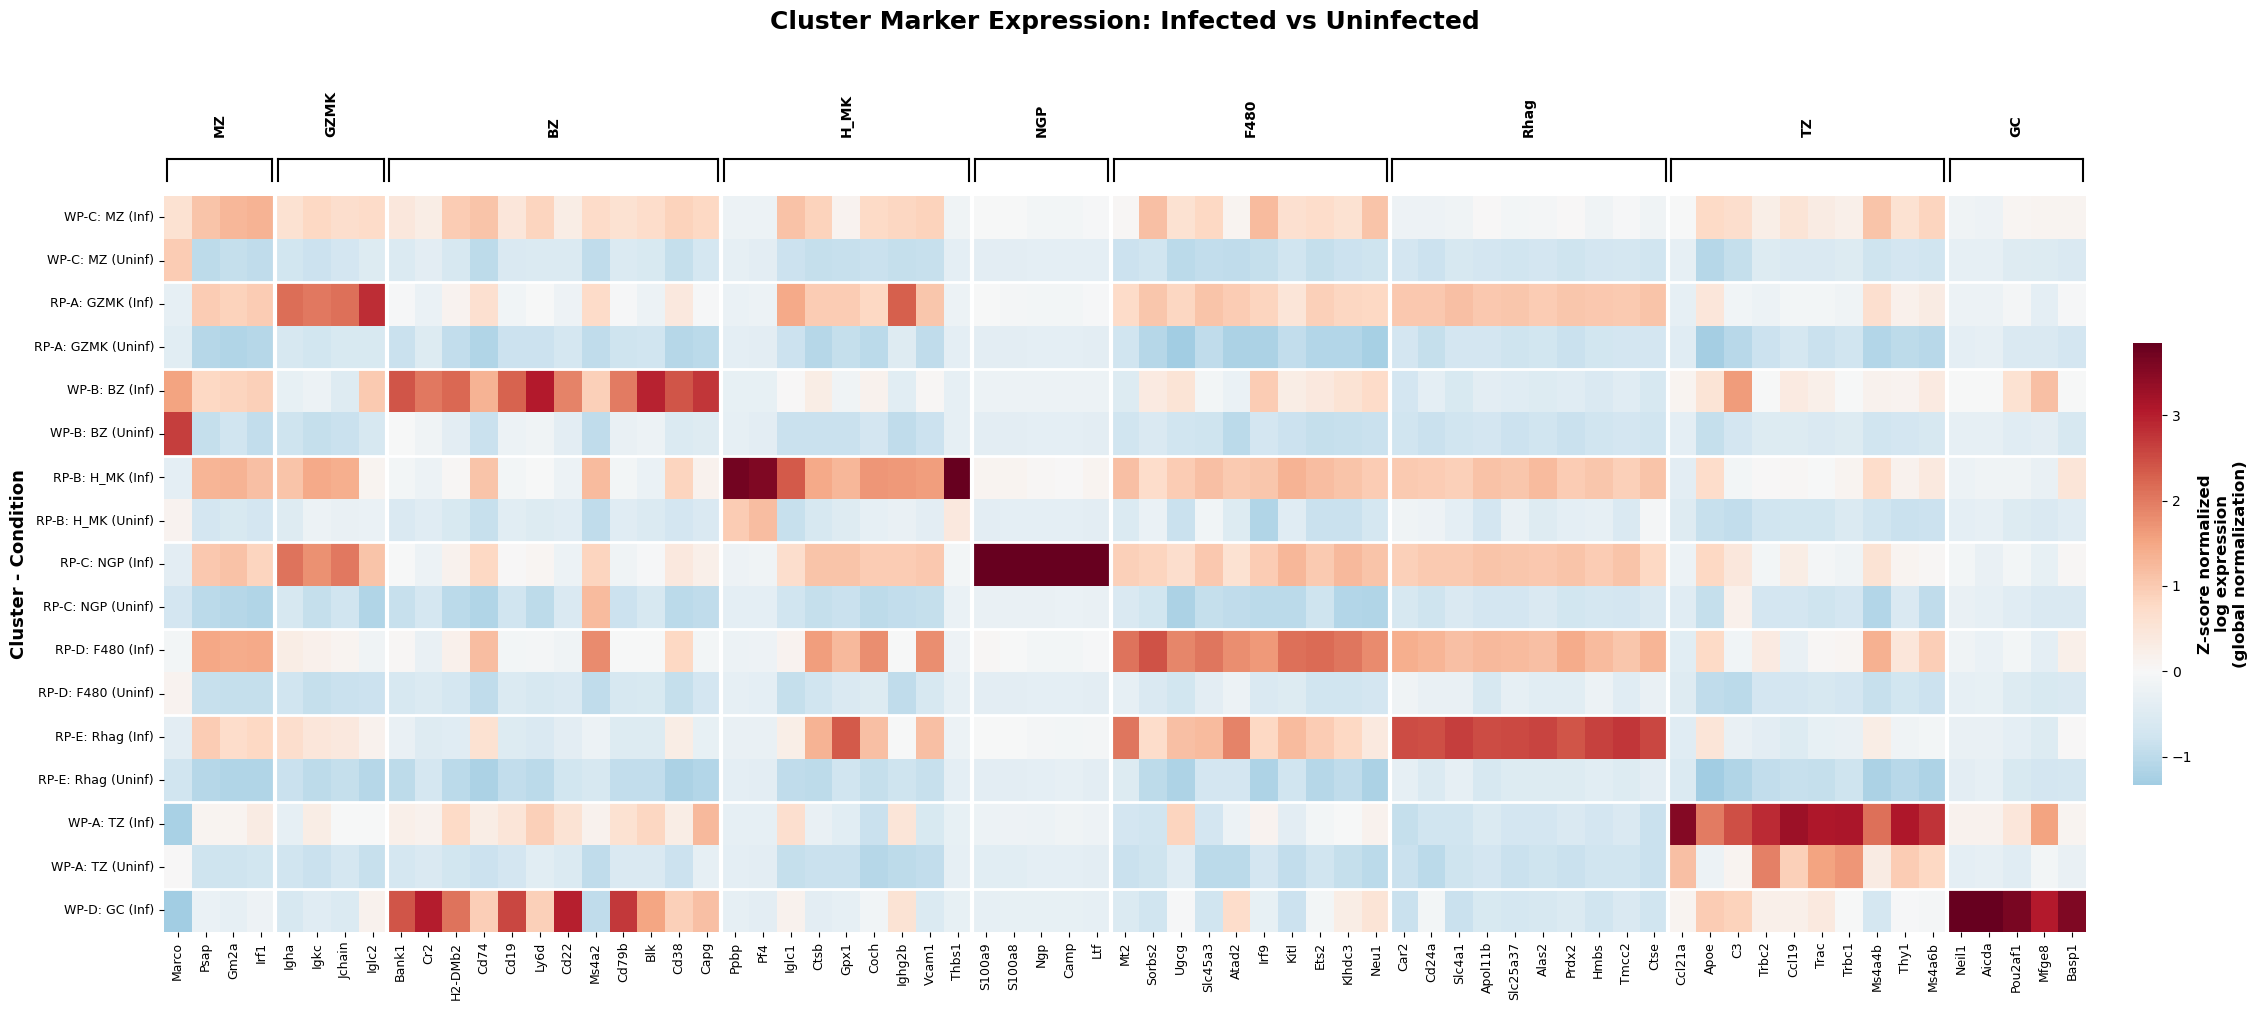

In [242]:
#!/usr/bin/env python3
"""
Manual Gene List Heatmap with Global Normalization

Create heatmap with manually specified genes per cluster, 
alternating infected/uninfected rows, global Z-score normalization.
"""

import numpy as np
import pandas as pd
import scanpy as sc
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

def create_manual_gene_heatmap():
    """
    Create heatmap with manually specified gene lists
    """
    print("="*80)
    print("MANUAL GENE LIST HEATMAP - GLOBAL NORMALIZATION")
    print("="*80)
    
    # Define your manual gene lists (correcting potential typos)
    manual_gene_lists = {
        'WP-C: MZ': ['Marco', 'Psap', 'Gm2a', 'Irf1'],
        'RP-A: GZMK': ['Igha', 'Igkc', 'Jchain', 'Iglc2'],
        'WP-B: BZ': ['Bank1', 'Cr2', 'H2-DMb2', 'Cd74', 'Cd19', 'Ly6d', 'Cd22', 'Ms4a2', 'Cd79b', 'Blk', 'Cd38', 'Capg'],
        'RP-B: H_MK': ['Ppbp', 'Pf4', 'Iglc1', 'Ctsb', 'Gpx1', 'Coch', 'Ighg2b', 'Vcam1', 'Thbs1'],
        'RP-C: NGP': ['S100a9', 'S100a8', 'Ngp', 'Camp', 'Ltf'],
        'RP-D: F480': ['Mt2', 'Sorbs2', 'Ugcg', 'Slc45a3', 'Atad2', 'Irf9', 'Kitl', 'Ets2', 'Klhdc3', 'Neu1'],
        'RP-E: Rhag': ['Car2', 'Cd24a', 'Slc4a1', 'Apol11b', 'Slc25a37', 'Alas2', 'Prdx2', 'Hmbs', 'Tmcc2', 'Ctse'],
        'WP-A: TZ': ['Ccl21a', 'Apoe', 'C3', 'Trbc2', 'Ccl19', 'Trac', 'Trbc1', 'Ms4a4b', 'Thy1', 'Ms4a6b'],
        'WP-D: GC': ['Neil1', 'Aicda', 'Pou2af1', 'Mfge8', 'Basp1']
    }
    
    try:
        # Load data
        print("Loading data...")
        adata_infected = sc.read_h5ad('/Users/yashkulkarni/cellxgene_data/cell2location_infected_030525_yk.h5ad')
        adata_uninfected = sc.read_h5ad('/Users/yashkulkarni/cellxgene_data/cell2location_uninfected_030525_yk.h5ad')
        
        # Combine data
        adata_combined = adata_infected.concatenate(adata_uninfected, batch_key='condition', 
                                                   batch_categories=['infected', 'uninfected'])
        
        # Create gene list and cluster mapping
        all_genes = []
        gene_to_cluster = {}
        clusters = list(manual_gene_lists.keys())
        
        print("\nProcessing manual gene lists:")
        for cluster, genes in manual_gene_lists.items():
            print(f"  {cluster}: {len(genes)} genes")
            
            # Check which genes exist in the data
            existing_genes = []
            for gene in genes:
                if gene in adata_combined.var_names:
                    existing_genes.append(gene)
                    all_genes.append(gene)
                    gene_to_cluster[gene] = cluster
                else:
                    print(f"    ⚠️  {gene} not found in dataset")
            
            print(f"    ✅ {len(existing_genes)} genes found: {existing_genes}")
        
        print(f"\nTotal genes for heatmap: {len(all_genes)}")
        
        # Create alternating rows: cluster_infected, cluster_uninfected
        # But skip rows that don't exist
        heatmap_rows = []
        for cluster in clusters:
            # Check if cluster exists in each condition
            cluster_infected_exists = np.sum((adata_combined.obs['paper_clusters'] == cluster) & 
                                           (adata_combined.obs['condition'] == 'infected')) > 0
            cluster_uninfected_exists = np.sum((adata_combined.obs['paper_clusters'] == cluster) & 
                                             (adata_combined.obs['condition'] == 'uninfected')) > 0
            
            if cluster_infected_exists:
                heatmap_rows.append(f"{cluster}_Infected")
            if cluster_uninfected_exists:
                heatmap_rows.append(f"{cluster}_Uninfected")
        
        print(f"Heatmap rows: {len(heatmap_rows)}")
        for row in heatmap_rows:
            print(f"  {row}")
        
        # Create expression matrix
        expression_matrix = np.zeros((len(heatmap_rows), len(all_genes)))
        
        # Extract expression data
        if hasattr(adata_combined.X, 'toarray'):
            expr_data = adata_combined.X.toarray()
        else:
            expr_data = adata_combined.X
        
        print("\nExtracting expression values...")
        for gene_idx, gene in enumerate(all_genes):
            if gene not in adata_combined.var_names:
                continue
                
            gene_adata_idx = list(adata_combined.var_names).index(gene)
            
            for row_idx, row_name in enumerate(heatmap_rows):
                # Parse cluster and condition from row name
                if '_Infected' in row_name:
                    cluster = row_name.replace('_Infected', '')
                    condition = 'infected'
                elif '_Uninfected' in row_name:
                    cluster = row_name.replace('_Uninfected', '')
                    condition = 'uninfected'
                else:
                    continue
                
                # Get spots for this cluster-condition combination
                cluster_mask = adata_combined.obs['paper_clusters'] == cluster
                condition_mask = adata_combined.obs['condition'] == condition
                spots = cluster_mask & condition_mask
                
                if np.sum(spots) > 0:
                    expr = expr_data[spots, gene_adata_idx]
                    mean_expr = np.mean(expr)
                else:
                    mean_expr = 0
                
                expression_matrix[row_idx, gene_idx] = mean_expr
        
        # Create DataFrame
        heatmap_df = pd.DataFrame(
            expression_matrix,
            index=heatmap_rows,
            columns=all_genes
        )
        
        # Global Z-score normalization (across ALL samples)
        print("Applying global Z-score normalization...")
        heatmap_zscore = heatmap_df.apply(lambda x: (x - x.mean()) / x.std(), axis=0)
        heatmap_zscore = heatmap_zscore.fillna(0)
        
        # Create visualization
        n_genes = len(all_genes)
        n_clusters = len(clusters)
        
        fig_width = max(25, n_genes * 0.3)
        fig_height = max(12, len(heatmap_rows) * 0.4)
        
        fig, ax = plt.subplots(figsize=(fig_width, fig_height))
        
        # Calculate data range
        data_min = heatmap_zscore.min().min()
        data_max = heatmap_zscore.max().max()
        
        print(f"Z-score range: {data_min:.2f} to {data_max:.2f}")
        
        # Create heatmap
        sns.heatmap(
            heatmap_zscore,
            cmap='RdBu_r',
            center=0,
            vmin=data_min,
            vmax=data_max,
            cbar_kws={
                'label': 'Z-score normalized\nlog expression\n(global normalization)', 
                'shrink': 0.6,
                'pad': 0.02,
                'aspect': 15,
            },
            xticklabels=True,
            yticklabels=True,
            ax=ax
        )
        
        # Customize labels
        ax.set_xticklabels(all_genes, rotation=90, ha='center', fontsize=9)
        
        # Clean y-axis labels
        y_labels = []
        for row_name in heatmap_rows:
            if '_Infected' in row_name:
                cluster_name = row_name.replace('_Infected', '')
                y_labels.append(f"{cluster_name} (Inf)")
            elif '_Uninfected' in row_name:
                cluster_name = row_name.replace('_Uninfected', '')
                y_labels.append(f"{cluster_name} (Uninf)")
            else:
                y_labels.append(row_name)
        
        ax.set_yticklabels(y_labels, fontsize=9)
        
        # Add cluster boundaries and brackets
        gene_count = 0
        cluster_boundaries = []
        cluster_labels = []
        
        for cluster in clusters:
            cluster_genes = [g for g in all_genes if gene_to_cluster.get(g) == cluster]
            if len(cluster_genes) > 0:
                gene_start = gene_count
                gene_count += len(cluster_genes)
                gene_end = gene_count
                
                cluster_boundaries.append((gene_start, gene_end))
                cluster_labels.append(cluster.split(': ')[-1])  # Use short name (MZ, TZ, etc.)
                
                # Add vertical separator
                if gene_end < len(all_genes):
                    ax.axvline(x=gene_end, color='white', linewidth=3)
        
        # Add horizontal lines between clusters (accounting for missing rows)
        current_cluster = None
        for i, row_name in enumerate(heatmap_rows):
            if '_Infected' in row_name:
                row_cluster = row_name.replace('_Infected', '')
            else:
                row_cluster = row_name.replace('_Uninfected', '')
            
            if current_cluster is not None and row_cluster != current_cluster:
                ax.axhline(y=i, color='white', linewidth=2)
            
            current_cluster = row_cluster
        
        # Add brackets above gene groups
        plt.subplots_adjust(top=0.8)
        trans = ax.get_xaxis_transform()
        
        for i, (label, (start, end)) in enumerate(zip(cluster_labels, cluster_boundaries)):
            # Bracket lines
            ax.plot([start + 0.1, end - 0.1], [1.05, 1.05], color='black', lw=1.5, transform=trans, clip_on=False)
            ax.plot([start + 0.1, start + 0.1], [1.02, 1.05], color='black', lw=1.5, transform=trans, clip_on=False)
            ax.plot([end - 0.1, end - 0.1], [1.02, 1.05], color='black', lw=1.5, transform=trans, clip_on=False)
            
            # Cluster label
            mid_point = (start + end) / 2
            plt.text(mid_point, 1.08, label, 
                     ha='center', va='bottom', rotation=90, fontsize=10, fontweight='bold',
                     transform=trans, clip_on=False)
        
        # Title and labels
        ax.set_title('Cluster Marker Expression: Infected vs Uninfected',
                    fontsize=18, weight='bold', pad=120)
        ax.set_ylabel('Cluster - Condition', fontsize=13, weight='bold')
        
        # Colorbar
        cbar = ax.collections[0].colorbar
        cbar.set_label('Z-score normalized\nlog expression\n(global normalization)', 
                      fontsize=12, weight='bold')
        
        plt.tight_layout(rect=[0, 0, 1, 0.85])
        
        # Save plots
        output_prefix = "manual_curated_markers_heatmap"
        plt.savefig(f"{output_prefix}.png", dpi=300, bbox_inches='tight', facecolor='white')
        plt.savefig(f"{output_prefix}.pdf", bbox_inches='tight', facecolor='white')
        
        print(f"\n✅ Heatmap saved as {output_prefix}.png and .pdf")
        
        # Save data
        heatmap_df.to_csv("manual_curated_expression_matrix.csv")
        
        # Create gene list summary
        gene_summary = []
        for cluster, genes in manual_gene_lists.items():
            for gene in genes:
                gene_summary.append({
                    'cluster': cluster,
                    'gene': gene,
                    'found_in_data': gene in adata_combined.var_names
                })
        
        gene_summary_df = pd.DataFrame(gene_summary)
        gene_summary_df.to_csv("manual_gene_list_summary.csv", index=False)
        
        print("\n" + "="*80)
        print("ANALYSIS COMPLETE")
        print("="*80)
        print("Files created:")
        print("  - manual_curated_markers_heatmap.png/pdf")
        print("  - manual_curated_expression_matrix.csv")
        print("  - manual_gene_list_summary.csv")
        print("\nThis heatmap shows:")
        print("  • Your manually curated gene lists per cluster")
        print("  • Alternating infected/uninfected rows per cluster")
        print("  • Global Z-score normalization across all samples")
        print("  • Biologically meaningful gene-cluster assignments")
        
        return fig, heatmap_df
        
    except Exception as e:
        print(f"❌ Error: {e}")
        import traceback
        traceback.print_exc()

# Run the manual gene list heatmap
fig, data = create_manual_gene_heatmap()

COMPACT SEPARATE CONDITION HEATMAPS
Loading data...

CREATING INFECTED HEATMAP
Checking cluster existence:
  ✅ TZ (WP-A: TZ): 74 spots - INCLUDED
  ✅ BZ (WP-B: BZ): 219 spots - INCLUDED
  ✅ MZ (WP-C: MZ): 242 spots - INCLUDED
  ✅ 2nd Fol (WP-D: GC): 33 spots - INCLUDED
  ✅ RP-A-PC (RP-A: GZMK): 194 spots - INCLUDED
  ✅ RP-B-MK (RP-B: H_MK): 75 spots - INCLUDED
  ✅ RP-C-Neut (RP-C: NGP): 90 spots - INCLUDED
  ✅ RP-D (RP-D: F480): 119 spots - INCLUDED
  ✅ RP-E-RBC (RP-E: Rhag): 222 spots - INCLUDED

🎯 FINAL CLUSTERS FOR INFECTED: 9
  1. TZ (WP-A: TZ)
  2. BZ (WP-B: BZ)
  3. MZ (WP-C: MZ)
  4. 2nd Fol (WP-D: GC)
  5. RP-A-PC (RP-A: GZMK)
  6. RP-B-MK (RP-B: H_MK)
  7. RP-C-Neut (RP-C: NGP)
  8. RP-D (RP-D: F480)
  9. RP-E-RBC (RP-E: Rhag)

Creating gene list for infected condition:
  TZ: added 3 genes
  BZ: added 3 genes
  MZ: added 9 genes
  2nd Fol: added 3 genes
  RP-A-PC: added 3 genes
  RP-B-MK: added 3 genes
  RP-C-Neut: added 3 genes
  RP-D: added 4 genes
  RP-E-RBC: added 3 genes


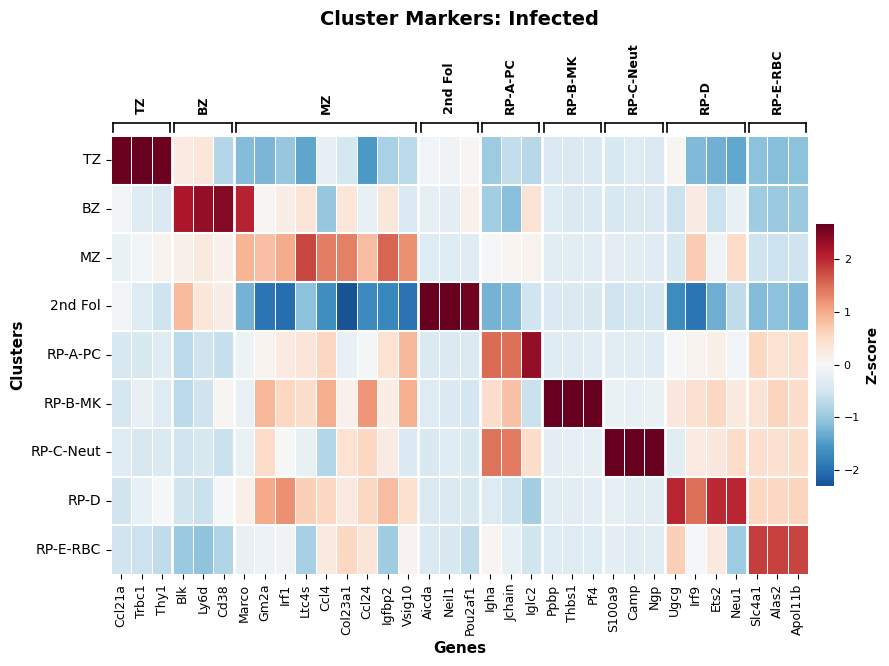

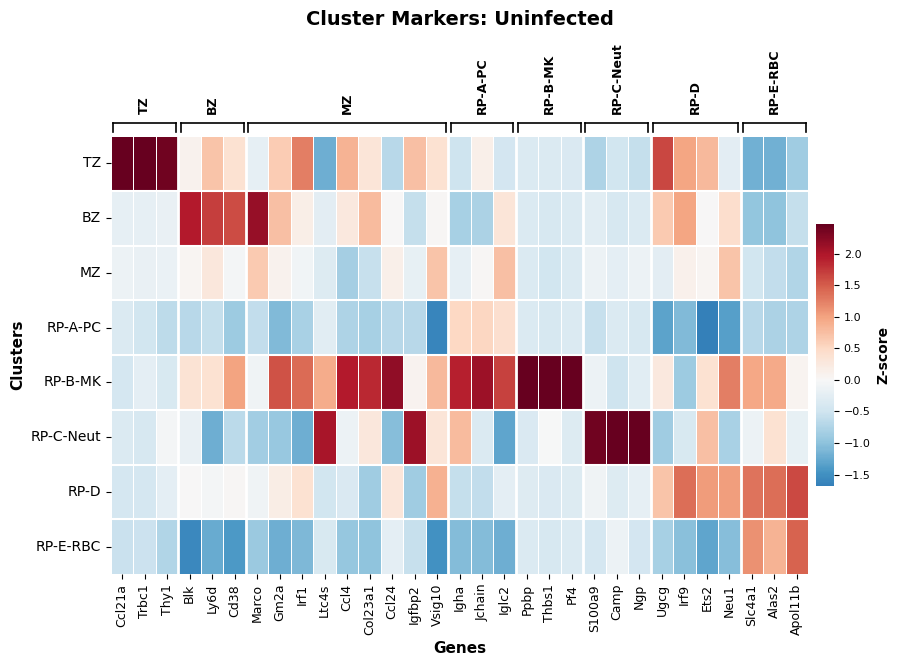

In [1]:
#!/usr/bin/env python3
"""
Compact Manual Gene List Heatmaps - Separate Conditions
Updated cluster order and gene selection with minimal white space
"""

import numpy as np
import pandas as pd
import scanpy as sc
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from collections import OrderedDict

warnings.filterwarnings('ignore')

def create_final_corrected_heatmaps():
    """
    Create compact separate heatmaps with updated cluster names and genes
    """
    print("="*80)
    print("COMPACT SEPARATE CONDITION HEATMAPS")
    print("="*80)
    
    # Define manual gene lists - NEW ORDER AND GENES
    manual_gene_lists = OrderedDict([
        ('TZ', ['Ccl21a', 'Trbc1', 'Thy1']),
        ('BZ', ['Blk', 'Ly6d', 'Cd38']),
        ('2nd Fol', ['Aicda', 'Neil1', 'Pou2af1']),
        ('MZ', ['Marco', 'Gm2a', 'Irf1', 'Ltc4s', 'Ccl4', 'Col23a1', 'Ccl24', 'Igfbp2', 'Vsig10']),
        ('RP-A-PC', ['Igha', 'Jchain', 'Iglc2']),
        ('RP-B-MK', ['Ppbp', 'Thbs1', 'Pf4']),
        ('RP-C-Neut', ['S100a9', 'Camp', 'Ngp']),
        ('RP-D', ['Ugcg', 'Irf9', 'Ets2', 'Neu1']),
        ('RP-E-RBC', ['Slc4a1', 'Alas2', 'Apol11b'])
    ])
    
    # Mapping from new names to old names in the data
    cluster_name_mapping = {
        'TZ': 'WP-A: TZ',
        'BZ': 'WP-B: BZ',
        'MZ': 'WP-C: MZ',
        '2nd Fol': 'WP-D: GC',
        'RP-A-PC': 'RP-A: GZMK',
        'RP-B-MK': 'RP-B: H_MK',
        'RP-C-Neut': 'RP-C: NGP',
        'RP-D': 'RP-D: F480',
        'RP-E-RBC': 'RP-E: Rhag'
    }
    
    try:
        # Load data
        print("Loading data...")
        adata_infected = sc.read_h5ad('/Users/yashkulkarni/cellxgene_data/cell2location_infected_030525_yk.h5ad')
        adata_uninfected = sc.read_h5ad('/Users/yashkulkarni/cellxgene_data/cell2location_uninfected_030525_yk.h5ad')
        
        # Create heatmaps for each condition
        figures = {}
        
        for condition in ['infected', 'uninfected']:
            print(f"\n{'='*60}")
            print(f"CREATING {condition.upper()} HEATMAP")
            print(f"{'='*60}")
            
            # Get condition-specific data
            if condition == 'infected':
                adata_condition = adata_infected.copy()
            else:
                adata_condition = adata_uninfected.copy()
            
            # Check cluster existence using OLD names from the data
            print("Checking cluster existence:")
            existing_clusters = []
            existing_new_names = []
            
            for new_name, old_name in cluster_name_mapping.items():
                # Check if OLD cluster name exists in this condition's data
                unique_clusters = adata_condition.obs['paper_clusters'].unique()
                cluster_exists = old_name in unique_clusters
                
                if cluster_exists:
                    n_spots = np.sum(adata_condition.obs['paper_clusters'] == old_name)
                    if n_spots > 0:
                        existing_clusters.append(old_name)
                        existing_new_names.append(new_name)
                        print(f"  ✅ {new_name} ({old_name}): {n_spots} spots - INCLUDED")
                    else:
                        print(f"  ❌ {new_name} ({old_name}): 0 spots - EXCLUDED")
                else:
                    print(f"  ❌ {new_name} ({old_name}): NOT FOUND - EXCLUDED")
            
            print(f"\n🎯 FINAL CLUSTERS FOR {condition.upper()}: {len(existing_new_names)}")
            for i, (new_name, old_name) in enumerate(zip(existing_new_names, existing_clusters), 1):
                print(f"  {i}. {new_name} ({old_name})")
            
            if len(existing_clusters) == 0:
                print(f"❌ No valid clusters found for {condition} condition!")
                continue
            
            # Create gene list ONLY for existing clusters
            condition_genes = []
            condition_gene_to_cluster = {}
            
            print(f"\nCreating gene list for {condition} condition:")
            for new_name in existing_new_names:
                cluster_genes = manual_gene_lists[new_name]
                
                for gene in cluster_genes:
                    if gene in adata_condition.var_names:
                        condition_genes.append(gene)
                        condition_gene_to_cluster[gene] = new_name
                    else:
                        print(f"    ⚠️  {gene} not found in dataset")
                        
                print(f"  {new_name}: added {len([g for g in cluster_genes if g in adata_condition.var_names])} genes")
            
            print(f"Total genes for {condition} heatmap: {len(condition_genes)}")
            
            # Create expression matrix (clusters x genes)
            expression_matrix = np.zeros((len(existing_clusters), len(condition_genes)))
            
            # Extract expression data
            if hasattr(adata_condition.X, 'toarray'):
                expr_data = adata_condition.X.toarray()
            else:
                expr_data = adata_condition.X
            
            for gene_idx, gene in enumerate(condition_genes):
                gene_adata_idx = list(adata_condition.var_names).index(gene)
                
                for cluster_idx, old_cluster_name in enumerate(existing_clusters):
                    cluster_mask = adata_condition.obs['paper_clusters'] == old_cluster_name
                    
                    if np.sum(cluster_mask) > 0:
                        expr = expr_data[cluster_mask, gene_adata_idx]
                        mean_expr = np.mean(expr)
                    else:
                        mean_expr = 0
                    
                    expression_matrix[cluster_idx, gene_idx] = mean_expr
            
            # Create DataFrame with NEW cluster names
            heatmap_df = pd.DataFrame(
                expression_matrix,
                index=existing_new_names,
                columns=condition_genes
            )
            
            # Within-condition Z-score normalization
            print(f"Applying within-{condition} Z-score normalization...")
            heatmap_zscore = heatmap_df.apply(lambda x: (x - x.mean()) / x.std(), axis=0)
            heatmap_zscore = heatmap_zscore.fillna(0)
            
            # COMPACT FIGURE SIZING
            n_genes = len(condition_genes)
            n_clusters = len(existing_new_names)
            
            # Compact sizing
            fig_width = max(10, n_genes * 0.2)  
            fig_height = max(6, n_clusters * 0.2)  
            
            fig, ax = plt.subplots(figsize=(fig_width, fig_height))
            
            # Calculate data range
            data_min = heatmap_zscore.min().min()
            data_max = heatmap_zscore.max().max()
            
            print(f"{condition} Z-score range: {data_min:.2f} to {data_max:.2f}")
            
            # Create heatmap
            sns.heatmap(
                heatmap_zscore,
                cmap='RdBu_r',
                center=0,
                vmin=data_min,
                vmax=data_max,
                cbar_kws={
                    'label': f'Z-score\n({condition})', 
                    'shrink': 0.6,
                    'pad': 0.01,
                    'aspect': 15,
                },
                xticklabels=True,
                yticklabels=True,
                ax=ax,
                linewidths=0.5,
                linecolor='white'
            )
            
            # COMPACT FONT SIZES
            # X-axis labels (genes)
            ax.set_xticklabels(condition_genes, rotation=90, ha='center', fontsize=9)
            
            # Y-axis labels (clusters) - use NEW names
            ax.set_yticklabels(existing_new_names, fontsize=10, rotation=0, ha='right', va='center')
            
            # MINIMAL margins
            plt.subplots_adjust(left=0.15, bottom=0.15, top=0.88, right=0.98)
            
            # Add cluster boundaries and brackets
            gene_count = 0
            cluster_boundaries = []
            cluster_labels = []
            
            # Use ONLY existing clusters for this condition
            for new_cluster_name in existing_new_names:
                cluster_genes_in_condition = [g for g in condition_genes if condition_gene_to_cluster.get(g) == new_cluster_name]
                if len(cluster_genes_in_condition) > 0:
                    gene_start = gene_count
                    gene_count += len(cluster_genes_in_condition)
                    gene_end = gene_count
                    
                    cluster_boundaries.append((gene_start, gene_end))
                    cluster_labels.append(new_cluster_name)
                    
                    # Add vertical separator
                    if gene_end < len(condition_genes):
                        ax.axvline(x=gene_end, color='white', linewidth=2)
            
            # Add horizontal lines between clusters
            for i in range(1, len(existing_new_names)):
                ax.axhline(y=i, color='white', linewidth=1.5)
            
            # Add brackets above gene groups - COMPACT
            trans = ax.get_xaxis_transform()
            
            for i, (label, (start, end)) in enumerate(zip(cluster_labels, cluster_boundaries)):
                # Bracket lines
                ax.plot([start + 0.1, end - 0.1], [1.03, 1.03], color='black', lw=1.2, transform=trans, clip_on=False)
                ax.plot([start + 0.1, start + 0.1], [1.01, 1.03], color='black', lw=1.2, transform=trans, clip_on=False)
                ax.plot([end - 0.1, end - 0.1], [1.01, 1.03], color='black', lw=1.2, transform=trans, clip_on=False)
                
                # Cluster label - COMPACT
                mid_point = (start + end) / 2
                plt.text(mid_point, 1.05, label, 
                         ha='center', va='bottom', rotation=90, fontsize=9, fontweight='bold',
                         transform=trans, clip_on=False)
            
            # Title and labels - COMPACT
            ax.set_title(f'Cluster Markers: {condition.title()}',
                        fontsize=14, weight='bold', pad=80)
            ax.set_ylabel('Clusters', fontsize=11, weight='bold')
            ax.set_xlabel('Genes', fontsize=11, weight='bold')
            
            # Colorbar - COMPACT
            cbar = ax.collections[0].colorbar
            cbar.set_label(f'Z-score', 
                          fontsize=10, weight='bold')
            cbar.ax.tick_params(labelsize=8)
            
            # Save plots with minimal padding
            output_prefix = f"COMPACT_{condition}_heatmap"
            plt.savefig(f"{output_prefix}.png", dpi=300, bbox_inches='tight', facecolor='white', pad_inches=0.1)
            plt.savefig(f"{output_prefix}.pdf", bbox_inches='tight', facecolor='white', pad_inches=0.1)
            
            print(f"✅ {condition.title()} heatmap saved as {output_prefix}.png and .pdf")
            
            # Save data
            heatmap_df.to_csv(f"COMPACT_{condition}_expression_matrix.csv")
            
            figures[condition] = fig
        
        plt.show()
        return figures
        
    except Exception as e:
        print(f"❌ Error: {e}")
        import traceback
        traceback.print_exc()

# Run the analysis
figures = create_final_corrected_heatmaps()


LOG-SCALE HEATMAPS - ABSOLUTE EXPRESSION
Loading data...

CREATING INFECTED LOG-SCALE HEATMAP
Checking cluster existence:
  ✅ TZ (WP-A: TZ): 74 spots - INCLUDED
  ✅ BZ (WP-B: BZ): 219 spots - INCLUDED
  ✅ 2nd Fol (WP-D: GC): 33 spots - INCLUDED
  ✅ MZ (WP-C: MZ): 242 spots - INCLUDED
  ✅ RP-A-PC (RP-A: GZMK): 194 spots - INCLUDED
  ✅ RP-B-MK (RP-B: H_MK): 75 spots - INCLUDED
  ✅ RP-C-Neut (RP-C: NGP): 90 spots - INCLUDED
  ✅ RP-D (RP-D: F480): 119 spots - INCLUDED
  ✅ RP-E-RBC (RP-E: Rhag): 222 spots - INCLUDED

🎯 FINAL CLUSTERS FOR INFECTED: 9
  1. TZ (WP-A: TZ)
  2. BZ (WP-B: BZ)
  3. 2nd Fol (WP-D: GC)
  4. MZ (WP-C: MZ)
  5. RP-A-PC (RP-A: GZMK)
  6. RP-B-MK (RP-B: H_MK)
  7. RP-C-Neut (RP-C: NGP)
  8. RP-D (RP-D: F480)
  9. RP-E-RBC (RP-E: Rhag)

Creating gene list for infected condition:
  TZ: added 3 genes
  BZ: added 3 genes
  2nd Fol: added 3 genes
  MZ: added 3 genes
  RP-A-PC: added 3 genes
  RP-B-MK: added 3 genes
  RP-C-Neut: added 3 genes
  RP-D: added 4 genes
  RP-E-RBC:

Traceback (most recent call last):
  File "/var/folders/qb/hfnm72x95497q4_ptv95pn8r0000gn/T/ipykernel_17051/1244892979.py", line 246, in create_log_scale_heatmaps
    plt.savefig(f"{output_prefix}.pdf", bbox_inches='tight', facecolor='white', pad_inches=0.1)
  File "/opt/anaconda3/envs/hd_visium_env/lib/python3.10/site-packages/matplotlib/pyplot.py", line 1243, in savefig
    res = fig.savefig(*args, **kwargs)  # type: ignore[func-returns-value]
  File "/opt/anaconda3/envs/hd_visium_env/lib/python3.10/site-packages/matplotlib/figure.py", line 3490, in savefig
    self.canvas.print_figure(fname, **kwargs)
  File "/opt/anaconda3/envs/hd_visium_env/lib/python3.10/site-packages/matplotlib/backend_bases.py", line 2184, in print_figure
    result = print_method(
  File "/opt/anaconda3/envs/hd_visium_env/lib/python3.10/site-packages/matplotlib/backend_bases.py", line 2040, in <lambda>
    print_method = functools.wraps(meth)(lambda *args, **kwargs: meth(
  File "/opt/anaconda3/envs/hd_visium_

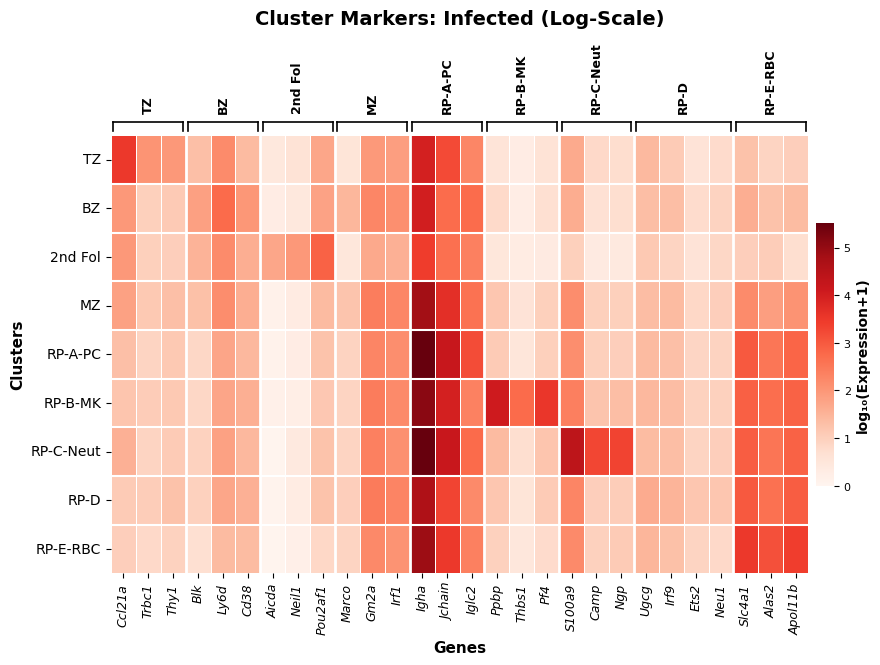

In [3]:
#!/usr/bin/env python3
"""
Log-Scale Heatmaps - Separate Conditions
Shows absolute expression magnitude instead of z-scores
"""

import numpy as np
import pandas as pd
import scanpy as sc
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from collections import OrderedDict

warnings.filterwarnings('ignore')

def create_log_scale_heatmaps():
    """
    Create compact separate heatmaps with LOG-SCALE (not z-score)
    """
    print("="*80)
    print("LOG-SCALE HEATMAPS - ABSOLUTE EXPRESSION")
    print("="*80)
    
    # Define manual gene lists - SAME as your z-score version
    manual_gene_lists = OrderedDict([
        ('TZ', ['Ccl21a', 'Trbc1', 'Thy1']),
        ('BZ', ['Blk', 'Ly6d', 'Cd38']),
        ('2nd Fol', ['Aicda', 'Neil1', 'Pou2af1']),
        ('MZ', ['Marco', 'Gm2a', 'Irf1']),
        ('RP-A-PC', ['Igha', 'Jchain', 'Iglc2']),
        ('RP-B-MK', ['Ppbp', 'Thbs1', 'Pf4']),
        ('RP-C-Neut', ['S100a9', 'Camp', 'Ngp']),
        ('RP-D', ['Ugcg', 'Irf9', 'Ets2', 'Neu1']),
        ('RP-E-RBC', ['Slc4a1', 'Alas2', 'Apol11b'])
    ])
    
    # Mapping from new names to old names
    cluster_name_mapping = {
        'TZ': 'WP-A: TZ',
        'BZ': 'WP-B: BZ',
        '2nd Fol': 'WP-D: GC',
        'MZ': 'WP-C: MZ',
        'RP-A-PC': 'RP-A: GZMK',
        'RP-B-MK': 'RP-B: H_MK',
        'RP-C-Neut': 'RP-C: NGP',
        'RP-D': 'RP-D: F480',
        'RP-E-RBC': 'RP-E: Rhag'
    }
    
    try:
        # Load data
        print("Loading data...")
        adata_infected = sc.read_h5ad('/Users/yashkulkarni/cellxgene_data/cell2location_infected_030525_yk.h5ad')
        adata_uninfected = sc.read_h5ad('/Users/yashkulkarni/cellxgene_data/cell2location_uninfected_030525_yk.h5ad')
        
        figures = {}
        
        for condition in ['infected', 'uninfected']:
            print(f"\n{'='*60}")
            print(f"CREATING {condition.upper()} LOG-SCALE HEATMAP")
            print(f"{'='*60}")
            
            # Get condition-specific data
            if condition == 'infected':
                adata_condition = adata_infected.copy()
            else:
                adata_condition = adata_uninfected.copy()
            
            # Check cluster existence
            print("Checking cluster existence:")
            existing_clusters = []
            existing_new_names = []
            
            for new_name, old_name in cluster_name_mapping.items():
                unique_clusters = adata_condition.obs['paper_clusters'].unique()
                cluster_exists = old_name in unique_clusters
                
                if cluster_exists:
                    n_spots = np.sum(adata_condition.obs['paper_clusters'] == old_name)
                    if n_spots > 0:
                        existing_clusters.append(old_name)
                        existing_new_names.append(new_name)
                        print(f"  ✅ {new_name} ({old_name}): {n_spots} spots - INCLUDED")
                    else:
                        print(f"  ❌ {new_name} ({old_name}): 0 spots - EXCLUDED")
                else:
                    print(f"  ❌ {new_name} ({old_name}): NOT FOUND - EXCLUDED")
            
            print(f"\n🎯 FINAL CLUSTERS FOR {condition.upper()}: {len(existing_new_names)}")
            for i, (new_name, old_name) in enumerate(zip(existing_new_names, existing_clusters), 1):
                print(f"  {i}. {new_name} ({old_name})")
            
            if len(existing_clusters) == 0:
                print(f"❌ No valid clusters found for {condition} condition!")
                continue
            
            # Create gene list
            condition_genes = []
            condition_gene_to_cluster = {}
            
            print(f"\nCreating gene list for {condition} condition:")
            for new_name in existing_new_names:
                cluster_genes = manual_gene_lists[new_name]
                
                for gene in cluster_genes:
                    if gene in adata_condition.var_names:
                        condition_genes.append(gene)
                        condition_gene_to_cluster[gene] = new_name
                    else:
                        print(f"    ⚠️  {gene} not found in dataset")
                        
                print(f"  {new_name}: added {len([g for g in cluster_genes if g in adata_condition.var_names])} genes")
            
            print(f"Total genes for {condition} heatmap: {len(condition_genes)}")
            
            # Create expression matrix
            expression_matrix = np.zeros((len(existing_clusters), len(condition_genes)))
            
            # Extract expression data
            if hasattr(adata_condition.X, 'toarray'):
                expr_data = adata_condition.X.toarray()
            else:
                expr_data = adata_condition.X
            
            for gene_idx, gene in enumerate(condition_genes):
                gene_adata_idx = list(adata_condition.var_names).index(gene)
                
                for cluster_idx, old_cluster_name in enumerate(existing_clusters):
                    cluster_mask = adata_condition.obs['paper_clusters'] == old_cluster_name
                    
                    if np.sum(cluster_mask) > 0:
                        expr = expr_data[cluster_mask, gene_adata_idx]
                        mean_expr = np.mean(expr)
                    else:
                        mean_expr = 0
                    
                    expression_matrix[cluster_idx, gene_idx] = mean_expr
            
            # Create DataFrame
            heatmap_df = pd.DataFrame(
                expression_matrix,
                index=existing_new_names,
                columns=condition_genes
            )
            
            # LOG-SCALE NORMALIZATION (instead of z-score)
            print(f"Applying log1p transformation...")
            heatmap_log = np.log1p(heatmap_df)  # log(x + 1)
            
            print(f"  Raw expression range: {heatmap_df.min().min():.2f} to {heatmap_df.max().max():.2f}")
            print(f"  Log expression range: {heatmap_log.min().min():.2f} to {heatmap_log.max().max():.2f}")
            
            # COMPACT FIGURE SIZING
            n_genes = len(condition_genes)
            n_clusters = len(existing_new_names)
            
            fig_width = max(10, n_genes * 0.2)  
            fig_height = max(6, n_clusters * 0.2)  
            
            fig, ax = plt.subplots(figsize=(fig_width, fig_height))
            
            # Calculate data range for color scale
            data_min = heatmap_log.min().min()
            data_max = heatmap_log.max().max()
            
            # Create heatmap with REDS colormap (standard for expression)
            sns.heatmap(
                heatmap_log,
                cmap='Reds',  # Single-color gradient for expression
                vmin=0,  # Start at 0 (no expression)
                vmax=data_max,
                cbar_kws={
                    'label': f'log₁₀(Expression+1)', 
                    'shrink': 0.6,
                    'pad': 0.01,
                    'aspect': 15,
                },
                xticklabels=True,
                yticklabels=True,
                ax=ax,
                linewidths=0.5,
                linecolor='white'
            )
            
            # COMPACT FONT SIZES
            ax.set_xticklabels(condition_genes, rotation=90, ha='center', fontsize=9, style='italic')
            ax.set_yticklabels(existing_new_names, fontsize=10, rotation=0, ha='right', va='center')
            
            # MINIMAL margins
            plt.subplots_adjust(left=0.15, bottom=0.15, top=0.88, right=0.98)
            
            # Add cluster boundaries and brackets
            gene_count = 0
            cluster_boundaries = []
            cluster_labels = []
            
            for new_cluster_name in existing_new_names:
                cluster_genes_in_condition = [g for g in condition_genes if condition_gene_to_cluster.get(g) == new_cluster_name]
                if len(cluster_genes_in_condition) > 0:
                    gene_start = gene_count
                    gene_count += len(cluster_genes_in_condition)
                    gene_end = gene_count
                    
                    cluster_boundaries.append((gene_start, gene_end))
                    cluster_labels.append(new_cluster_name)
                    
                    # Add vertical separator
                    if gene_end < len(condition_genes):
                        ax.axvline(x=gene_end, color='white', linewidth=2)
            
            # Add horizontal lines between clusters
            for i in range(1, len(existing_new_names)):
                ax.axhline(y=i, color='white', linewidth=1.5)
            
            # Add brackets above gene groups
            trans = ax.get_xaxis_transform()
            
            for i, (label, (start, end)) in enumerate(zip(cluster_labels, cluster_boundaries)):
                # Bracket lines
                ax.plot([start + 0.1, end - 0.1], [1.03, 1.03], color='black', lw=1.2, transform=trans, clip_on=False)
                ax.plot([start + 0.1, start + 0.1], [1.01, 1.03], color='black', lw=1.2, transform=trans, clip_on=False)
                ax.plot([end - 0.1, end - 0.1], [1.01, 1.03], color='black', lw=1.2, transform=trans, clip_on=False)
                
                # Cluster label
                mid_point = (start + end) / 2
                plt.text(mid_point, 1.05, label, 
                         ha='center', va='bottom', rotation=90, fontsize=9, fontweight='bold',
                         transform=trans, clip_on=False)
            
            # Title and labels
            ax.set_title(f'Cluster Markers: {condition.title()} (Log-Scale)',
                        fontsize=14, weight='bold', pad=80)
            ax.set_ylabel('Clusters', fontsize=11, weight='bold')
            ax.set_xlabel('Genes', fontsize=11, weight='bold')
            
            # Colorbar styling
            cbar = ax.collections[0].colorbar
            cbar.set_label(f'log₁₀(Expression+1)', 
                          fontsize=10, weight='bold')
            cbar.ax.tick_params(labelsize=8)
            
            # Save plots
            output_prefix = f"LOGSCALE_{condition}_heatmap"
            plt.savefig(f"{output_prefix}.png", dpi=300, bbox_inches='tight', facecolor='white', pad_inches=0.1)
            plt.savefig(f"{output_prefix}.pdf", bbox_inches='tight', facecolor='white', pad_inches=0.1)
            
            print(f"✅ {condition.title()} log-scale heatmap saved as {output_prefix}.png and .pdf")
            
            # Save raw and log data
            heatmap_df.to_csv(f"LOGSCALE_{condition}_raw_expression_matrix.csv")
            heatmap_log.to_csv(f"LOGSCALE_{condition}_log_expression_matrix.csv")
            
            figures[condition] = fig
        
        plt.show()
        return figures
        
    except Exception as e:
        print(f"❌ Error: {e}")
        import traceback
        traceback.print_exc()

# Run the analysis
figures = create_log_scale_heatmaps()

print("\n" + "="*80)
print("COMPARISON: Z-SCORE vs LOG-SCALE")
print("="*80)
print("Z-SCORE version (your original):")
print("  ✅ Shows RELATIVE patterns (high/low within each gene)")
print("  ❌ Hides absolute expression magnitude")
print("  📊 Use for: Exploratory pattern finding")
print("")
print("LOG-SCALE version (this code):")
print("  ✅ Shows ABSOLUTE expression levels")
print("  ✅ Darker color = more biologically abundant")
print("  ❌ Low-expression genes may appear pale")
print("  📊 Use for: Publication main figures")
print("")
print("💡 TIP: Use BOTH in your paper!")
print("   - Main figure: Log-scale (shows biology)")
print("   - Supplement: Z-score (shows patterns)")
print("="*80)

DIAGNOSTIC: RAW vs Z-SCORE EXPRESSION ANALYSIS

Data shape: (1268, 5155)
Data type: <class 'numpy.ndarray'>
Expression range: 0.0000 to 5783.0000

GENE-BY-GENE DIAGNOSTIC

⚠️  POTENTIALLY PROBLEMATIC GENES (Low expression but high z-score):
--------------------------------------------------------------------------------
  ✅ No suspicious genes found!

✅ WELL-EXPRESSED GENES (High raw expression):
--------------------------------------------------------------------------------
  Igha         (RP-A-PC   ): mean=128.201, max_z=1.50
  Jchain       (RP-A-PC   ): mean=36.746, max_z=1.47
  S100a9       (RP-C-Neut ): mean=14.524, max_z=2.65
  Slc4a1       (RP-E-RBC  ): mean=13.543, max_z=1.83
  Iglc2        (RP-A-PC   ): mean=12.350, max_z=2.32
  Apol11b      (RP-E-RBC  ): mean=12.131, max_z=1.79
  Alas2        (RP-E-RBC  ): mean=9.338, max_z=1.82
  Gm2a         (MZ        ): mean=8.656, max_z=1.01
  Ppbp         (RP-B-MK   ): mean=8.069, max_z=2.66
  Irf1         (MZ        ): mean=7.119, max

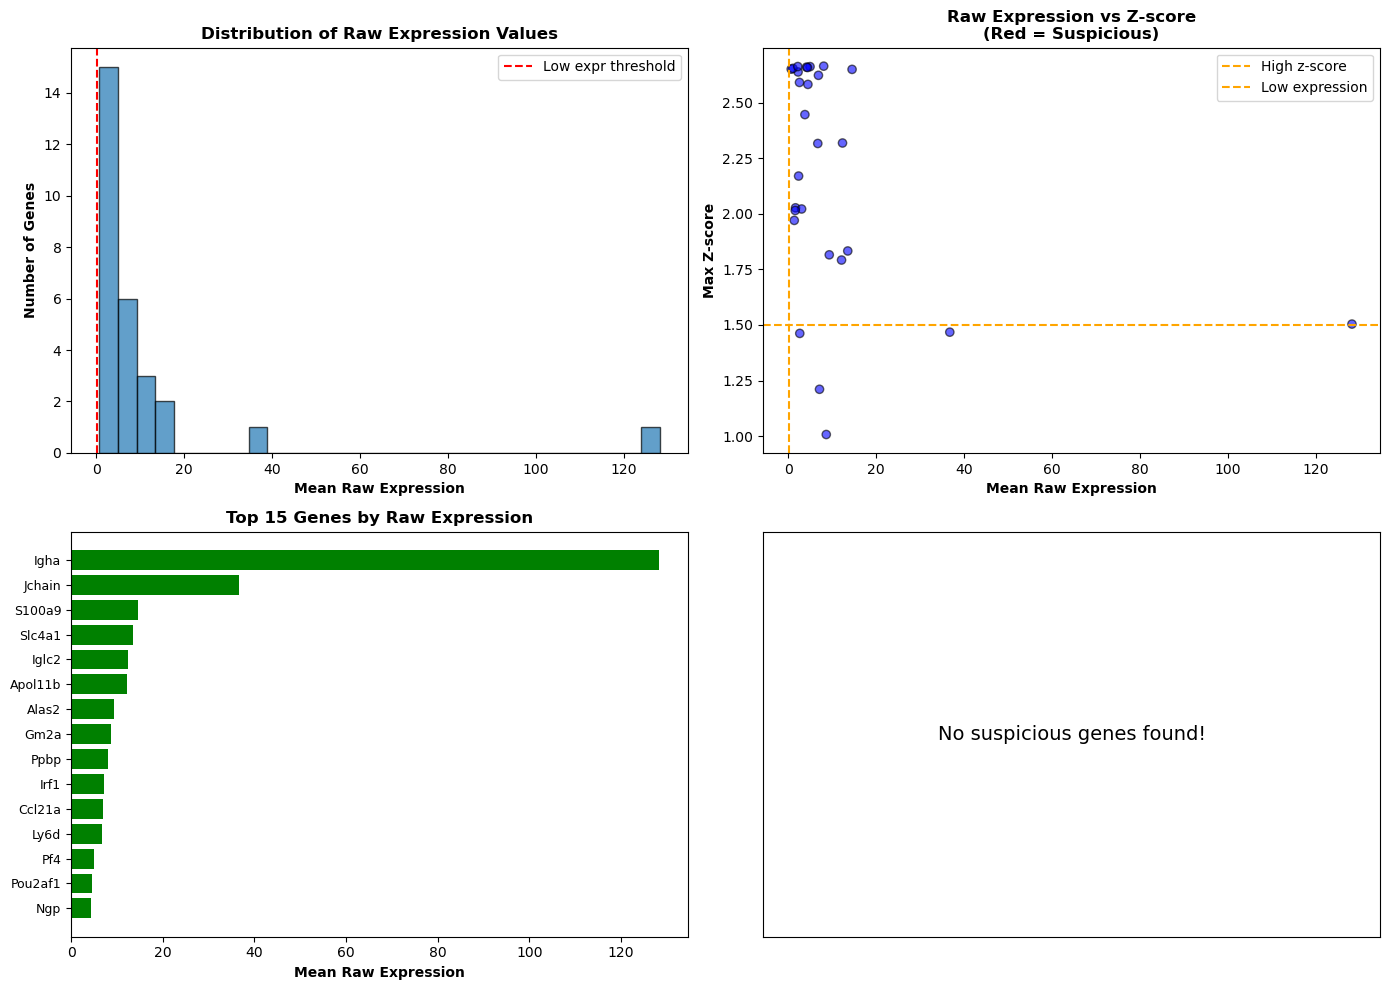


PER-CLUSTER SUMMARY

TZ (WP-A: TZ):
  Genes: Ccl21a, Trbc1, Thy1
  Mean raw expression: 3.897
  Suspicious genes: 0/3

BZ (WP-B: BZ):
  Genes: Blk, Ly6d, Cd38
  Mean raw expression: 4.297
  Suspicious genes: 0/3

2nd Fol (WP-D: GC):
  Genes: Aicda, Neil1, Pou2af1
  Mean raw expression: 2.080
  Suspicious genes: 0/3

MZ (WP-C: MZ):
  Genes: Marco, Gm2a, Irf1
  Mean raw expression: 5.812
  Suspicious genes: 0/3

RP-A-PC (RP-A: GZMK):
  Genes: Igha, Jchain, Iglc2
  Mean raw expression: 59.099
  Suspicious genes: 0/3

RP-B-MK (RP-B: H_MK):
  Genes: Ppbp, Thbs1, Pf4
  Mean raw expression: 5.071
  Suspicious genes: 0/3

RP-C-Neut (RP-C: NGP):
  Genes: S100a9, Camp, Ngp
  Mean raw expression: 7.694
  Suspicious genes: 0/3

RP-D (RP-D: F480):
  Genes: Ugcg, Irf9, Ets2, Neu1
  Mean raw expression: 2.167
  Suspicious genes: 0/4

RP-E-RBC (RP-E: Rhag):
  Genes: Slc4a1, Alas2, Apol11b
  Mean raw expression: 11.671
  Suspicious genes: 0/3


In [1]:
#!/usr/bin/env python3
"""
Diagnostic: Check if Z-score is amplifying noise
Compare RAW vs Z-SCORED expression for each gene
"""

import numpy as np
import pandas as pd
import scanpy as sc
import matplotlib.pyplot as plt
import seaborn as sns
from collections import OrderedDict

# Define same genes as your heatmap
manual_gene_lists = OrderedDict([
    ('TZ', ['Ccl21a', 'Trbc1', 'Thy1']),
    ('BZ', ['Blk', 'Ly6d', 'Cd38']),
    ('2nd Fol', ['Aicda', 'Neil1', 'Pou2af1']),
    ('MZ', ['Marco', 'Gm2a', 'Irf1']),
    ('RP-A-PC', ['Igha', 'Jchain', 'Iglc2']),
    ('RP-B-MK', ['Ppbp', 'Thbs1', 'Pf4']),
    ('RP-C-Neut', ['S100a9', 'Camp', 'Ngp']),
    ('RP-D', ['Ugcg', 'Irf9', 'Ets2', 'Neu1']),
    ('RP-E-RBC', ['Slc4a1', 'Alas2', 'Apol11b'])
])

cluster_name_mapping = {
    'TZ': 'WP-A: TZ',
    'BZ': 'WP-B: BZ',
    '2nd Fol': 'WP-D: GC',
    'MZ': 'WP-C: MZ',
    'RP-A-PC': 'RP-A: GZMK',
    'RP-B-MK': 'RP-B: H_MK',
    'RP-C-Neut': 'RP-C: NGP',
    'RP-D': 'RP-D: F480',
    'RP-E-RBC': 'RP-E: Rhag'
}

print("="*80)
print("DIAGNOSTIC: RAW vs Z-SCORE EXPRESSION ANALYSIS")
print("="*80)

# Load infected data (you can do same for uninfected)
adata = sc.read_h5ad('/Users/yashkulkarni/cellxgene_data/cell2location_infected_030525_yk.h5ad')

print(f"\nData shape: {adata.shape}")
print(f"Data type: {type(adata.X)}")
print(f"Expression range: {adata.X.min():.4f} to {adata.X.max():.4f}")

# Get all genes from your lists
all_genes = []
gene_to_cluster = {}
for cluster_name, genes in manual_gene_lists.items():
    for gene in genes:
        if gene in adata.var_names:
            all_genes.append(gene)
            gene_to_cluster[gene] = cluster_name

# Get all clusters
all_cluster_names = [cluster_name_mapping[k] for k in manual_gene_lists.keys() 
                     if cluster_name_mapping[k] in adata.obs['paper_clusters'].unique()]

# Build expression matrix (same as your heatmap code)
expression_matrix = np.zeros((len(all_cluster_names), len(all_genes)))

if hasattr(adata.X, 'toarray'):
    expr_data = adata.X.toarray()
else:
    expr_data = adata.X

for gene_idx, gene in enumerate(all_genes):
    gene_adata_idx = list(adata.var_names).index(gene)
    
    for cluster_idx, cluster_name in enumerate(all_cluster_names):
        cluster_mask = adata.obs['paper_clusters'] == cluster_name
        
        if np.sum(cluster_mask) > 0:
            expr = expr_data[cluster_mask, gene_adata_idx]
            mean_expr = np.mean(expr)
        else:
            mean_expr = 0
        
        expression_matrix[cluster_idx, gene_idx] = mean_expr

# Create DataFrames
raw_df = pd.DataFrame(
    expression_matrix,
    index=[k for k, v in cluster_name_mapping.items() if v in all_cluster_names],
    columns=all_genes
)

# Calculate Z-scores (same as your heatmap)
zscore_df = raw_df.apply(lambda x: (x - x.mean()) / x.std(), axis=0)
zscore_df = zscore_df.fillna(0)

# DIAGNOSTIC REPORT
print("\n" + "="*80)
print("GENE-BY-GENE DIAGNOSTIC")
print("="*80)

diagnostic_results = []

for gene in all_genes:
    cluster = gene_to_cluster[gene]
    
    raw_values = raw_df[gene].values
    z_values = zscore_df[gene].values
    
    # Key metrics
    mean_raw = raw_values.mean()
    max_raw = raw_values.max()
    std_raw = raw_values.std()
    range_raw = raw_values.max() - raw_values.min()
    
    mean_z = z_values.mean()
    max_z = z_values.max()
    std_z = z_values.std()
    range_z = z_values.max() - z_values.min()
    
    # Flag potential issues
    is_low_expression = mean_raw < 0.1
    is_high_z_score = max_z > 1.5
    is_suspicious = is_low_expression and is_high_z_score
    
    diagnostic_results.append({
        'Gene': gene,
        'Cluster': cluster,
        'Mean_Raw': mean_raw,
        'Max_Raw': max_raw,
        'Std_Raw': std_raw,
        'Range_Raw': range_raw,
        'Max_Z': max_z,
        'Range_Z': range_z,
        'Low_Expr': is_low_expression,
        'High_Z': is_high_z_score,
        'SUSPICIOUS': is_suspicious
    })

diag_df = pd.DataFrame(diagnostic_results)

# Print suspicious genes
print("\n⚠️  POTENTIALLY PROBLEMATIC GENES (Low expression but high z-score):")
print("-" * 80)
suspicious = diag_df[diag_df['SUSPICIOUS']]
if len(suspicious) > 0:
    for _, row in suspicious.iterrows():
        print(f"\n  {row['Gene']} ({row['Cluster']})")
        print(f"    Raw expression: mean={row['Mean_Raw']:.4f}, max={row['Max_Raw']:.4f}")
        print(f"    Z-score: max={row['Max_Z']:.2f}, range={row['Range_Z']:.2f}")
        print(f"    ⚠️  LOW RAW EXPRESSION but STRONG Z-SCORE SIGNAL")
else:
    print("  ✅ No suspicious genes found!")

# Print well-behaved genes
print("\n✅ WELL-EXPRESSED GENES (High raw expression):")
print("-" * 80)
good_genes = diag_df[~diag_df['Low_Expr']].sort_values('Mean_Raw', ascending=False).head(10)
for _, row in good_genes.iterrows():
    print(f"  {row['Gene']:<12} ({row['Cluster']:<10}): mean={row['Mean_Raw']:.3f}, max_z={row['Max_Z']:.2f}")

# Summary statistics
print("\n" + "="*80)
print("SUMMARY STATISTICS")
print("="*80)
print(f"Total genes analyzed: {len(all_genes)}")
print(f"Low expression genes (<0.1): {diag_df['Low_Expr'].sum()} ({diag_df['Low_Expr'].sum()/len(all_genes)*100:.1f}%)")
print(f"High z-score genes (>1.5): {diag_df['High_Z'].sum()} ({diag_df['High_Z'].sum()/len(all_genes)*100:.1f}%)")
print(f"SUSPICIOUS genes: {diag_df['SUSPICIOUS'].sum()} ({diag_df['SUSPICIOUS'].sum()/len(all_genes)*100:.1f}%)")


# VISUALIZATION
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1: Raw expression distribution
ax1 = axes[0, 0]
ax1.hist(diag_df['Mean_Raw'], bins=30, edgecolor='black', alpha=0.7)
ax1.axvline(0.1, color='red', linestyle='--', label='Low expr threshold')
ax1.set_xlabel('Mean Raw Expression', fontweight='bold')
ax1.set_ylabel('Number of Genes', fontweight='bold')
ax1.set_title('Distribution of Raw Expression Values', fontweight='bold')
ax1.legend()

# Plot 2: Raw vs Z-score max
ax2 = axes[0, 1]
colors = ['red' if x else 'blue' for x in diag_df['SUSPICIOUS']]
ax2.scatter(diag_df['Mean_Raw'], diag_df['Max_Z'], c=colors, alpha=0.6, edgecolors='black')
ax2.axhline(1.5, color='orange', linestyle='--', label='High z-score')
ax2.axvline(0.1, color='orange', linestyle='--', label='Low expression')
ax2.set_xlabel('Mean Raw Expression', fontweight='bold')
ax2.set_ylabel('Max Z-score', fontweight='bold')
ax2.set_title('Raw Expression vs Z-score\n(Red = Suspicious)', fontweight='bold')
ax2.legend()

# Plot 3: Gene ranking by raw expression
ax3 = axes[1, 0]
top_genes = diag_df.nlargest(15, 'Mean_Raw')
ax3.barh(range(len(top_genes)), top_genes['Mean_Raw'], 
         color=['red' if x else 'green' for x in top_genes['SUSPICIOUS']])
ax3.set_yticks(range(len(top_genes)))
ax3.set_yticklabels(top_genes['Gene'], fontsize=9)
ax3.set_xlabel('Mean Raw Expression', fontweight='bold')
ax3.set_title('Top 15 Genes by Raw Expression', fontweight='bold')
ax3.invert_yaxis()

# Plot 4: Heatmap comparison for suspicious genes
ax4 = axes[1, 1]
if len(suspicious) > 0:
    susp_genes = suspicious['Gene'].tolist()[:10]  # Top 10 suspicious
    susp_raw = raw_df[susp_genes].T
    susp_z = zscore_df[susp_genes].T
    
    # Show side by side
    combined = pd.concat([susp_raw, susp_z], axis=1)
    combined.columns = list(susp_raw.columns) + [f"{c}_z" for c in susp_z.columns]
    
    im = ax4.imshow(susp_raw.values, aspect='auto', cmap='Reds')
    ax4.set_yticks(range(len(susp_genes)))
    ax4.set_yticklabels(susp_genes, fontsize=8)
    ax4.set_xticks(range(len(all_cluster_names)))
    ax4.set_xticklabels([k for k, v in cluster_name_mapping.items() if v in all_cluster_names], 
                        rotation=45, ha='right', fontsize=8)
    ax4.set_title('Suspicious Genes: Raw Expression', fontweight='bold', fontsize=10)
    plt.colorbar(im, ax=ax4, label='Raw Expression')
else:
    ax4.text(0.5, 0.5, 'No suspicious genes found!', 
             ha='center', va='center', fontsize=14, transform=ax4.transAxes)
    ax4.set_xticks([])
    ax4.set_yticks([])

plt.tight_layout()
plt.show()

# Print per-cluster summary
print("\n" + "="*80)
print("PER-CLUSTER SUMMARY")
print("="*80)
for cluster_short, cluster_long in cluster_name_mapping.items():
    if cluster_long in all_cluster_names:
        cluster_genes = [g for g in all_genes if gene_to_cluster[g] == cluster_short]
        cluster_diag = diag_df[diag_df['Cluster'] == cluster_short]
        
        print(f"\n{cluster_short} ({cluster_long}):")
        print(f"  Genes: {', '.join(cluster_genes)}")
        print(f"  Mean raw expression: {cluster_diag['Mean_Raw'].mean():.3f}")
        print(f"  Suspicious genes: {cluster_diag['SUSPICIOUS'].sum()}/{len(cluster_diag)}")

In [2]:
adata = sc.read_h5ad('/Users/yashkulkarni/cellxgene_data/cell2location_infected_030525_yk.h5ad')
print(adata.X.min(), adata.X.max())
print(adata.layers.keys())  # What other data is stored?
print(adata.var_names[:10])  # Are these genes or cell types?
print(adata.obs.columns)  # What metadata exists?

0 5783
KeysView(Layers with keys: Bcell_estimated_expression, Bcell_predicted_scale, CD4-Tcell_estimated_expression, CD4-Tcell_predicted_scale, CD8-Tcell_estimated_expression, CD8-Tcell_predicted_scale, Endothelial_estimated_expression, Endothelial_predicted_scale, Fibroblast_estimated_expression, Fibroblast_predicted_scale, Hematopoietic_estimated_expression, Hematopoietic_predicted_scale, Mast-Cell_estimated_expression, Mast-Cell_predicted_scale, Myeloid_estimated_expression, Myeloid_predicted_scale, NK_estimated_expression, NK_predicted_scale, Neutrophil_estimated_expression, Neutrophil_predicted_scale, counts, fine_expression, noise_estimated_expression, noise_predicted_scale, poisson_residuals)
Index(['0610009L18Rik', '0610030E20Rik', '0610039K10Rik', '0610040B10Rik',
       '1010001B22Rik', '1110006O24Rik', '1110008P14Rik', '1110028F11Rik',
       '1110032F04Rik', '1110035H17Rik'],
      dtype='object')
Index(['in_tissue', 'array_row', 'array_col', 'age', 'condition',
       'n_g

COMBINED INFECTED/UNINFECTED HEATMAP
Loading data...

Total genes: 28

Processing cluster: TZ
  Infected: 74 spots, Uninfected: 50 spots

Processing cluster: BZ
  Infected: 219 spots, Uninfected: 168 spots

Processing cluster: 2nd Fol
  Infected: 33 spots, Uninfected: 0 spots

Processing cluster: MZ
  Infected: 242 spots, Uninfected: 283 spots

Processing cluster: RP-A-PC
  Infected: 194 spots, Uninfected: 325 spots

Processing cluster: RP-B-MK
  Infected: 75 spots, Uninfected: 33 spots

Processing cluster: RP-C-Neut
  Infected: 90 spots, Uninfected: 38 spots

Processing cluster: RP-D
  Infected: 119 spots, Uninfected: 119 spots

Processing cluster: RP-E-RBC
  Infected: 222 spots, Uninfected: 261 spots

Final heatmap shape: (17, 28)
Rows (alternating infected/uninfected): 17
Columns (genes): 28

Applying Z-score normalization across both conditions...
Z-score range: -1.33 to 3.85

✅ Combined heatmap saved as COMBINED_infected_uninfected_heatmap.png and .pdf


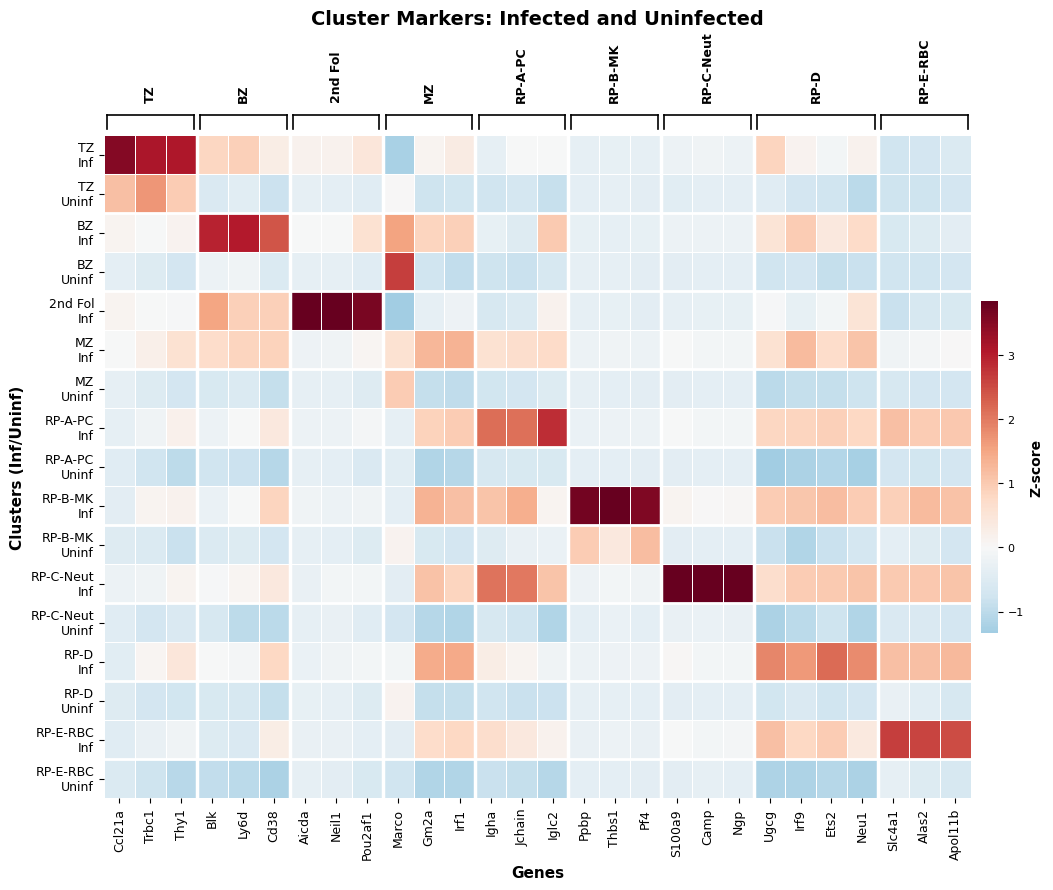

In [22]:
#!/usr/bin/env python3
"""
Combined Infected/Uninfected Heatmap - Alternating Rows
Shows infected and uninfected for each cluster with gap for missing 2o Fol
"""

import numpy as np
import pandas as pd
import scanpy as sc
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from collections import OrderedDict

warnings.filterwarnings('ignore')

def create_combined_heatmap():
    """
    Create combined heatmap with alternating infected/uninfected rows
    """
    print("="*80)
    print("COMBINED INFECTED/UNINFECTED HEATMAP")
    print("="*80)
    
    # Define manual gene lists - NEW ORDER AND GENES
    manual_gene_lists = OrderedDict([
        ('TZ', ['Ccl21a', 'Trbc1', 'Thy1']),
        ('BZ', ['Blk', 'Ly6d', 'Cd38']),
        ('2nd Fol', ['Aicda', 'Neil1', 'Pou2af1']),
        ('MZ', ['Marco', 'Gm2a', 'Irf1']),
        ('RP-A-PC', ['Igha', 'Jchain', 'Iglc2']),
        ('RP-B-MK', ['Ppbp', 'Thbs1', 'Pf4']),
        ('RP-C-Neut', ['S100a9', 'Camp', 'Ngp']),
        ('RP-D', ['Ugcg', 'Irf9', 'Ets2', 'Neu1']),
        ('RP-E-RBC', ['Slc4a1', 'Alas2', 'Apol11b'])
    ])
    
    # Mapping from new names to old names in the data
    cluster_name_mapping = {
        'TZ': 'WP-A: TZ',
        'BZ': 'WP-B: BZ',
        '2nd Fol': 'WP-D: GC',
        'MZ': 'WP-C: MZ',
        'RP-A-PC': 'RP-A: GZMK',
        'RP-B-MK': 'RP-B: H_MK',
        'RP-C-Neut': 'RP-C: NGP',
        'RP-D': 'RP-D: F480',
        'RP-E-RBC': 'RP-E: Rhag'
    }
    
    try:
        # Load data
        print("Loading data...")
        adata_infected = sc.read_h5ad('/Users/yashkulkarni/cellxgene_data/cell2location_infected_030525_yk.h5ad')
        adata_uninfected = sc.read_h5ad('/Users/yashkulkarni/cellxgene_data/cell2location_uninfected_030525_yk.h5ad')
        
        # Collect all genes across all clusters
        all_genes = []
        gene_to_cluster = {}
        
        for new_name in manual_gene_lists.keys():
            cluster_genes = manual_gene_lists[new_name]
            for gene in cluster_genes:
                # Check if gene exists in either dataset
                if gene in adata_infected.var_names or gene in adata_uninfected.var_names:
                    all_genes.append(gene)
                    gene_to_cluster[gene] = new_name
                else:
                    print(f"⚠️  {gene} not found in either dataset")
        
        print(f"\nTotal genes: {len(all_genes)}")
        
        # Build combined row structure (alternating infected/uninfected)
        row_labels = []
        row_data_list = []
        
        for new_name, old_name in cluster_name_mapping.items():
            print(f"\nProcessing cluster: {new_name}")
            
            # Check infected
            infected_exists = old_name in adata_infected.obs['paper_clusters'].unique()
            infected_n = np.sum(adata_infected.obs['paper_clusters'] == old_name) if infected_exists else 0
            
            # Check uninfected
            uninfected_exists = old_name in adata_uninfected.obs['paper_clusters'].unique()
            uninfected_n = np.sum(adata_uninfected.obs['paper_clusters'] == old_name) if uninfected_exists else 0
            
            print(f"  Infected: {infected_n} spots, Uninfected: {uninfected_n} spots")
            
            # Add infected row
            if infected_exists and infected_n > 0:
                row_data = np.zeros(len(all_genes))
                
                # Extract expression data
                if hasattr(adata_infected.X, 'toarray'):
                    expr_data = adata_infected.X.toarray()
                else:
                    expr_data = adata_infected.X
                
                for gene_idx, gene in enumerate(all_genes):
                    if gene in adata_infected.var_names:
                        gene_adata_idx = list(adata_infected.var_names).index(gene)
                        cluster_mask = adata_infected.obs['paper_clusters'] == old_name
                        expr = expr_data[cluster_mask, gene_adata_idx]
                        row_data[gene_idx] = np.mean(expr)
                    else:
                        row_data[gene_idx] = np.nan
                
                row_data_list.append(row_data)
                row_labels.append(f"{new_name}\nInf")
            
            # Add uninfected row
            if uninfected_exists and uninfected_n > 0:
                row_data = np.zeros(len(all_genes))
                
                # Extract expression data
                if hasattr(adata_uninfected.X, 'toarray'):
                    expr_data = adata_uninfected.X.toarray()
                else:
                    expr_data = adata_uninfected.X
                
                for gene_idx, gene in enumerate(all_genes):
                    if gene in adata_uninfected.var_names:
                        gene_adata_idx = list(adata_uninfected.var_names).index(gene)
                        cluster_mask = adata_uninfected.obs['paper_clusters'] == old_name
                        expr = expr_data[cluster_mask, gene_adata_idx]
                        row_data[gene_idx] = np.mean(expr)
                    else:
                        row_data[gene_idx] = np.nan
                
                row_data_list.append(row_data)
                row_labels.append(f"{new_name}\nUninf")
            elif new_name == '2o Fol':
                # Add empty/gap row for missing uninfected 2o Fol
                row_data = np.full(len(all_genes), np.nan)
                row_data_list.append(row_data)
                row_labels.append(f"{new_name}\nUninf")
                print(f"  Added gap row for missing uninfected 2o Fol")
        
        # Create DataFrame
        expression_matrix = np.array(row_data_list)
        heatmap_df = pd.DataFrame(
            expression_matrix,
            index=row_labels,
            columns=all_genes
        )
        
        print(f"\nFinal heatmap shape: {heatmap_df.shape}")
        print(f"Rows (alternating infected/uninfected): {len(row_labels)}")
        print(f"Columns (genes): {len(all_genes)}")
        
        # Z-score normalization ACROSS ALL CONDITIONS
        print("\nApplying Z-score normalization across both conditions...")
        heatmap_zscore = heatmap_df.apply(lambda x: (x - x.mean()) / x.std(), axis=0)
        heatmap_zscore = heatmap_zscore.fillna(0)
        
        # COMPACT FIGURE SIZING
        n_genes = len(all_genes)
        n_rows = len(row_labels)
        
        fig_width = max(12, n_genes * 0.35)  
        fig_height = max(8, n_rows * 0.5)  # Smaller per row since we have more rows
        
        fig, ax = plt.subplots(figsize=(fig_width, fig_height))
        
        # Calculate data range
        data_min = heatmap_zscore.min().min()
        data_max = heatmap_zscore.max().max()
        
        print(f"Z-score range: {data_min:.2f} to {data_max:.2f}")
        
        # Create heatmap
        sns.heatmap(
            heatmap_zscore,
            cmap='RdBu_r',
            center=0,
            vmin=data_min,
            vmax=data_max,
            cbar_kws={
                'label': 'Z-score\n(combined)', 
                'shrink': 0.5,
                'pad': 0.01,
                'aspect': 20,
            },
            xticklabels=True,
            yticklabels=True,
            ax=ax,
            linewidths=0.5,
            linecolor='white'
        )
        
        # COMPACT FONT SIZES
        ax.set_xticklabels(all_genes, rotation=90, ha='center', fontsize=9)
        ax.set_yticklabels(row_labels, fontsize=9, rotation=0, ha='right', va='center')
        
        # MINIMAL margins
        plt.subplots_adjust(left=0.12, bottom=0.12, top=0.90, right=0.98)
        
        # Add cluster boundaries (vertical lines between gene groups)
        gene_count = 0
        cluster_boundaries = []
        cluster_labels_top = []
        
        for cluster_name in manual_gene_lists.keys():
            cluster_genes_in_data = [g for g in all_genes if gene_to_cluster.get(g) == cluster_name]
            if len(cluster_genes_in_data) > 0:
                gene_start = gene_count
                gene_count += len(cluster_genes_in_data)
                gene_end = gene_count
                
                cluster_boundaries.append((gene_start, gene_end))
                cluster_labels_top.append(cluster_name)
                
                # Add vertical separator
                if gene_end < len(all_genes):
                    ax.axvline(x=gene_end, color='white', linewidth=2.5)
        
        # Add horizontal lines to separate cluster pairs (every 2 rows)
        for i in range(2, len(row_labels), 2):
            # Check if this is the gap row for 2o Fol
            if 'Uninf' in row_labels[i-1] and '2o Fol' in row_labels[i-1]:
                # Stronger line after the gap
                ax.axhline(y=i, color='white', linewidth=3)
            else:
                ax.axhline(y=i, color='white', linewidth=2)
        
        # Lighter lines between infected/uninfected pairs
        for i in range(1, len(row_labels), 2):
            ax.axhline(y=i, color='white', linewidth=0.8, alpha=0.5)
        
        # Add brackets above gene groups
        trans = ax.get_xaxis_transform()
        
        for i, (label, (start, end)) in enumerate(zip(cluster_labels_top, cluster_boundaries)):
            # Bracket lines
            ax.plot([start + 0.1, end - 0.1], [1.03, 1.03], color='black', lw=1.2, transform=trans, clip_on=False)
            ax.plot([start + 0.1, start + 0.1], [1.01, 1.03], color='black', lw=1.2, transform=trans, clip_on=False)
            ax.plot([end - 0.1, end - 0.1], [1.01, 1.03], color='black', lw=1.2, transform=trans, clip_on=False)
            
            # Cluster label
            mid_point = (start + end) / 2
            plt.text(mid_point, 1.05, label, 
                     ha='center', va='bottom', rotation=90, fontsize=9, fontweight='bold',
                     transform=trans, clip_on=False)
        
        # Title and labels
        ax.set_title('Cluster Markers: Infected and Uninfected',
                    fontsize=14, weight='bold', pad=80)
        ax.set_ylabel('Clusters (Inf/Uninf)', fontsize=11, weight='bold')
        ax.set_xlabel('Genes', fontsize=11, weight='bold')
        
        # Colorbar
        cbar = ax.collections[0].colorbar
        cbar.set_label('Z-score', 
                      fontsize=10, weight='bold')
        cbar.ax.tick_params(labelsize=8)
        
        # Save plots
        output_prefix = "COMBINED_infected_uninfected_heatmap"
        plt.savefig(f"{output_prefix}.png", dpi=300, bbox_inches='tight', facecolor='white', pad_inches=0.1)
        plt.savefig(f"{output_prefix}.pdf", bbox_inches='tight', facecolor='white', pad_inches=0.1)
        
        print(f"\n✅ Combined heatmap saved as {output_prefix}.png and .pdf")
        
        # Save data
        heatmap_df.to_csv("COMBINED_expression_matrix.csv")
        heatmap_zscore.to_csv("COMBINED_zscore_matrix.csv")
        
        plt.show()
        return fig
        
    except Exception as e:
        print(f"❌ Error: {e}")
        import traceback
        traceback.print_exc()

# Run the analysis
figure = create_combined_heatmap()

COMPACT SEPARATE CONDITION HEATMAPS
Loading data...

CREATING INFECTED HEATMAP
Checking cluster existence:
  ✅ TZ (WP-A: TZ): 74 spots - INCLUDED
  ✅ BZ (WP-B: BZ): 219 spots - INCLUDED
  ✅ 2nd Fol (WP-D: GC): 33 spots - INCLUDED
  ✅ MZ (WP-C: MZ): 242 spots - INCLUDED
  ✅ RP-A-PC (RP-A: GZMK): 194 spots - INCLUDED
  ✅ RP-B-MK (RP-B: H_MK): 75 spots - INCLUDED
  ✅ RP-C-Neut (RP-C: NGP): 90 spots - INCLUDED
  ✅ RP-D (RP-D: F480): 119 spots - INCLUDED
  ✅ RP-E-RBC (RP-E: Rhag): 222 spots - INCLUDED

🎯 FINAL CLUSTERS FOR INFECTED: 9
  1. TZ (WP-A: TZ)
  2. BZ (WP-B: BZ)
  3. 2nd Fol (WP-D: GC)
  4. MZ (WP-C: MZ)
  5. RP-A-PC (RP-A: GZMK)
  6. RP-B-MK (RP-B: H_MK)
  7. RP-C-Neut (RP-C: NGP)
  8. RP-D (RP-D: F480)
  9. RP-E-RBC (RP-E: Rhag)

Creating gene list for infected condition:
  TZ: added 3 genes
  BZ: added 3 genes
  2nd Fol: added 3 genes
  MZ: added 7 genes
  RP-A-PC: added 3 genes
  RP-B-MK: added 3 genes
  RP-C-Neut: added 3 genes
  RP-D: added 4 genes
  RP-E-RBC: added 3 genes


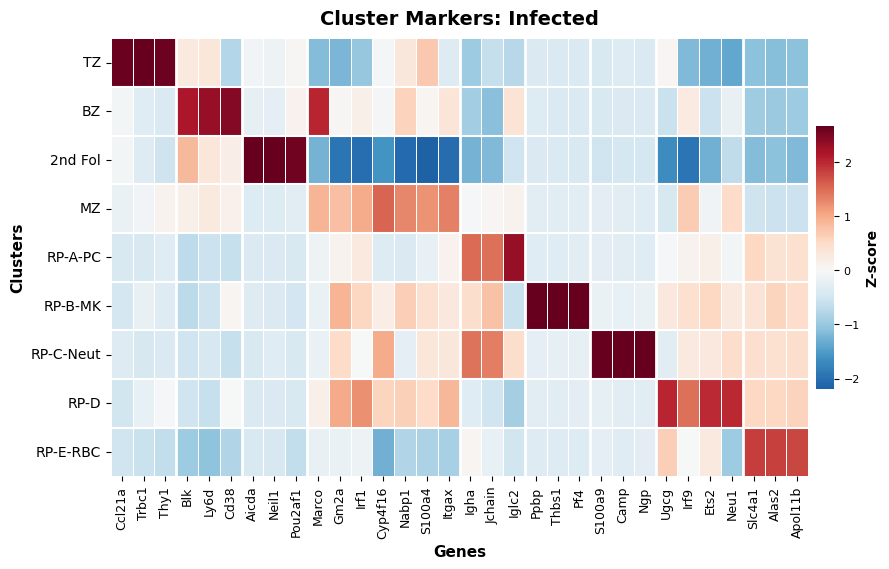

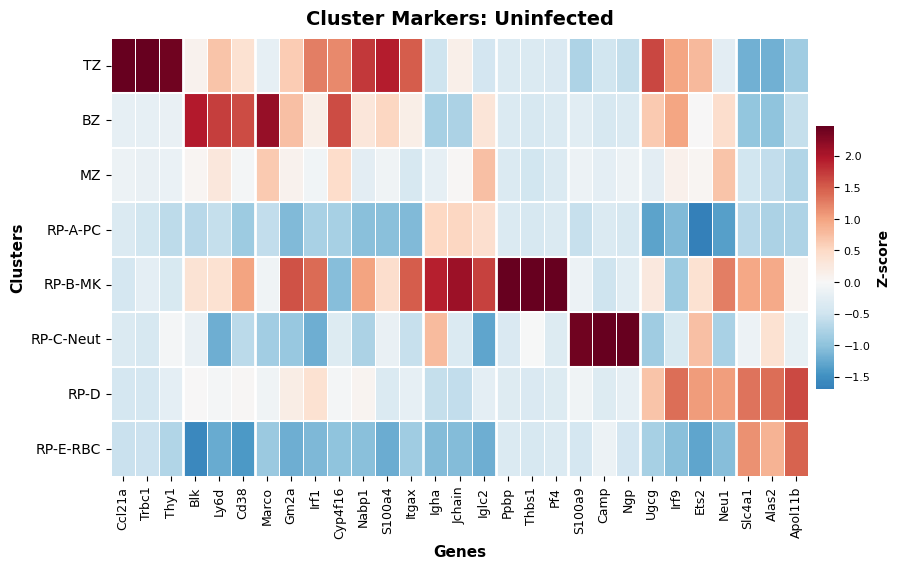

: 

In [ ]:
#!/usr/bin/env python3
"""
Compact Manual Gene List Heatmaps - Separate Conditions
Updated cluster order and gene selection with minimal white space
"""

import numpy as np
import pandas as pd
import scanpy as sc
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from collections import OrderedDict

warnings.filterwarnings('ignore')

def create_final_corrected_heatmaps():
    """
    Create compact separate heatmaps with updated cluster names and genes
    """
    print("="*80)
    print("COMPACT SEPARATE CONDITION HEATMAPS")
    print("="*80)
    
    # Define manual gene lists - NEW ORDER AND GENES
    manual_gene_lists = OrderedDict([
        ('TZ', ['Ccl21a', 'Trbc1', 'Thy1']),
        ('BZ', ['Blk', 'Ly6d', 'Cd38']),
        ('2nd Fol', ['Aicda', 'Neil1', 'Pou2af1']),
        ('MZ', ['Marco', 'Gm2a', 'Irf1', 'Cyp4f16', 'Nabp1', 'S100a4', 'Itgax']),
        ('RP-A-PC', ['Igha', 'Jchain', 'Iglc2']),
        ('RP-B-MK', ['Ppbp', 'Thbs1', 'Pf4']),
        ('RP-C-Neut', ['S100a9', 'Camp', 'Ngp']),
        ('RP-D', ['Ugcg', 'Irf9', 'Ets2', 'Neu1']),
        ('RP-E-RBC', ['Slc4a1', 'Alas2', 'Apol11b'])
    ])
    
    # Mapping from new names to old names in the data
    cluster_name_mapping = {
        'TZ': 'WP-A: TZ',
        'BZ': 'WP-B: BZ',
        '2nd Fol': 'WP-D: GC',
        'MZ': 'WP-C: MZ',
        'RP-A-PC': 'RP-A: GZMK',
        'RP-B-MK': 'RP-B: H_MK',
        'RP-C-Neut': 'RP-C: NGP',
        'RP-D': 'RP-D: F480',
        'RP-E-RBC': 'RP-E: Rhag'
    }
    
    try:
        # Load data
        print("Loading data...")
        adata_infected = sc.read_h5ad('/Users/yashkulkarni/cellxgene_data/cell2location_infected_030525_yk.h5ad')
        adata_uninfected = sc.read_h5ad('/Users/yashkulkarni/cellxgene_data/cell2location_uninfected_030525_yk.h5ad')
        
        # Create heatmaps for each condition
        figures = {}
        
        for condition in ['infected', 'uninfected']:
            print(f"\n{'='*60}")
            print(f"CREATING {condition.upper()} HEATMAP")
            print(f"{'='*60}")
            
            # Get condition-specific data
            if condition == 'infected':
                adata_condition = adata_infected.copy()
            else:
                adata_condition = adata_uninfected.copy()
            
            # Check cluster existence using OLD names from the data
            print("Checking cluster existence:")
            existing_clusters = []
            existing_new_names = []
            
            for new_name, old_name in cluster_name_mapping.items():
                # Check if OLD cluster name exists in this condition's data
                unique_clusters = adata_condition.obs['paper_clusters'].unique()
                cluster_exists = old_name in unique_clusters
                
                if cluster_exists:
                    n_spots = np.sum(adata_condition.obs['paper_clusters'] == old_name)
                    if n_spots > 0:
                        existing_clusters.append(old_name)
                        existing_new_names.append(new_name)
                        print(f"  ✅ {new_name} ({old_name}): {n_spots} spots - INCLUDED")
                    else:
                        print(f"  ❌ {new_name} ({old_name}): 0 spots - EXCLUDED")
                else:
                    print(f"  ❌ {new_name} ({old_name}): NOT FOUND - EXCLUDED")
            
            print(f"\n🎯 FINAL CLUSTERS FOR {condition.upper()}: {len(existing_new_names)}")
            for i, (new_name, old_name) in enumerate(zip(existing_new_names, existing_clusters), 1):
                print(f"  {i}. {new_name} ({old_name})")
            
            if len(existing_clusters) == 0:
                print(f"❌ No valid clusters found for {condition} condition!")
                continue
            
            # Create gene list ONLY for existing clusters
            condition_genes = []
            condition_gene_to_cluster = {}
            
            print(f"\nCreating gene list for {condition} condition:")
            for new_name in existing_new_names:
                cluster_genes = manual_gene_lists[new_name]
                
                for gene in cluster_genes:
                    if gene in adata_condition.var_names:
                        condition_genes.append(gene)
                        condition_gene_to_cluster[gene] = new_name
                    else:
                        print(f"    ⚠️  {gene} not found in dataset")
                        
                print(f"  {new_name}: added {len([g for g in cluster_genes if g in adata_condition.var_names])} genes")
            
            print(f"Total genes for {condition} heatmap: {len(condition_genes)}")
            
            # Create expression matrix (clusters x genes)
            expression_matrix = np.zeros((len(existing_clusters), len(condition_genes)))
            
            # Extract expression data
            if hasattr(adata_condition.X, 'toarray'):
                expr_data = adata_condition.X.toarray()
            else:
                expr_data = adata_condition.X
            
            for gene_idx, gene in enumerate(condition_genes):
                gene_adata_idx = list(adata_condition.var_names).index(gene)
                
                for cluster_idx, old_cluster_name in enumerate(existing_clusters):
                    cluster_mask = adata_condition.obs['paper_clusters'] == old_cluster_name
                    
                    if np.sum(cluster_mask) > 0:
                        expr = expr_data[cluster_mask, gene_adata_idx]
                        mean_expr = np.mean(expr)
                    else:
                        mean_expr = 0
                    
                    expression_matrix[cluster_idx, gene_idx] = mean_expr
            
            # Create DataFrame with NEW cluster names
            heatmap_df = pd.DataFrame(
                expression_matrix,
                index=existing_new_names,
                columns=condition_genes
            )
            
            # Within-condition Z-score normalization
            print(f"Applying within-{condition} Z-score normalization...")
            heatmap_zscore = heatmap_df.apply(lambda x: (x - x.mean()) / x.std(), axis=0)
            heatmap_zscore = heatmap_zscore.fillna(0)
            
            # COMPACT FIGURE SIZING
            n_genes = len(condition_genes)
            n_clusters = len(existing_new_names)
            
            # Compact sizing
            fig_width = max(10, n_genes * 0.2)  
            fig_height = max(6, n_clusters * 0.2)  
            
            fig, ax = plt.subplots(figsize=(fig_width, fig_height))
            
            # Calculate data range
            data_min = heatmap_zscore.min().min()
            data_max = heatmap_zscore.max().max()
            
            print(f"{condition} Z-score range: {data_min:.2f} to {data_max:.2f}")
            
            # Create heatmap
            sns.heatmap(
                heatmap_zscore,
                cmap='RdBu_r',
                center=0,
                vmin=data_min,
                vmax=data_max,
                cbar_kws={
                    'label': f'Z-score\n({condition})', 
                    'shrink': 0.6,
                    'pad': 0.01,
                    'aspect': 15,
                },
                xticklabels=True,
                yticklabels=True,
                ax=ax,
                linewidths=0.5,
                linecolor='white'
            )
            
            # COMPACT FONT SIZES
            # X-axis labels (genes)
            ax.set_xticklabels(condition_genes, rotation=90, ha='center', fontsize=9)
            
            # Y-axis labels (clusters) - use NEW names
            ax.set_yticklabels(existing_new_names, fontsize=10, rotation=0, ha='right', va='center')
            
            # MINIMAL margins
            plt.subplots_adjust(left=0.15, bottom=0.15, top=0.88, right=0.98)
            
            # Add cluster boundaries and brackets
            gene_count = 0
            cluster_boundaries = []
            cluster_labels = []
            
            # Use ONLY existing clusters for this condition
            for new_cluster_name in existing_new_names:
                cluster_genes_in_condition = [g for g in condition_genes if condition_gene_to_cluster.get(g) == new_cluster_name]
                if len(cluster_genes_in_condition) > 0:
                    gene_start = gene_count
                    gene_count += len(cluster_genes_in_condition)
                    gene_end = gene_count
                    
                    cluster_boundaries.append((gene_start, gene_end))
                    cluster_labels.append(new_cluster_name)
                    
                    # Add vertical separator
                    if gene_end < len(condition_genes):
                        ax.axvline(x=gene_end, color='white', linewidth=2)
            
            # Add horizontal lines between clusters
            for i in range(1, len(existing_new_names)):
                ax.axhline(y=i, color='white', linewidth=1.5)
            
            # Title and labels - COMPACT
            ax.set_title(f'Cluster Markers: {condition.title()}',
                        fontsize=14, weight='bold', pad=10)
            ax.set_ylabel('Clusters', fontsize=11, weight='bold')
            ax.set_xlabel('Genes', fontsize=11, weight='bold')
            
            # Colorbar - COMPACT
            cbar = ax.collections[0].colorbar
            cbar.set_label(f'Z-score', 
                          fontsize=10, weight='bold')
            cbar.ax.tick_params(labelsize=8)
            
            # Save plots with minimal padding
            output_prefix = f"COMPACT_{condition}_heatmap"
            plt.savefig(f"{output_prefix}.png", dpi=300, bbox_inches='tight', facecolor='white', pad_inches=0.1)
            plt.savefig(f"{output_prefix}.pdf", bbox_inches='tight', facecolor='white', pad_inches=0.1)
            
            print(f"✅ {condition.title()} heatmap saved as {output_prefix}.png and .pdf")
            
            # Save data
            heatmap_df.to_csv(f"COMPACT_{condition}_expression_matrix.csv")
            
            figures[condition] = fig
        
        plt.show()
        return figures
        
    except Exception as e:
        print(f"❌ Error: {e}")
        import traceback
        traceback.print_exc()

# Run the analysis
figures = create_final_corrected_heatmaps()


COMBINED INFECTED/UNINFECTED HEATMAP
Loading data...

Total genes: 28

Processing cluster: TZ
  Infected: 74 spots, Uninfected: 50 spots

Processing cluster: BZ
  Infected: 219 spots, Uninfected: 168 spots

Processing cluster: 2nd Fol
  Infected: 33 spots, Uninfected: 0 spots

Processing cluster: MZ
  Infected: 242 spots, Uninfected: 283 spots

Processing cluster: RP-A-PC
  Infected: 194 spots, Uninfected: 325 spots

Processing cluster: RP-B-MK
  Infected: 75 spots, Uninfected: 33 spots

Processing cluster: RP-C-Neut
  Infected: 90 spots, Uninfected: 38 spots

Processing cluster: RP-D
  Infected: 119 spots, Uninfected: 119 spots

Processing cluster: RP-E-RBC
  Infected: 222 spots, Uninfected: 261 spots

Final heatmap shape: (17, 28)
Rows (alternating infected/uninfected): 17
Columns (genes): 28

Applying Z-score normalization across both conditions...
Z-score range: -1.33 to 3.85

✅ Combined heatmap saved as COMBINED_infected_uninfected_heatmap.png and .pdf


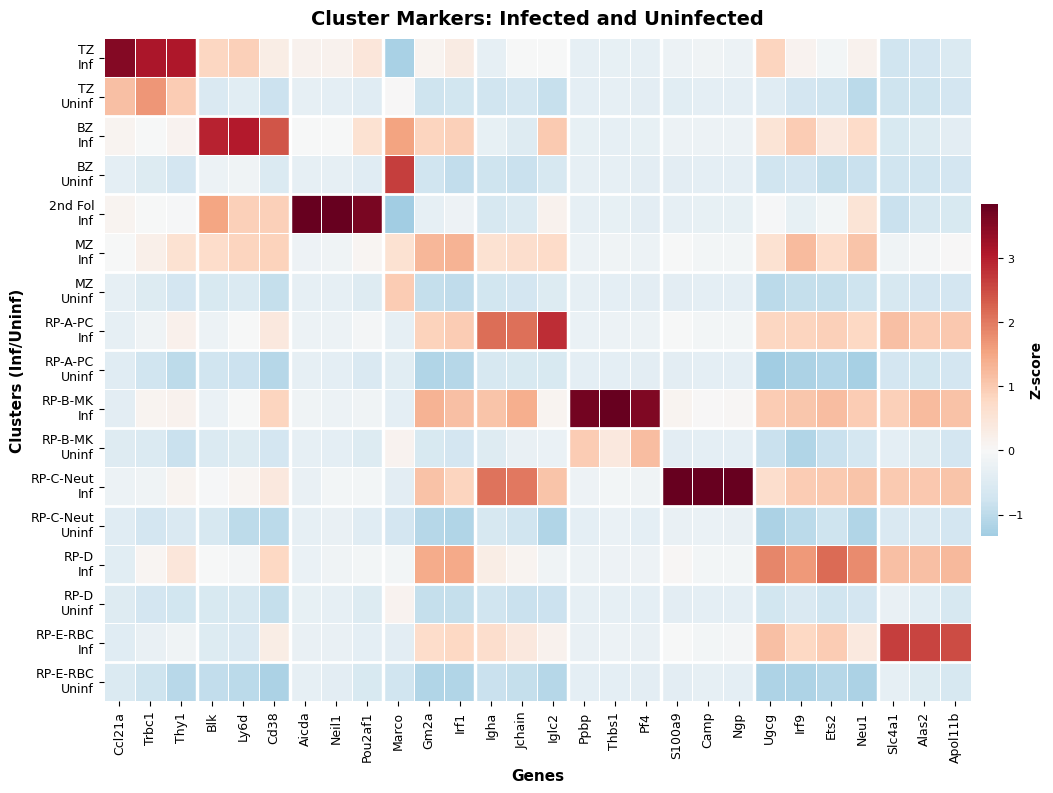

In [19]:
#!/usr/bin/env python3
"""
Combined Infected/Uninfected Heatmap - Alternating Rows
Shows infected and uninfected for each cluster with gap for missing 2o Fol
"""

import numpy as np
import pandas as pd
import scanpy as sc
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from collections import OrderedDict

warnings.filterwarnings('ignore')

def create_combined_heatmap():
    """
    Create combined heatmap with alternating infected/uninfected rows
    """
    print("="*80)
    print("COMBINED INFECTED/UNINFECTED HEATMAP")
    print("="*80)
    
    # Define manual gene lists - NEW ORDER AND GENES
    manual_gene_lists = OrderedDict([
        ('TZ', ['Ccl21a', 'Trbc1', 'Thy1']),
        ('BZ', ['Blk', 'Ly6d', 'Cd38']),
        ('2nd Fol', ['Aicda', 'Neil1', 'Pou2af1']),
        ('MZ', ['Marco', 'Gm2a', 'Irf1']),
        ('RP-A-PC', ['Igha', 'Jchain', 'Iglc2']),
        ('RP-B-MK', ['Ppbp', 'Thbs1', 'Pf4']),
        ('RP-C-Neut', ['S100a9', 'Camp', 'Ngp']),
        ('RP-D', ['Ugcg', 'Irf9', 'Ets2', 'Neu1']),
        ('RP-E-RBC', ['Slc4a1', 'Alas2', 'Apol11b'])
    ])
    
    # Mapping from new names to old names in the data
    cluster_name_mapping = {
        'TZ': 'WP-A: TZ',
        'BZ': 'WP-B: BZ',
        '2nd Fol': 'WP-D: GC',
        'MZ': 'WP-C: MZ',
        'RP-A-PC': 'RP-A: GZMK',
        'RP-B-MK': 'RP-B: H_MK',
        'RP-C-Neut': 'RP-C: NGP',
        'RP-D': 'RP-D: F480',
        'RP-E-RBC': 'RP-E: Rhag'
    }
    
    try:
        # Load data
        print("Loading data...")
        adata_infected = sc.read_h5ad('/Users/yashkulkarni/cellxgene_data/cell2location_infected_030525_yk.h5ad')
        adata_uninfected = sc.read_h5ad('/Users/yashkulkarni/cellxgene_data/cell2location_uninfected_030525_yk.h5ad')
        
        # Collect all genes across all clusters
        all_genes = []
        gene_to_cluster = {}
        
        for new_name in manual_gene_lists.keys():
            cluster_genes = manual_gene_lists[new_name]
            for gene in cluster_genes:
                # Check if gene exists in either dataset
                if gene in adata_infected.var_names or gene in adata_uninfected.var_names:
                    all_genes.append(gene)
                    gene_to_cluster[gene] = new_name
                else:
                    print(f"⚠️  {gene} not found in either dataset")
        
        print(f"\nTotal genes: {len(all_genes)}")
        
        # Build combined row structure (alternating infected/uninfected)
        row_labels = []
        row_data_list = []
        
        for new_name, old_name in cluster_name_mapping.items():
            print(f"\nProcessing cluster: {new_name}")
            
            # Check infected
            infected_exists = old_name in adata_infected.obs['paper_clusters'].unique()
            infected_n = np.sum(adata_infected.obs['paper_clusters'] == old_name) if infected_exists else 0
            
            # Check uninfected
            uninfected_exists = old_name in adata_uninfected.obs['paper_clusters'].unique()
            uninfected_n = np.sum(adata_uninfected.obs['paper_clusters'] == old_name) if uninfected_exists else 0
            
            print(f"  Infected: {infected_n} spots, Uninfected: {uninfected_n} spots")
            
            # Add infected row
            if infected_exists and infected_n > 0:
                row_data = np.zeros(len(all_genes))
                
                # Extract expression data
                if hasattr(adata_infected.X, 'toarray'):
                    expr_data = adata_infected.X.toarray()
                else:
                    expr_data = adata_infected.X
                
                for gene_idx, gene in enumerate(all_genes):
                    if gene in adata_infected.var_names:
                        gene_adata_idx = list(adata_infected.var_names).index(gene)
                        cluster_mask = adata_infected.obs['paper_clusters'] == old_name
                        expr = expr_data[cluster_mask, gene_adata_idx]
                        row_data[gene_idx] = np.mean(expr)
                    else:
                        row_data[gene_idx] = np.nan
                
                row_data_list.append(row_data)
                row_labels.append(f"{new_name}\nInf")
            
            # Add uninfected row
            if uninfected_exists and uninfected_n > 0:
                row_data = np.zeros(len(all_genes))
                
                # Extract expression data
                if hasattr(adata_uninfected.X, 'toarray'):
                    expr_data = adata_uninfected.X.toarray()
                else:
                    expr_data = adata_uninfected.X
                
                for gene_idx, gene in enumerate(all_genes):
                    if gene in adata_uninfected.var_names:
                        gene_adata_idx = list(adata_uninfected.var_names).index(gene)
                        cluster_mask = adata_uninfected.obs['paper_clusters'] == old_name
                        expr = expr_data[cluster_mask, gene_adata_idx]
                        row_data[gene_idx] = np.mean(expr)
                    else:
                        row_data[gene_idx] = np.nan
                
                row_data_list.append(row_data)
                row_labels.append(f"{new_name}\nUninf")
            elif new_name == '2o Fol':
                # Add empty/gap row for missing uninfected 2o Fol
                row_data = np.full(len(all_genes), np.nan)
                row_data_list.append(row_data)
                row_labels.append(f"{new_name}\nUninf")
                print(f"  Added gap row for missing uninfected 2o Fol")
        
        # Create DataFrame
        expression_matrix = np.array(row_data_list)
        heatmap_df = pd.DataFrame(
            expression_matrix,
            index=row_labels,
            columns=all_genes
        )
        
        print(f"\nFinal heatmap shape: {heatmap_df.shape}")
        print(f"Rows (alternating infected/uninfected): {len(row_labels)}")
        print(f"Columns (genes): {len(all_genes)}")
        
        # Z-score normalization ACROSS ALL CONDITIONS
        print("\nApplying Z-score normalization across both conditions...")
        heatmap_zscore = heatmap_df.apply(lambda x: (x - x.mean()) / x.std(), axis=0)
        heatmap_zscore = heatmap_zscore.fillna(0)
        
        # COMPACT FIGURE SIZING
        n_genes = len(all_genes)
        n_rows = len(row_labels)
        
        fig_width = max(12, n_genes * 0.35)  
        fig_height = max(8, n_rows * 0.5)  # Smaller per row since we have more rows
        
        fig, ax = plt.subplots(figsize=(fig_width, fig_height))
        
        # Calculate data range
        data_min = heatmap_zscore.min().min()
        data_max = heatmap_zscore.max().max()
        
        print(f"Z-score range: {data_min:.2f} to {data_max:.2f}")
        
        # Create heatmap
        sns.heatmap(
            heatmap_zscore,
            cmap='RdBu_r',
            center=0,
            vmin=data_min,
            vmax=data_max,
            cbar_kws={
                'label': 'Z-score\n(combined)', 
                'shrink': 0.5,
                'pad': 0.01,
                'aspect': 20,
            },
            xticklabels=True,
            yticklabels=True,
            ax=ax,
            linewidths=0.5,
            linecolor='white'
        )
        
        # COMPACT FONT SIZES
        ax.set_xticklabels(all_genes, rotation=90, ha='center', fontsize=9)
        ax.set_yticklabels(row_labels, fontsize=9, rotation=0, ha='right', va='center')
        
        # MINIMAL margins
        plt.subplots_adjust(left=0.12, bottom=0.12, top=0.90, right=0.98)
        
        # Add cluster boundaries (vertical lines between gene groups)
        gene_count = 0
        cluster_boundaries = []
        cluster_labels_top = []
        
        for cluster_name in manual_gene_lists.keys():
            cluster_genes_in_data = [g for g in all_genes if gene_to_cluster.get(g) == cluster_name]
            if len(cluster_genes_in_data) > 0:
                gene_start = gene_count
                gene_count += len(cluster_genes_in_data)
                gene_end = gene_count
                
                cluster_boundaries.append((gene_start, gene_end))
                cluster_labels_top.append(cluster_name)
                
                # Add vertical separator
                if gene_end < len(all_genes):
                    ax.axvline(x=gene_end, color='white', linewidth=2.5)
        
        # Add horizontal lines to separate cluster pairs (every 2 rows)
        for i in range(2, len(row_labels), 2):
            # Check if this is the gap row for 2o Fol
            if 'Uninf' in row_labels[i-1] and '2o Fol' in row_labels[i-1]:
                # Stronger line after the gap
                ax.axhline(y=i, color='white', linewidth=3)
            else:
                ax.axhline(y=i, color='white', linewidth=2)
        
        # Lighter lines between infected/uninfected pairs
        for i in range(1, len(row_labels), 2):
            ax.axhline(y=i, color='white', linewidth=0.8, alpha=0.5)
        
        
        # Title and labels
        ax.set_title('Cluster Markers: Infected and Uninfected',
                    fontsize=14, weight='bold', pad=10)
        ax.set_ylabel('Clusters (Inf/Uninf)', fontsize=11, weight='bold')
        ax.set_xlabel('Genes', fontsize=11, weight='bold')
        
        # Colorbar
        cbar = ax.collections[0].colorbar
        cbar.set_label('Z-score', 
                      fontsize=10, weight='bold')
        cbar.ax.tick_params(labelsize=8)
        
        # Save plots
        output_prefix = "COMBINED_infected_uninfected_heatmap"
        plt.savefig(f"{output_prefix}.png", dpi=300, bbox_inches='tight', facecolor='white', pad_inches=0.1)
        plt.savefig(f"{output_prefix}.pdf", bbox_inches='tight', facecolor='white', pad_inches=0.1)
        
        print(f"\n✅ Combined heatmap saved as {output_prefix}.png and .pdf")
        
        # Save data
        heatmap_df.to_csv("COMBINED_expression_matrix.csv")
        heatmap_zscore.to_csv("COMBINED_zscore_matrix.csv")
        
        plt.show()
        return fig
        
    except Exception as e:
        print(f"❌ Error: {e}")
        import traceback
        traceback.print_exc()

# Run the analysis
figure = create_combined_heatmap()